# Tarefa 5 — Otimização de hiperparâmetros

**Avanços em IA — EELT7025, PPGEE/UFPR**

**Integrantes:** Adriely Teixeira de Paula; Betina Zynger Capaverde; Emilio Gaudeda Junior.

**Dataset:** Concrete Compressive Strength (UCI 165). **Modelo:** GradientBoostingRegressor. **Alvo:** resistência à compressão, em MPa.

Este notebook contém resultados reais dos experimentos, suas análises e o código completo empregado. As células de reconstrução foram executadas a partir dos registros salvos. O HPO foi executado pelo engine em processos separados; não é executado uma segunda vez para gerar esta entrega. A execução e as limitações são auditáveis nos CSVs, JSONs e logs anexos.

O protocolo e o orçamento foram fixados antes de observar os resultados, seguindo o framework [rnd-superpowers, commit f68892c8](https://github.com/juniortlr/rnd-superpowers/commit/f68892c8b7adba358b8aa437eec00a89fe88d340). Não foram encontrados comentários do professor nos trabalhos anteriores; as correções de metodologia adotadas decorrem da nossa revisão técnica, sem atribuí-las a feedback docente.

## Como reproduzir

Para visualizar, basta abrir este notebook: as tabelas e imagens estão incorporadas nas saídas. Para executar a análise sem refazer o HPO, extraia o pacote completo na mesma pasta e instale as dependências de `requirements-lock.txt` (Python compatível com o ambiente registrado). Execute as células em ordem.

Para repetir **todos os experimentos**, altere `RUN_EXPERIMENTS=True` abaixo. Os fontes completos estão incorporados nas células `%%writefile`; se o pacote não estiver presente, podem reconstruir os scripts em uma pasta vazia. A obtenção inicial de dados exige internet. Os budgets incluem milhares de fits; a reconstrução de gráficos é muito mais rápida. Tempos dependem do hardware e da carga do sistema. As execuções anteriores são preservadas pelo engine.

In [1]:
from pathlib import Path
import os, sys, json, subprocess
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

# Caminhos relativos: nenhuma referência à máquina do autor.
ROOT = Path.cwd()
if (ROOT / 'tarefa5' / 'experiment.py').exists():
    ROOT = ROOT / 'tarefa5'
os.chdir(ROOT)
RUN_EXPERIMENTS = False
CV_JOBS = 5
print('Pasta dos artefatos:', ROOT)
print('Python:', sys.version.split()[0])

Pasta dos artefatos: C:\Users\EG\Documents\ChatGPT\avançosia\tarefa5
Python: 3.12.1


### Código executável incorporado

As duas células seguintes escrevem exatamente os fontes usados nesta versão. O experimento mantém o teste fora da seleção de hiperparâmetros; os gráficos só leem resultados existentes. A saída de escrita não constitui execução do HPO. Consulte as funções dos métodos para verificar cada configuração.

In [2]:
%%writefile experiment.py
"""Aula 05: reproducible bounded hyperparameter-optimization experiments.

Run from a fresh process; no source notebook cell or upstream script is executed.
The split and five CV folds are fixed independently of optimizer/model seed.
"""
from __future__ import annotations

import argparse
import csv
import hashlib
import importlib.metadata
import json
import math
import os
import platform
import random
import shutil
import sys
import time
import traceback
import warnings
from concurrent.futures import ThreadPoolExecutor
from datetime import datetime, timezone
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
import joblib
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import differential_evolution
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits

ROOT = Path(__file__).resolve().parent
DATA = ROOT / "data"
RESULTS = ROOT / "results"
FRAMEWORK_COMMIT = "f68892c8b7adba358b8aa437eec00a89fe88d340"
GRID = {"learning_rate": [0.03, 0.1, 0.2], "subsample": [0.6, 0.8, 1.0],
        "n_estimators": [50, 100, 150, 200]}
METHODS = ["baseline", "grid", "random", "gp_manual", "bayessearch", "bayesopt",
           "optuna", "hyperopt", "ray", "ga", "de_best1bin", "de_rand1bin",
           "pso_w07", "pso_w04", "pso_w09"]
MAIN_METHODS = [m for m in METHODS if m not in {"de_rand1bin", "pso_w04", "pso_w09"}]
_WORKER_WARMUP_SECONDS = None
TRIAL_FIELDS = ["method", "seed", "trial", "cv_rmse", "learning_rate", "subsample",
                "n_estimators", "seconds", "elapsed_seconds", "status", "resource",
                "fold_0", "fold_1", "fold_2", "fold_3", "fold_4", "duration_kind"]


def native(value):
    if isinstance(value, dict):
        return {str(k): native(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [native(v) for v in value]
    if isinstance(value, np.ndarray):
        return native(value.tolist())
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, Path):
        return str(value)
    return value


def write_json(path, value):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(json.dumps(native(value), ensure_ascii=False, indent=2,
                                    allow_nan=False), encoding="utf-8")
    temporary.replace(path)


def digest(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


def event(path, kind, **details):
    record = {"utc": datetime.now(timezone.utc).isoformat(), "event": kind, **details}
    with Path(path).open("a", encoding="utf-8") as f:
        f.write(json.dumps(native(record), ensure_ascii=False, allow_nan=False) + "\n")


def parameters(p):
    """One shared decoding rule for objectives and final fitting."""
    return {"learning_rate": float(np.clip(p["learning_rate"], .03, .2)),
            "subsample": float(np.clip(p["subsample"], .6, 1.0)),
            "n_estimators": int(np.clip(np.rint(p["n_estimators"]), 50, 200))}


def decode_unit(u):
    u = np.clip(np.asarray(u, dtype=float), 0, 1)
    return parameters({"learning_rate": .03 * (.2 / .03) ** u[0],
                       "subsample": .6 + .4 * u[1],
                       "n_estimators": 50 + 150 * u[2]})


def pipeline(p=None, seed=42, warm_start=False):
    kw = dict(p or {})
    return Pipeline([("imputer", SimpleImputer(strategy="median")),
                     ("scaler", StandardScaler()),
                     ("model", GradientBoostingRegressor(random_state=seed,
                                                          warm_start=warm_start, **kw))])


def environment():
    packages = ["numpy", "pandas", "scipy", "scikit-learn", "joblib", "threadpoolctl",
                "ucimlrepo", "scikit-optimize", "bayesian-optimization", "optuna",
                "hyperopt", "ray", "deap", "matplotlib", "seaborn"]
    versions = {}
    for p in packages:
        try:
            versions[p] = importlib.metadata.version(p)
        except importlib.metadata.PackageNotFoundError:
            versions[p] = "not-installed"
    return {"python": sys.version, "platform": platform.platform(),
            "processor": platform.processor(), "logical_cpus": os.cpu_count(),
            "packages": versions, "thread_limits": 1}


def prepare():
    """Fetch UCI 165 once, preserve bytes, deduplicate complete exact rows, freeze split."""
    DATA.mkdir(parents=True, exist_ok=True)
    source = DATA / "uci165_raw.csv"
    if not source.exists():
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=165)
        X = dataset.data.features.copy()
        y = dataset.data.targets.iloc[:, 0].rename("target_mpa")
        pd.concat([X, y], axis=1).to_csv(source, index=False)
        write_json(DATA / "uci_metadata.json", dict(dataset.metadata))
    raw = pd.read_csv(source)
    if "target_mpa" not in raw:
        raw = raw.rename(columns={raw.columns[-1]: "target_mpa"})
    assert raw.shape[1] == 9, "Expected eight UCI 165 predictors plus target"
    assert not raw["target_mpa"].isna().any(), "Missing targets need an explicit amendment"
    assert all(pd.api.types.is_numeric_dtype(raw[c]) for c in raw), "Unexpected nonnumeric fields"
    duplicated = raw.duplicated(keep="first")
    clean = raw.loc[~duplicated].copy()
    source_ids = clean.index.to_numpy(dtype=int)
    clean.insert(0, "source_row", source_ids)
    clean.to_csv(DATA / "clean.csv", index=False)
    train_ids, test_ids = train_test_split(np.arange(len(clean)), test_size=.2, random_state=42)
    feature_names = [c for c in raw.columns if c != "target_mpa"]
    X = clean[feature_names].to_numpy(dtype=float)
    y = clean["target_mpa"].to_numpy(dtype=float)
    folds = list(KFold(5, shuffle=True, random_state=42).split(train_ids))
    payload = dict(X=X, y=y, train_ids=train_ids, test_ids=test_ids, source_ids=source_ids,
                   feature_names=np.asarray(feature_names, dtype=str))
    for k, (tr, va) in enumerate(folds):
        payload[f"fold_{k}_train"] = tr
        payload[f"fold_{k}_valid"] = va
    np.savez_compressed(DATA / "prepared.npz", **payload)
    split = pd.DataFrame({"clean_index": np.arange(len(clean)), "source_row": source_ids,
                          "split": "test", "validation_fold": -1})
    split.loc[train_ids, "split"] = "train"
    for k, (_, va) in enumerate(folds):
        split.loc[train_ids[va], "validation_fold"] = k
    split.to_csv(DATA / "split-manifest.csv", index=False)
    pd.DataFrame({"column": raw.columns, "dtype": raw.dtypes.astype(str).values,
                  "missing_count": raw.isna().sum().values,
                  "missing_fraction": raw.isna().mean().values}).to_csv(DATA / "quality-summary.csv", index=False)
    # The assignment explicitly requests whole-data describe; disclose this prior aggregate exposure.
    raw.describe().to_csv(DATA / "describe_raw.csv")
    clean.iloc[train_ids].drop(columns="source_row").describe().to_csv(DATA / "describe_train.csv")
    write_json(DATA / "data-contract.json", {
        "dataset": "UCI 165 Concrete Compressive Strength", "url": "https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength",
        "target_unit": "MPa", "raw_shape": raw.shape, "clean_shape": [len(clean), 9],
        "exact_duplicate_rows_removed": int(duplicated.sum()), "train_rows": len(train_ids),
        "test_rows": len(test_ids), "split_seed": 42, "fold_seed": 42, "folds": 5,
        "features": feature_names, "missing_policy": "Median imputation inside every training fold; target not scaled",
        "duplicates_policy": "Only complete exactly identical feature+target rows removed before split",
        "prior_outcome_exposure": "Whole-data shape/dtypes/missingness/describe required by assignment; substantive EDA restricted to development set",
        "generalization_limit": "Random row split; no batch IDs available to verify independence of related mixes",
        "sha256": {p.name: digest(p) for p in [source, DATA / "clean.csv", DATA / "split-manifest.csv", DATA / "prepared.npz"]},
        "framework_commit": FRAMEWORK_COMMIT})
    write_json(DATA / "environment.json", environment())
    print(json.dumps({"prepared": True, "raw": len(raw), "clean": len(clean),
                      "train": len(train_ids), "test": len(test_ids)}), flush=True)


def _touch_worker(i):
    import sklearn
    a = np.full((256, 256), float(i + 1))
    return os.getpid(), float(np.dot(a, a)[0, 0])


def warm_workers(jobs):
    """Exclude and disclose process-pool initialization, once per CLI process."""
    global _WORKER_WARMUP_SECONDS
    if _WORKER_WARMUP_SECONDS is None:
        start = time.perf_counter()
        with joblib.parallel_config(backend="loky", n_jobs=jobs, inner_max_num_threads=1):
            joblib.Parallel(n_jobs=jobs)(joblib.delayed(_touch_worker)(i) for i in range(jobs * 2))
        _WORKER_WARMUP_SECONDS = time.perf_counter() - start


class Objective:
    def __init__(self, method, seed, jobs, out, sample_fraction=1.0):
        self.method, self.seed, self.jobs, self.out = method, seed, jobs, Path(out)
        z = np.load(DATA / "prepared.npz", allow_pickle=False)
        self.feature_names = z["feature_names"].tolist()
        self.train_ids, self.test_ids = z["train_ids"], z["test_ids"]
        self.X, self.y = z["X"][self.train_ids], z["y"][self.train_ids]
        self.Xtest, self.ytest = z["X"][self.test_ids], z["y"][self.test_ids]
        self.source_test_ids = z["source_ids"][self.test_ids]
        self.folds = [(z[f"fold_{k}_train"], z[f"fold_{k}_valid"]) for k in range(5)]
        self.sample_fraction = sample_fraction
        if sample_fraction < 1:
            chosen = np.sort(np.random.default_rng(42).choice(len(self.X),
                            size=int(len(self.X) * sample_fraction), replace=False))
            self.X, self.y = self.X[chosen], self.y[chosen]
            self.folds = list(KFold(5, shuffle=True, random_state=42).split(self.X))
            pd.DataFrame({"development_position": chosen}).to_csv(self.out / "sample-indices.csv", index=False)
        self.rows = []
        self.started = time.perf_counter()
        self.cv_fits = 0
        self.trained_trees = 0

    def record(self, p, score, scores, seconds, status="complete", resource=1., duration_kind="objective_wall"):
        p = p or {"learning_rate": .1, "subsample": 1., "n_estimators": 100}
        row = {"method": self.method, "seed": self.seed, "trial": len(self.rows) + 1,
               "cv_rmse": float(score), **p, "seconds": float(seconds),
               "elapsed_seconds": time.perf_counter() - self.started, "status": status,
               "resource": float(resource), "duration_kind": duration_kind}
        row.update({f"fold_{k}": float(s) for k, s in enumerate(scores)})
        self.rows.append(row)
        path = self.out / "trials.csv"
        with path.open("a", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=TRIAL_FIELDS)
            if len(self.rows) == 1:
                writer.writeheader()
            writer.writerow(row)
        event(self.out / "events.jsonl", "candidate", **row)
        if len(self.rows) == 1 or len(self.rows) % 10 == 0:
            print(f"{self.method} seed={self.seed} n={len(self.rows)} rmse={score:.6f}", flush=True)
        return float(score)

    def __call__(self, p):
        p = parameters(p) if p else {}
        t0 = time.perf_counter()
        try:
            with threadpool_limits(1), joblib.parallel_config(backend="loky", n_jobs=self.jobs, inner_max_num_threads=1):
                scores = -cross_val_score(pipeline(p, self.seed), self.X, self.y, cv=self.folds,
                    scoring="neg_root_mean_squared_error", n_jobs=self.jobs, error_score="raise")
        except Exception as exc:
            event(self.out / "events.jsonl", "candidate_failed", params=p, error=repr(exc))
            raise
        self.cv_fits += 5
        self.trained_trees += 5 * p.get("n_estimators", 100)
        return self.record(p, np.mean(scores), scores, time.perf_counter() - t0)

    def best(self):
        eligible = [r for r in self.rows if r["status"] == "complete" and r["resource"] >= 1]
        if not eligible:
            raise RuntimeError("No full-resource candidate available for selection")
        row = min(eligible, key=lambda r: r["cv_rmse"])
        return parameters(row), row["cv_rmse"]


def searchcv(obj, method):
    common = dict(estimator=pipeline(seed=obj.seed), scoring="neg_root_mean_squared_error",
                  cv=obj.folds, n_jobs=obj.jobs, refit=False, return_train_score=False,
                  error_score="raise")
    space = {"model__" + k: v for k, v in GRID.items()}
    if method == "grid":
        search = GridSearchCV(param_grid=space, **common)
    elif method == "random":
        search = RandomizedSearchCV(param_distributions=space, n_iter=30, random_state=obj.seed, **common)
    else:
        from skopt import BayesSearchCV
        from skopt.space import Integer, Real
        from skopt.learning import GaussianProcessRegressor as SkoptGP
        from skopt.learning.gaussian_process.kernels import ConstantKernel as CK, Matern as MK
        kernel = CK(1., (.01, 100)) * MK([1., 1., 1.], (.01, 100), nu=2.5)
        surrogate = SkoptGP(kernel=kernel, normalize_y=True, noise="gaussian",
                            n_restarts_optimizer=2, random_state=obj.seed)
        continuous = {"model__learning_rate": Real(.03, .2, prior="log-uniform"),
                      "model__subsample": Real(.6, 1.), "model__n_estimators": Integer(50, 200)}
        search = BayesSearchCV(search_spaces=continuous, n_iter=40, random_state=obj.seed,
                    optimizer_kwargs={"base_estimator": surrogate, "acq_func": "EI",
                                      "acq_optimizer": "sampling", "n_initial_points": 10,
                                      "acq_optimizer_kwargs": {"n_points": 4096}}, **common)
    with threadpool_limits(1), joblib.parallel_config(backend="loky", n_jobs=obj.jobs, inner_max_num_threads=1):
        search.fit(obj.X, obj.y)
    cv = search.cv_results_
    pd.DataFrame(cv).to_csv(obj.out / "searchcv-results.csv", index=False)
    for i, candidate in enumerate(cv["params"]):
        p = {k.removeprefix("model__"): v for k, v in candidate.items()}
        folds = [-cv[f"split{k}_test_score"][i] for k in range(5)]
        obj.record(parameters(p), -cv["mean_test_score"][i], folds,
                   cv["mean_fit_time"][i] + cv["mean_score_time"][i],
                   duration_kind="mean_fold_fit_plus_score; scheduled_candidate_order")
    obj.cv_fits = 5 * len(obj.rows)
    obj.trained_trees = 5 * sum(int(r["n_estimators"]) for r in obj.rows)
    if method == "bayessearch":
        joblib.dump(search.optimizer_results_, obj.out / "optimizer-results.joblib")


def gp_manual(obj):
    rng = np.random.default_rng(obj.seed)
    observed_u, observed_y = [], []
    axis = np.linspace(0, 1, 61)
    aa, bb = np.meshgrid(axis, axis, indexing="xy")
    grid_u = np.column_stack([aa.ravel(), bb.ravel()])
    def evaluate(u):
        p = decode_unit([u[0], u[1], 1 / 3])  # Fixed prospectively: n_estimators=100.
        observed_u.append(np.array(u))
        observed_y.append(obj(p))
    for u in rng.random((5, 2)):
        evaluate(u)
    for iteration in range(1, 11):
        gp = GaussianProcessRegressor(kernel=ConstantKernel(1, (.01, 100)) *
                Matern([.3, .3], (.01, 100), nu=2.5) + WhiteKernel(1e-6, (1e-10, .1)),
                normalize_y=True, n_restarts_optimizer=2, random_state=obj.seed)
        with threadpool_limits(1):
            gp.fit(observed_u, observed_y)
            mu, sigma = gp.predict(grid_u, return_std=True)
        improvement = np.min(observed_y) - mu - .01
        z = improvement / np.maximum(sigma, 1e-12)
        ei = improvement * stats.norm.cdf(z) + sigma * stats.norm.pdf(z)
        ei[sigma <= 1e-12] = 0.
        distance = np.min(np.linalg.norm(grid_u[:, None, :] - np.asarray(observed_u)[None, :, :], axis=2), axis=1)
        ei[distance < 1e-8] = -1.
        next_u = grid_u[int(np.argmax(ei))]
        slice_u = np.column_stack([np.linspace(0, 1, 201), np.full(201, next_u[1])])
        slice_mu, slice_sigma = gp.predict(slice_u, return_std=True)
        slice_improvement = np.min(observed_y) - slice_mu - .01
        slice_z = slice_improvement / np.maximum(slice_sigma, 1e-12)
        slice_ei = slice_improvement * stats.norm.cdf(slice_z) + slice_sigma * stats.norm.pdf(slice_z)
        slice_ei[slice_sigma <= 1e-12] = 0.
        np.savez_compressed(obj.out / f"gp_snapshot_{iteration:02d}.npz", grid_u=grid_u,
            mu=mu, sigma=sigma, ei=ei, observed_u=np.asarray(observed_u),
            observed_y=np.asarray(observed_y), next_u=next_u, fixed_n_estimators=100,
            slice_u=slice_u, slice_mu=slice_mu, slice_sigma=slice_sigma,
            slice_ei=slice_ei, next_ei=float(np.max(ei)), xi=.01)
        evaluate(next_u)


def bayesopt(obj):
    from bayes_opt import BayesianOptimization, acquisition
    def target(log_lr, subsample, n_estimators):
        return -obj({"learning_rate": np.exp(log_lr), "subsample": subsample,
                     "n_estimators": n_estimators})
    bo = BayesianOptimization(f=target, pbounds={"log_lr": (np.log(.03), np.log(.2)),
         "subsample": (.6, 1.), "n_estimators": (50., 200.)}, random_state=obj.seed,
         acquisition_function=acquisition.UpperConfidenceBound(kappa=2.576),
         verbose=0, allow_duplicate_points=True)
    bo.set_gp_params(kernel=Matern(nu=2.5), normalize_y=True)
    bo.maximize(init_points=5, n_iter=35)
    write_json(obj.out / "bayesopt-history.json", bo.res)


def optuna_search(obj):
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=obj.seed))
    def target(trial):
        return obj({"learning_rate": trial.suggest_float("learning_rate", .03, .2, log=True),
                    "subsample": trial.suggest_float("subsample", .6, 1.),
                    "n_estimators": trial.suggest_int("n_estimators", 50, 200)})
    study.optimize(target, n_trials=40, n_jobs=1)
    study.trials_dataframe().to_csv(obj.out / "optuna-trials.csv", index=False)
    joblib.dump(study, obj.out / "optuna-study.joblib")
    importance = optuna.importance.get_param_importances(study,
        evaluator=optuna.importance.FanovaImportanceEvaluator(seed=obj.seed))
    pd.DataFrame([{"hyperparameter": k, "importance": v} for k, v in importance.items()]).to_csv(
        obj.out / "optuna_importances.csv", index=False)


def hyperopt_search(obj):
    from hyperopt import STATUS_OK, Trials, fmin, hp, tpe
    trials = Trials()
    def target(p):
        return {"loss": obj(p), "status": STATUS_OK}
    fmin(target, space={"learning_rate": hp.loguniform("learning_rate", np.log(.03), np.log(.2)),
                       "subsample": hp.uniform("subsample", .6, 1.),
                       "n_estimators": hp.quniform("n_estimators", 50, 200, 1)},
         algo=tpe.suggest, max_evals=40, trials=trials,
         rstate=np.random.default_rng(obj.seed), show_progressbar=False, verbose=False)
    joblib.dump(trials, obj.out / "hyperopt-trials.joblib")


def ga_search(obj):
    from deap import algorithms, base, creator, tools
    random.seed(obj.seed)
    if not hasattr(creator, "Aula5FitnessMin"):
        creator.create("Aula5FitnessMin", base.Fitness, weights=(-1.,))
        creator.create("Aula5Individual", list, fitness=creator.Aula5FitnessMin)
    box = base.Toolbox()
    def make_individual():
        return creator.Aula5Individual([random.randint(0, 1000), random.randint(0, 1000), random.randint(50, 200)])
    def evaluate(ind):
        return (obj(decode_unit([ind[0] / 1000, ind[1] / 1000, (ind[2] - 50) / 150])),)
    box.register("individual", make_individual)
    box.register("population", tools.initRepeat, list, box.individual)
    box.register("evaluate", evaluate)
    box.register("mate", tools.cxTwoPoint)
    box.register("mutate", tools.mutUniformInt, low=[0, 0, 50], up=[1000, 1000, 200], indpb=1/3)
    box.register("select", tools.selTournament, tournsize=3)
    population = box.population(n=20)
    hall = tools.HallOfFame(1)
    history = []
    for generation in range(16):
        if generation:
            population = algorithms.varAnd(box.select(population, len(population)), box, cxpb=.7, mutpb=.25)
        for ind in population:
            if not ind.fitness.valid:
                ind.fitness.values = box.evaluate(ind)
        hall.update(population)
        fitness = [ind.fitness.values[0] for ind in population]
        history.append({"generation": generation, "best": min(fitness), "mean": np.mean(fitness),
                        "best_ever": hall[0].fitness.values[0],
                        "diversity": len(set(map(tuple, population))) / len(population),
                        "evaluations": len(obj.rows)})
        pd.DataFrame(history).to_csv(obj.out / "generations.csv", index=False)


def de_search(obj, strategy):
    history = []
    def callback(x, convergence):
        history.append({"generation": len(history) + 1, "best": min(r["cv_rmse"] for r in obj.rows),
                        "evaluations": len(obj.rows), "convergence": convergence})
        pd.DataFrame(history).to_csv(obj.out / "generations.csv", index=False)
        return False
    result = differential_evolution(lambda u: obj(decode_unit(u)), bounds=[(0, 1)] * 3,
        strategy=strategy, maxiter=15, popsize=10, mutation=(.5, 1), recombination=.7,
        polish=False, seed=obj.seed, callback=callback, workers=1, updating="immediate")
    write_json(obj.out / "de-result.json", {"x": result.x, "fun": result.fun, "nfev": result.nfev,
               "nit": result.nit, "message": result.message, "population_size": 30,
               "polish": False, "tol": .01, "atol": 0.})


def pso_search(obj, inertia):
    rng = np.random.default_rng(obj.seed)
    x = rng.random((20, 3))
    velocity = rng.uniform(-.1, .1, size=x.shape)
    pbest = x.copy()
    pscore = np.full(20, np.inf)
    gbest = None
    gscore = np.inf
    history = []
    for generation in range(16):
        if generation:
            velocity = inertia * velocity + 1.5 * rng.random(x.shape) * (pbest - x) + 1.5 * rng.random(x.shape) * (gbest - x)
            proposed = x + velocity
            hit = (proposed < 0) | (proposed > 1)
            x = np.clip(proposed, 0, 1)
            velocity[hit] = 0.  # Boundary handling is identical in all inertia variants.
        current = np.asarray([obj(decode_unit(u)) for u in x])
        improved = current < pscore
        pbest[improved], pscore[improved] = x[improved], current[improved]
        index = int(np.argmin(pscore))
        if pscore[index] < gscore:
            gbest, gscore = pbest[index].copy(), float(pscore[index])
        history.append({"generation": generation, "best": gscore, "mean": np.mean(current),
                        "current_best": np.min(current), "diversity": np.mean(np.std(x, axis=0)),
                        "evaluations": len(obj.rows), "inertia": inertia})
        pd.DataFrame(history).to_csv(obj.out / "generations.csv", index=False)


def ray_search(obj):
    """Actual ASHA with progressive warm-start trees and five fold workers."""
    import ray
    from ray import tune
    from ray.tune.schedulers import ASHAScheduler
    from ray.tune.search.optuna import OptunaSearch
    X, y, folds, seed, jobs = obj.X, obj.y, obj.folds, obj.seed, obj.jobs
    stages = []
    class StageLogger(tune.Callback):
        def on_trial_result(self, iteration, trials, trial, result, **info):
            row = {"trial_id": trial.trial_id, "learning_rate": trial.config["learning_rate"],
                   "subsample": trial.config["subsample"], "n_estimators": trial.config["n_estimators"],
                   **{k: result.get(k) for k in ["cv_rmse", "resource", "trees", "incremental_trees", "stage_seconds"]}}
            stages.append(row)
            pd.DataFrame(stages).to_csv(obj.out / "ray-stages.csv", index=False)
            event(obj.out / "events.jsonl", "ray_stage", **row)
    def train(config):
        p = parameters(config)
        models = [pipeline({**p, "n_estimators": max(1, int(math.ceil(p["n_estimators"] * .25)))}, seed,
                           warm_start=True) for _ in folds]
        previous = 0
        for resource in [.25, .5, .75, 1.]:
            t0 = time.perf_counter()
            trees = int(math.ceil(p["n_estimators"] * resource))
            def train_fold(k):
                tr, va = folds[k]
                models[k].set_params(model__n_estimators=trees)
                with threadpool_limits(1):
                    models[k].fit(X[tr], y[tr])
                    prediction = models[k].predict(X[va])
                return float(np.sqrt(mean_squared_error(y[va], prediction)))
            with ThreadPoolExecutor(max_workers=jobs) as pool:
                scores = list(pool.map(train_fold, range(5)))
            tune.report({"cv_rmse": float(np.mean(scores)), "resource": resource,
                         "trees": trees, "incremental_trees": trees - previous,
                         "stage_seconds": time.perf_counter() - t0,
                         **{f"fold_{k}": s for k, s in enumerate(scores)}})
            previous = trees
    ray.init(num_cpus=jobs, include_dashboard=False, ignore_reinit_error=True, log_to_driver=False)
    try:
        analysis = tune.run(train, config={"learning_rate": tune.loguniform(.03, .2),
                    "subsample": tune.uniform(.6, 1.), "n_estimators": tune.randint(50, 201)},
            metric="cv_rmse", mode="min", num_samples=40,
            search_alg=OptunaSearch(metric="cv_rmse", mode="min", seed=seed),
            # Tune supplies metric/mode to the scheduler; Ray2.58 rejects duplicates.
            scheduler=ASHAScheduler(time_attr="resource", max_t=1., grace_period=.25,
                                    reduction_factor=2),
            resources_per_trial={"cpu": jobs}, max_concurrent_trials=1,
            storage_path=str((obj.out / "ray-storage").resolve()), name="asha",
            callbacks=[StageLogger()], verbose=0, log_to_file=True,
            raise_on_failed_trial=True)
        for trial in analysis.trials:
            r = trial.last_result
            resource = float(r.get("resource", 0))
            status = "complete" if resource >= 1 else "pruned"
            p = parameters(trial.config)
            records = [s for s in stages if s["trial_id"] == trial.trial_id]
            obj.record(p, r["cv_rmse"], [r[f"fold_{k}"] for k in range(5)],
                       sum(s["stage_seconds"] for s in records), status, resource,
                       "sum_incremental_stage_wall")
        obj.cv_fits = 5 * len(stages)
        obj.trained_trees = 5 * sum(int(s["incremental_trees"]) for s in stages)
    finally:
        ray.shutdown()


def aggregate():
    RESULTS.mkdir(exist_ok=True)
    rows = []
    for method in METHODS:
        path = RESULTS / method / "seed_42" / "result.json"
        if path.exists():
            r = json.loads(path.read_text(encoding="utf-8"))
            if r.get("status") == "complete":
                row = {k: v for k, v in r.items() if not isinstance(v, (dict, list))}
                row["params_json"] = json.dumps(r["best_params"], sort_keys=True)
                rows.append(row)
    if rows:
        pd.DataFrame(rows).to_csv(RESULTS / "metrics.csv", index=False)
    importance = RESULTS / "optuna" / "seed_42" / "optuna_importances.csv"
    if importance.exists():
        shutil.copy2(importance, RESULTS / "optuna_importances.csv")


def run_method(method, seed=42, jobs=5, resume=False, sample_fraction=1., root=None):
    out = (Path(root) if root else RESULTS) / method / f"seed_{seed}"
    result_path = out / "result.json"
    contract = json.loads((DATA / "data-contract.json").read_text(encoding="utf-8"))
    for filename, expected in contract["sha256"].items():
        if digest(DATA / filename) != expected:
            raise RuntimeError(f"Input changed after prepare: {filename}; inspect and explicitly prepare a new version")
    data_fingerprint = digest(DATA / "clean.csv") + ":" + digest(DATA / "split-manifest.csv")
    if result_path.exists() and resume:
        result = json.loads(result_path.read_text(encoding="utf-8"))
        if (result.get("status") == "complete" and result.get("data_fingerprint") == data_fingerprint
                and result.get("sample_fraction") == sample_fraction and result.get("cv_jobs") == jobs):
            print(f"Resume: completed {method} seed={seed}", flush=True)
            return result
    if out.exists() and any(out.iterdir()):
        archived = out.parent / (out.name + "_superseded_" + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%f"))
        out.rename(archived)
    out.mkdir(parents=True, exist_ok=True)
    warm_workers(jobs)
    event(out / "events.jsonl", "started", method=method, seed=seed, jobs=jobs)
    obj = Objective(method, seed, jobs, out, sample_fraction)
    started = time.perf_counter()
    try:
        if method == "baseline":
            obj({})
        elif method in {"grid", "random", "bayessearch"}:
            searchcv(obj, method)
        elif method == "gp_manual":
            gp_manual(obj)
        elif method == "bayesopt":
            bayesopt(obj)
        elif method == "optuna":
            optuna_search(obj)
        elif method == "hyperopt":
            hyperopt_search(obj)
        elif method == "ray":
            ray_search(obj)
        elif method == "ga":
            ga_search(obj)
        elif method.startswith("de_"):
            de_search(obj, method.removeprefix("de_"))
        elif method.startswith("pso_"):
            pso_search(obj, {"pso_w07": .7, "pso_w04": .4, "pso_w09": .9}[method])
        else:
            raise ValueError(method)
        search_seconds = time.perf_counter() - started
        best_params, cv_rmse = obj.best()
        # Baseline truly uses sklearn defaults; recorded default values are descriptive.
        model = pipeline({} if method == "baseline" else best_params, seed)
        refit_start = time.perf_counter()
        with threadpool_limits(1):
            model.fit(obj.X, obj.y)
        refit_seconds = time.perf_counter() - refit_start
        prediction_start = time.perf_counter()
        prediction = model.predict(obj.Xtest)
        prediction_seconds = time.perf_counter() - prediction_start
        residual = obj.ytest - prediction
        pd.DataFrame({"source_row": obj.source_test_ids, "y_true": obj.ytest,
                      "y_pred": prediction, "residual": residual}).to_csv(out / "predictions.csv", index=False)
        pd.DataFrame({"feature": obj.feature_names,
                      "importance": model.named_steps["model"].feature_importances_}).to_csv(out / "feature_importance.csv", index=False)
        shapiro = stats.shapiro(residual)
        joblib.dump(model, out / "model.joblib")
        unique = len({json.dumps(parameters(r), sort_keys=True) for r in obj.rows})
        result = {"status": "complete", "method": method, "seed": seed, "cv_rmse": cv_rmse,
                  "test_rmse": float(np.sqrt(mean_squared_error(obj.ytest, prediction))),
                  "test_mae": float(mean_absolute_error(obj.ytest, prediction)),
                  "test_r2": float(r2_score(obj.ytest, prediction)),
                  "search_seconds": search_seconds, "refit_seconds": refit_seconds,
                  "total_seconds": search_seconds + refit_seconds,
                  "prediction_seconds": prediction_seconds, "baseline_fit_seconds": refit_seconds if method == "baseline" else None,
                  "n_evaluations": len(obj.rows), "unique_candidates": unique,
                  "cv_fits": obj.cv_fits, "trained_trees_cv": obj.trained_trees,
                  "completed_trials": sum(r["status"] == "complete" for r in obj.rows),
                  "pruned_trials": sum(r["status"] == "pruned" for r in obj.rows),
                  "full_resource_evaluations": sum(r["resource"] >= 1 for r in obj.rows),
                  "best_params": best_params, "cv_jobs": jobs, "split_seed": 42, "fold_seed": 42,
                  "train_rows": len(obj.X), "test_rows": len(obj.Xtest), "sample_fraction": sample_fraction,
                  "data_fingerprint": data_fingerprint, "framework_commit": FRAMEWORK_COMMIT,
                  "code_sha256": digest(__file__), "shapiro_statistic": float(shapiro.statistic),
                  "worker_startup_seconds_excluded": _WORKER_WARMUP_SECONDS,
                  "parallelism": "5 loky processes for CV; Ray uses5 threads inside1 trial; native libraries limited to1 thread",
                  "shapiro_pvalue": float(shapiro.pvalue), "environment": environment(),
                  "timing_definition": "HPO/CV plus one development refit; excludes data fetch, test prediction, serialization and plots",
                  "test_interpretation": "Comparative educational evaluation; choosing winner by test is descriptive and outcome-informed"}
        write_json(result_path, result)
        event(out / "events.jsonl", "completed", cv_rmse=cv_rmse, test_rmse=result["test_rmse"], total_seconds=result["total_seconds"])
        if root is None and seed == 42:
            aggregate()
        print(json.dumps({k: result[k] for k in ["method", "seed", "cv_rmse", "test_rmse", "total_seconds", "n_evaluations"]}), flush=True)
        return result
    except Exception as exc:
        write_json(result_path, {"status": "failed", "method": method, "seed": seed,
            "error": repr(exc), "traceback": traceback.format_exc(), "elapsed_seconds": time.perf_counter() - started,
            "completed_candidates": len(obj.rows), "data_fingerprint": data_fingerprint})
        event(out / "events.jsonl", "failed", error=repr(exc))
        raise


def robustness(jobs, resume):
    metrics = pd.read_csv(RESULTS / "metrics.csv")
    missing = set(METHODS) - set(metrics.method)
    if missing:
        raise RuntimeError(f"Finish main experiments first: {sorted(missing)}")
    cv_winner = str(metrics.loc[metrics.cv_rmse.idxmin(), "method"])
    test_winner = str(metrics.loc[metrics.test_rmse.idxmin(), "method"])
    write_json(RESULTS / "selection-record.json", {"selected_by_cv": cv_winner,
        "descriptive_best_by_test": test_winner, "selection_before_robustness": True,
        "seeds": [0, 7, 21, 42, 99], "fixed": ["holdout split seed42", "CV folds seed42", "dataset"],
        "varied": ["optimizer random seed", "GradientBoostingRegressor random_state"],
        "limitation": "Test-winner selection is outcome-informed; five-seed spread measures procedure randomness conditional on fixed data, not population uncertainty"})
    rows = []
    for method in dict.fromkeys([cv_winner, test_winner]):
        for seed in [0, 7, 21, 42, 99]:
            r = run_method(method, seed, jobs, resume=resume or seed == 42)
            rows.append({k: r[k] for k in ["method", "seed", "cv_rmse", "test_rmse", "test_mae", "test_r2",
                                           "search_seconds", "refit_seconds", "total_seconds", "n_evaluations"]})
            pd.DataFrame(rows).to_csv(RESULTS / "robustness.csv", index=False)
    summary = pd.DataFrame(rows).groupby("method").test_rmse.agg(["mean", "std", "min", "max", "count"])
    summary.to_csv(RESULTS / "robustness-summary.csv")


def sample_comparison(jobs, resume):
    full = RESULTS / "optuna" / "seed_42" / "result.json"
    if not full.exists():
        raise RuntimeError("Run full-development Optuna before its subsample comparison")
    r = run_method("optuna", 42, jobs, resume, .5, RESULTS / "sample50")
    f = json.loads(full.read_text(encoding="utf-8"))
    pd.DataFrame([{k: v for k, v in x.items() if not isinstance(v, (dict, list))} for x in [f, r]]).to_csv(
        RESULTS / "sample-comparison.csv", index=False)


def supplemental_baselines(jobs):
    """Simple scientific references, supplementary to the assignment's GBR baseline."""
    out = RESULTS / "supplemental"
    out.mkdir(parents=True, exist_ok=True)
    warm_workers(jobs)
    obj = Objective("supplemental", 42, jobs, out)
    rows = []
    for name, estimator in [("dummy_mean", DummyRegressor(strategy="mean")), ("ridge_alpha1", Ridge(alpha=1.))]:
        model = Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler()), ("model", estimator)])
        t0 = time.perf_counter()
        with threadpool_limits(1), joblib.parallel_config(backend="loky", n_jobs=jobs, inner_max_num_threads=1):
            cv = -cross_val_score(model, obj.X, obj.y, cv=obj.folds,
                                 scoring="neg_root_mean_squared_error", n_jobs=jobs, error_score="raise")
        cv_seconds = time.perf_counter() - t0
        t0 = time.perf_counter()
        with threadpool_limits(1):
            model.fit(obj.X, obj.y)
        fit_seconds = time.perf_counter() - t0
        predicted = model.predict(obj.Xtest)
        rows.append({"method": name, "cv_rmse": np.mean(cv), "test_rmse": np.sqrt(mean_squared_error(obj.ytest, predicted)),
                     "test_mae": mean_absolute_error(obj.ytest, predicted), "test_r2": r2_score(obj.ytest, predicted),
                     "search_seconds": cv_seconds, "refit_seconds": fit_seconds, "total_seconds": cv_seconds + fit_seconds})
    pd.DataFrame(rows).to_csv(RESULTS / "supplemental-baselines.csv", index=False)
    print(json.dumps(native(rows)), flush=True)


def verify():
    contract = json.loads((DATA / "data-contract.json").read_text(encoding="utf-8"))
    for filename, expected_hash in contract["sha256"].items():
        assert digest(DATA / filename) == expected_hash, f"Input drift: {filename}"
    z = np.load(DATA / "prepared.npz", allow_pickle=False)
    assert not set(z["train_ids"]) & set(z["test_ids"])
    assert len(z["train_ids"]) + len(z["test_ids"]) == len(z["y"])
    for k in range(5):
        a, b = z[f"fold_{k}_train"], z[f"fold_{k}_valid"]
        assert not set(a) & set(b)
        assert len(a) + len(b) == len(z["train_ids"])
    expected = {"baseline": 1, "grid": 36, "random": 30, "gp_manual": 15,
                "bayessearch": 40, "bayesopt": 40, "optuna": 40, "hyperopt": 40,
                "ray": 40, "pso_w07": 320, "pso_w04": 320, "pso_w09": 320}
    checked = []
    for m in METHODS:
        folder = RESULTS / m / "seed_42"
        if not (folder / "result.json").exists():
            continue
        r = json.loads((folder / "result.json").read_text(encoding="utf-8"))
        assert r["status"] == "complete", m
        trials = pd.read_csv(folder / "trials.csv")
        prediction = pd.read_csv(folder / "predictions.csv")
        assert len(trials) == r["n_evaluations"]
        if m in expected:
            assert len(trials) == expected[m], (m, len(trials))
        assert np.all(np.isfinite(trials.cv_rmse)), m
        eligible = trials[(trials.status == "complete") & (trials.resource >= 1)]
        assert np.isclose(eligible.cv_rmse.min(), r["cv_rmse"], atol=1e-10)
        assert np.isclose(np.sqrt(mean_squared_error(prediction.y_true, prediction.y_pred)), r["test_rmse"], atol=1e-10)
        checked.append(m)
    write_json(RESULTS / "verification.json", {"status": "passed", "methods_checked": checked,
               "limits": "Structural checks and metric traceability; not independent scientific validation"})
    print(json.dumps({"verified": checked}), flush=True)


def main():
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("action", choices=["prepare", "run", "robustness", "sample", "supplement", "verify", "aggregate"])
    parser.add_argument("--method", default="all", help="One method or comma-separated method names")
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--jobs", type=int, default=5)
    parser.add_argument("--resume", action="store_true", help="Reuse completed compatible methods; restart/preserve incomplete attempts")
    args = parser.parse_args()
    if args.jobs < 1 or args.jobs > 5:
        parser.error("CV jobs must be between 1 and 5")
    if args.action == "prepare":
        prepare()
    elif args.action == "run":
        chosen = METHODS if args.method == "all" else args.method.split(",")
        if set(chosen) - set(METHODS):
            parser.error(f"Unknown methods: {set(chosen)-set(METHODS)}")
        for method in chosen:
            run_method(method, args.seed, args.jobs, args.resume)
    elif args.action == "robustness":
        robustness(args.jobs, args.resume)
    elif args.action == "sample":
        sample_comparison(args.jobs, args.resume)
    elif args.action == "supplement":
        supplemental_baselines(args.jobs)
    elif args.action == "verify":
        verify()
    elif args.action == "aggregate":
        aggregate()


if __name__ == "__main__":
    main()


Overwriting experiment.py


In [3]:
%%writefile plot_results.py
"""Reconstruct exact figures and an analysis ledger from saved experimental evidence.

Run after experiment.py has produced results. This module never fits/tunes a model.
Figures use source CSV/NPZ values, not illustrative or fabricated observations.
"""
from __future__ import annotations
import argparse
import json
import os
from pathlib import Path
import textwrap
import warnings
import numpy as np
import pandas as pd
os.environ.setdefault('MPLCONFIGDIR', str(Path(__file__).resolve().parent / '.matplotlib'))
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter, NullLocator
from scipy.stats import spearmanr, shapiro

ROOT = Path(__file__).resolve().parent
LABELS = {
    'baseline': 'Baseline', 'grid': 'Grid', 'random': 'Random',
    'gp_manual': 'GP manual', 'bayessearch': 'skopt EI', 'bayesopt': 'bayes_opt UCB',
    'optuna': 'Optuna TPE', 'hyperopt': 'Hyperopt TPE', 'ray': 'Ray + ASHA',
    'ga': 'GA', 'de_best1bin': 'DE best1bin', 'de_rand1bin': 'DE rand1bin',
    'pso_w07': 'PSO w=0,7', 'pso_w04': 'PSO w=0,4', 'pso_w09': 'PSO w=0,9',
}
ORDER = list(LABELS)
MAIN = [m for m in ORDER if m not in ('de_rand1bin','pso_w04','pso_w09')]
HP = ['learning_rate','subsample','n_estimators']
COLORS = dict(zip(ORDER, plt.get_cmap('tab20').colors[:len(ORDER)]))
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':12, 'axes.spines.top':False,
                     'axes.spines.right':False,'figure.dpi':130, 'savefig.dpi':180})


def clean_json(value):
    if isinstance(value,dict): return {str(k):clean_json(v) for k,v in value.items()}
    if isinstance(value,(list,tuple,np.ndarray)): return [clean_json(v) for v in value]
    if isinstance(value,(np.integer,)): return int(value)
    if isinstance(value,(np.floating,)): value=float(value)
    if isinstance(value,float) and not np.isfinite(value): return None
    if isinstance(value,Path): return str(value)
    return value


def save(fig,name,out):
    fig.savefig(out / f'{name}.png', bbox_inches='tight', facecolor='white')
    fig.savefig(out / f'{name}.pdf', bbox_inches='tight', facecolor='white')
    plt.close(fig)


def read_trials(base,method):
    p=base/method/'seed_42'/'trials.csv'
    if not p.exists(): return pd.DataFrame()
    return pd.read_csv(p)


def full_trials(t):
    if t.empty: return t
    if 'status' in t:
        complete=t['status'].astype(str).str.lower().isin(['complete','completed','ok','success'])
        if complete.any(): t=t[complete]
    return t[t.cv_rmse.notna()]


def pareto_mask(values):
    a=np.asarray(values,float)
    # Ties remain together: strict improvement in >=1 objective is required.
    return np.array([not np.any(np.all(a<=row,axis=1)&np.any(a<row,axis=1)) for row in a])


def norm_benefit(v,maximize=True):
    a=np.asarray(v,float)
    d=np.ptp(a)
    if d==0: return np.ones(len(a))
    z=(a-a.min())/d
    return z if maximize else 1-z


def convergence(base,methods,out,name,title):
    fig,ax=plt.subplots(figsize=(9,4.6))
    for m in methods:
        t=full_trials(read_trials(base,m))
        if t.empty: continue
        x=t['trial'].to_numpy() if 'trial' in t else np.arange(1,len(t)+1)
        if len(x) and min(x)==0: x=x+1
        ax.step(x,np.minimum.accumulate(t.cv_rmse),where='post',label=LABELS[m],color=COLORS[m])
    ax.set(xlabel='Candidatos avaliados (ordem registrada)',ylabel='Melhor RMSE CV acumulado (MPa)',title=title)
    ax.grid(alpha=.2);ax.legend(fontsize=11,ncol=2)
    save(fig,name,out)


def find_data(root):
    for name in ('clean.csv','data_clean.csv','clean_data.csv','concrete_clean.csv','dataset_clean.csv','cleaned.csv'):
        p=root/'data'/name
        if p.exists(): return pd.read_csv(p)
    candidates=list((root/'data').glob('*.csv'))
    for p in candidates:
        if any(x in p.name for x in ['raw','concrete','dataset']):
            d=pd.read_csv(p)
            if d.shape[1]>=9: return d.drop_duplicates()
    return None


def feature_overlap(root,analysis):
    p=root/'data'/'prepared.npz'
    if not p.exists():return
    with np.load(p) as z:
        X=z['X'];y=z['y'];train=z['train_ids'];test=z['test_ids'];features=z['feature_names'].tolist()
    train_keys={tuple(X[i]) for i in train};test_keys={tuple(X[i]) for i in test}
    shared=train_keys & test_keys
    rows=[]
    for key in sorted(shared):
        tr=[int(i) for i in train if tuple(X[i])==key];te=[int(i) for i in test if tuple(X[i])==key]
        rows.append({**dict(zip(features,key)),'train_rows':len(tr),'test_rows':len(te),'distinct_targets':int(len(set(y[tr+te]))),'train_row_ids':json.dumps(tr),'test_row_ids':json.dumps(te)})
    pd.DataFrame(rows).to_csv(root/'results'/'feature_overlap.csv',index=False)
    analysis['feature_overlap']={'shared_unique_feature_vectors':len(shared),'train_rows_in_shared_vectors':sum(r['train_rows'] for r in rows),'test_rows_in_shared_vectors':sum(r['test_rows'] for r in rows),'rows':rows,'limitation':'Random row split evaluates held-out observations, not unseen mixtures; exact duplicate X+y rows were removed but equal X with differing targets remain.'}


def plot_eda(root,out,analysis):
    d=find_data(root)
    if d is None:
        analysis['eda_status']='missing_data_csv';return
    # Only development observations enter exploratory plots. Whole-data diagnostics
    # remain available in the source-generated describe_raw/quality-summary files.
    prepared=root/'data'/'prepared.npz'
    if prepared.exists():
        with np.load(prepared) as z: d=d.iloc[z['train_ids']].copy()
    for c in list(d):
        if c.lower() in ['row_id','source_row','index'] or c.startswith('Unnamed:'): d=d.drop(columns=c)
    target=next((c for c in d if c.lower() in ['target','target_mpa','y','strength','concrete_compressive_strength']),d.columns[-1])
    numeric=d.select_dtypes('number')
    analysis['data_summary']={'shape':list(d.shape),'target':target,'dtypes':d.dtypes.astype(str).to_dict(),
        'missing_fraction':d.isna().mean().to_dict(),'describe':d.describe().to_dict()}
    d.describe().to_csv(root/'results'/'descriptive_statistics.csv')
    pd.DataFrame({'dtype':d.dtypes.astype(str),'missing_fraction':d.isna().mean()}).to_csv(root/'results'/'data_quality.csv')
    corr=numeric.corr()
    feature=corr[target].drop(target).abs().idxmax()
    analysis['eda_scatter_feature']=feature
    analysis['eda_scatter_correlation']=float(corr.loc[feature,target])
    fig,axes=plt.subplots(1,2,figsize=(11,4))
    axes[0].hist(d[target],bins=28,color='#367da0',edgecolor='white')
    axes[0].set(xlabel='Resistência à compressão (MPa)',ylabel='Observações',title='Distribuição do alvo')
    axes[1].scatter(d[feature],d[target],s=12,alpha=.4,color='#287784')
    feature_unit='dias' if feature=='Age' else 'kg/m³'
    axes[1].set(xlabel=f'{feature} ({feature_unit})',ylabel='Resistência à compressão (MPa)',title='Associação descritiva; não causal')
    fig.tight_layout();save(fig,'01_eda_distributions',out)
    labels=[textwrap.fill(str(c),18) for c in corr]
    fig,ax=plt.subplots(figsize=(10,8))
    im=ax.imshow(corr,vmin=-1,vmax=1,cmap='RdBu_r')
    ax.set_xticks(range(len(corr)),labels,rotation=45,ha='right',fontsize=11)
    ax.set_yticks(range(len(corr)),labels,fontsize=11)
    for i in range(len(corr)):
        for j in range(len(corr)): ax.text(j,i,f'{corr.iloc[i,j]:.2f}',ha='center',va='center',fontsize=11,color='white' if abs(corr.iloc[i,j])>.7 else 'black')
    fig.colorbar(im,ax=ax,shrink=.7,label='Correlação de Pearson')
    ax.set_title('Correlação no treino após remoção de duplicatas exatas')
    save(fig,'02_eda_correlations',out)


def prediction_columns(p):
    y=next((c for c in ('y_true','actual','y_test','target','y') if c in p),None)
    yh=next((c for c in ('y_pred','predicted','prediction','yhat') if c in p),None)
    if y is None or yh is None: raise ValueError(f'Unexpected predictions columns: {list(p)}')
    return p[y].to_numpy(),p[yh].to_numpy()


def predictions(base,method,out,name,analysis,diagnostic=False):
    p=base/method/'seed_42'/'predictions.csv'
    if not p.exists(): return
    y,yh=prediction_columns(pd.read_csv(p));r=y-yh
    fig,axes=plt.subplots(1,2 if diagnostic else 1,figsize=(10,4.2) if diagnostic else (5.5,4.6))
    ax=axes[0] if diagnostic else axes
    ax.scatter(y,yh,s=18,alpha=.6,c='#287784')
    lo=min(y.min(),yh.min());hi=max(y.max(),yh.max())
    ax.plot([lo,hi],[lo,hi],'k--',lw=1)
    ax.set(xlabel='Resistência real (MPa)',ylabel='Resistência prevista (MPa)',title=LABELS[method]+' — holdout')
    if diagnostic:
        stat,pv=shapiro(r)
        analysis['residuals']={'method':method,'n':len(r),'shapiro_W':float(stat),'shapiro_p':float(pv),'mean':float(r.mean()),'std_ddof1':float(r.std(ddof=1))}
        axes[1].hist(r,bins=24,color='#367da0',edgecolor='white')
        axes[1].axvline(0,c='black',ls='--',lw=1)
        axes[1].set(xlabel='Resíduo: real − previsto (MPa)',ylabel='Observações',title=f'Shapiro–Wilk: W={stat:.3f}; p={pv:.3g}')
    fig.tight_layout();save(fig,name,out)
    fi=base/method/'seed_42'/'feature_importance.csv'
    if diagnostic and fi.exists():
        f=pd.read_csv(fi)
        fc=next((c for c in ['feature','variable','name'] if c in f),f.columns[0]);vc=next((c for c in ['importance','value'] if c in f),f.columns[1])
        f=f.sort_values(vc)
        analysis['feature_importance']=f.to_dict('records')
        fig,ax=plt.subplots(figsize=(8,4.8))
        ax.barh(f[fc],f[vc],color='#367da0')
        ax.set(xlabel='Importância por redução de impureza (soma = 1)',title=LABELS[method]+' — importância no modelo final')
        save(fig,'16_feature_importance',out)


def grid_analysis(base,out,analysis):
    g=full_trials(read_trials(base,'grid'));r=full_trials(read_trials(base,'random'))
    if g.empty or r.empty:return
    optimum=g.loc[g.cv_rmse.idxmin()];n=int(optimum.n_estimators)
    h=g[np.isclose(g.n_estimators,n)].pivot_table(index='learning_rate',columns='subsample',values='cv_rmse',aggfunc='mean').sort_index()
    fig,ax=plt.subplots(figsize=(6.2,4.6))
    im=ax.imshow(h,cmap='viridis_r',aspect='auto')
    ax.set_xticks(range(len(h.columns)),[f'{v:.1f}' for v in h.columns]);ax.set_yticks(range(len(h)),[f'{v:g}' for v in h.index])
    for i in range(h.shape[0]):
        for j in range(h.shape[1]):ax.text(j,i,f'{h.iloc[i,j]:.3f}',ha='center',va='center',color='white' if h.iloc[i,j]>np.nanmedian(h.values) else 'black')
    ax.set(xlabel='subsample',ylabel='learning_rate',title=f'RMSE CV (MPa), n_estimators = {n}')
    fig.colorbar(im,ax=ax,label='RMSE CV (menor é melhor)');save(fig,'05_grid_heatmap',out)
    spearman=[]
    for hp in HP:
        rho,p=spearmanr(r[hp],r.cv_rmse)
        spearman.append({'hyperparameter':hp,'rho':float(rho),'p_exploratory':float(p),'n':len(r)})
    eq=np.flatnonzero(np.minimum.accumulate(r.cv_rmse.to_numpy())<=float(optimum.cv_rmse)+1e-10)
    gbest=g.loc[g.cv_rmse.idxmin(),HP].to_dict();rbest=r.loc[r.cv_rmse.idxmin(),HP].to_dict()
    # Difference of LR endpoints at every subsample: an observed discrete interaction summary.
    slopes=(h.iloc[-1]-h.iloc[0]).to_dict()
    analysis['grid_random']={'grid_best_cv_rmse':float(optimum.cv_rmse),'random_best_cv_rmse':float(r.cv_rmse.min()),
        'random_first_match_evaluation':int(eq[0]+1) if len(eq) else None,
        'grid_best_params':gbest,'random_best_params':rbest,'heatmap_fixed_n_estimators':n,
        'heatmap':{'learning_rate':list(h.index),'subsample':list(h.columns),'cv_rmse':h.values.tolist()},
        'endpoint_lr_effect_by_subsample':slopes,'spearman':spearman,
        'spearman_most_associated':max(spearman,key=lambda v:abs(v['rho']))['hyperparameter']}
    pd.DataFrame(spearman).to_csv(base/'random_spearman.csv',index=False)
    fig,ax=plt.subplots(figsize=(7,3.7))
    ax.barh([v['hyperparameter'] for v in spearman],[v['rho'] for v in spearman],color=['#367da0' if v['rho']<0 else '#d47951' for v in spearman]);ax.axvline(0,color='black',lw=.8)
    ax.set(xlim=(-1,1),xlabel='Spearman com RMSE CV positivo',title='Random: associação marginal entre HP e erro')
    save(fig,'06_random_spearman',out)


def gp_figures(base,out,analysis):
    fs=sorted((base/'gp_manual'/'seed_42').glob('gp_snapshot_*.npz'))
    records=[]
    for i,p in enumerate(fs,1):
        z=np.load(p);grid=z['grid_u'];mu=z['mu'];sigma=z['sigma'];ei=z['ei'];obs=z['observed_u'];y=z['observed_y'];nxt=z['next_u'].reshape(2)
        n=int(round(np.sqrt(len(grid))))
        lr=.03*(.2/.03)**grid[:,0];ss=.6+.4*grid[:,1];xnext=.03*(.2/.03)**nxt[0];snext=.6+.4*nxt[1]
        if 'slice_u' in z:
            su=z['slice_u'];sm=z['slice_mu'];sd=z['slice_sigma'];se=z['slice_ei'];slice_note='corte exato'
        else:
            nearest=np.unique(grid[:,1])[np.argmin(abs(np.unique(grid[:,1])-nxt[1]))]
            mask=np.isclose(grid[:,1],nearest);su=grid[mask];sm=mu[mask];sd=sigma[mask];se=ei[mask];slice_note='corte na grade mais próxima'
        sort=np.argsort(su[:,0]);sx=.03*(.2/.03)**su[sort,0];sm=sm[sort];sd=sd[sort];se=se[sort]
        fig,axes=plt.subplots(2,2,figsize=(12,8))
        # Grid coordinates may be flattened in either meshgrid order; triangulation avoids assumed reshape.
        cm=axes[0,0].tricontourf(lr,ss,mu,levels=20,cmap='viridis_r')
        axes[0,0].scatter(.03*(.2/.03)**obs[:,0],.6+.4*obs[:,1],s=22,c='white',edgecolors='black',lw=.5,clip_on=False,zorder=4)
        axes[0,0].scatter([xnext],[snext],marker='*',s=130,c='#ff593f',edgecolors='black',label='Próximo ponto',clip_on=False,zorder=5)
        axes[0,0].axhline(snext,c='red',ls=':',lw=1);axes[0,0].legend(fontsize=13,loc='lower left')
        axes[0,0].set(xlabel='learning_rate (log)',ylabel='subsample',title='Média posterior (MPa)');axes[0,0].set_xscale('log')
        cb=fig.colorbar(cm,ax=axes[0,0]);cb.ax.tick_params(labelsize=13)
        cs=axes[0,1].tricontourf(lr,ss,sigma,levels=20,cmap='magma')
        axes[0,1].set(xlabel='learning_rate (log)',ylabel='subsample',title='Desvio padrão posterior (MPa)');axes[0,1].set_xscale('log')
        cb=fig.colorbar(cs,ax=axes[0,1]);cb.ax.tick_params(labelsize=13)
        axes[1,0].plot(sx,sm,c='#16788a',label='Média GP')
        axes[1,0].fill_between(sx,sm-2*sd,sm+2*sd,alpha=.2,color='#16788a',label='Média ± 2σ')
        on_slice=np.isclose(obs[:,1],nxt[1],rtol=0,atol=1e-10)
        if on_slice.any(): axes[1,0].scatter(.03*(.2/.03)**obs[on_slice,0],y[on_slice],marker='x',s=30,c='black',label='Observações neste corte')
        axes[1,0].axvline(xnext,c='#d34b32',ls='--',lw=1)
        axes[1,0].set_xscale('log');axes[1,0].set(xlabel='learning_rate (log)',ylabel='RMSE CV (MPa)',title=f'{slice_note}; subsample = {snext:.4f}')
        axes[1,0].legend(fontsize=13)
        axes[1,1].plot(sx,se,c='#7d5193');axes[1,1].axvline(xnext,c='#d34b32',ls='--',label='Próximo LR')
        axes[1,1].scatter([xnext],[float(z['next_ei']) if 'next_ei' in z else float(np.interp(xnext,sx,se))],c='#d34b32',s=45)
        axes[1,1].set_xscale('log');axes[1,1].set(xlabel='learning_rate (log)',ylabel='Expected Improvement (MPa)',title='EI no mesmo corte');axes[1,1].legend(fontsize=13)
        for ax in axes.ravel():
            ax.tick_params(axis='both',which='both',labelsize=14)
            ax.xaxis.label.set_size(14);ax.yaxis.label.set_size(14);ax.title.set_size(16)
            ax.xaxis.set_major_locator(FixedLocator([.03,.06,.1,.2]))
            ax.xaxis.set_major_formatter(FixedFormatter(['0,03','0,06','0,10','0,20']))
            ax.xaxis.set_minor_locator(NullLocator())
        fig.suptitle(f'GP manual — aquisição {i}/10; {len(obs)} observações anteriores',fontsize=18)
        fig.text(.5,.012,'Observações no mapa 2D; somente as do mesmo subsample entram no corte. n_estimators = 100.',ha='center',fontsize=14)
        fig.tight_layout(rect=(0,.035,1,.96));save(fig,f'gp_iteration_{i:02d}',out)
        records.append({'iteration':i,'n_previous':len(obs),'mean_sigma':float(np.mean(sigma)), 'max_ei':float(np.max(ei)),'previous_best_rmse':float(np.min(y)), 'next_learning_rate':float(xnext),'next_subsample':float(snext)})
    analysis['gp_iterations']=records
    if records:pd.DataFrame(records).to_csv(base/'gp_diagnostics.csv',index=False)


def evolutionary_figures(base,out,analysis):
    p=base/'ga'/'seed_42'/'generations.csv'
    if p.exists():
        g=pd.read_csv(p);analysis['ga_generations']=g.to_dict('records')
        fig,axes=plt.subplots(1,2,figsize=(11,4))
        axes[0].plot(g.generation,g.best,'o-',label='Mínimo corrente');axes[0].plot(g.generation,g['mean'],'o-',label='Média corrente')
        axes[0].set(xlabel='Geração (0 = inicial)',ylabel='RMSE CV (MPa)',title='GA: fitness da população');axes[0].legend()
        axes[1].plot(g.generation,g.diversity,'o-',color='#82589b');axes[1].set(xlabel='Geração',ylabel='Proporção de genótipos distintos',title='GA: diversidade registrada')
        fig.tight_layout();save(fig,'09_ga_generations',out)
    convergence(base,['de_best1bin','de_rand1bin'],out,'10_de_convergence','Evolução diferencial: estratégias')
    fig,axes=plt.subplots(1,2,figsize=(11,4))
    trajectories={}
    for m in ['pso_w04','pso_w07','pso_w09']:
        p=base/m/'seed_42'/'generations.csv'
        if not p.exists():continue
        g=pd.read_csv(p);trajectories[m]=g.to_dict('records')
        axes[0].plot(g.generation,g.best,'o-',ms=3,label=LABELS[m],color=COLORS[m]);axes[1].plot(g.generation,g['mean'],'o-',ms=3,label=LABELS[m],color=COLORS[m])
    for ax in axes:ax.set(xlabel='Atualização (0 = inicial)',ylabel='RMSE CV (MPa)');ax.legend(fontsize=11);ax.grid(alpha=.2)
    axes[0].set_title('PSO: gbest acumulado');axes[1].set_title('PSO: fitness médio do enxame corrente')
    fig.tight_layout();save(fig,'11_pso_inertia',out);analysis['pso_generations']=trajectories


def comparative_figures(metrics,out,analysis):
    m=metrics.set_index('method')
    fig,ax=plt.subplots(figsize=(9.5,6.8));ax.axis('off')
    cols=['cv_rmse','test_rmse','test_mae','test_r2','total_seconds','n_evaluations']
    present=[c for c in cols if c in m]
    headers={'cv_rmse':'CV RMSE','test_rmse':'Teste RMSE','test_mae':'Teste MAE','test_r2':'Teste R²','total_seconds':'Tempo (s)','n_evaluations':'Avaliações'}
    values=[[LABELS.get(k,k)]+[f'{row[c]:.3f}' if c!='n_evaluations' else str(int(row[c])) for c in present] for k,row in m.iterrows()]
    table=ax.table(cellText=values,colLabels=['Método']+[headers[c] for c in present],loc='center',cellLoc='center',colWidths=[.23]+[.125]*len(present))
    table.auto_set_font_size(False);table.set_fontsize(11);table.scale(1,1.65)
    for j in range(len(present)+1):table[(0,j)].set_facecolor('#1c4a61');table[(0,j)].get_text().set_color('white')
    for j,c in enumerate(present,1):
        if c=='n_evaluations':continue
        best=m[c].max() if c=='test_r2' else m[c].min()
        for i,v in enumerate(m[c],1):
            if np.isclose(v,best,rtol=1e-10,atol=1e-12):table[(i,j)].set_facecolor('#fff2b0' if c=='total_seconds' else '#bbdfb5')
    ax.set_title('Comparação no mesmo holdout — RMSE/MAE em MPa',pad=10,fontsize=14)
    fig.text(.5,.04,'Verde: melhor métrica; amarelo: menor tempo total. Avaliações completas/parciais e custo CV detalhados nas tabelas auxiliares.',ha='center',fontsize=9)
    save(fig,'12_comparison_table',out)
    r=m.loc[[k for k in MAIN if k in m.index]]
    time=np.maximum(r.total_seconds.to_numpy(),np.finfo(float).tiny)
    z=np.column_stack([norm_benefit(r.test_rmse,False),norm_benefit(r.test_mae,False),norm_benefit(r.test_r2),norm_benefit(1/time)])
    angles=np.linspace(0,2*np.pi,4,endpoint=False);angles=np.r_[angles,angles[0]]
    fig,ax=plt.subplots(figsize=(8.4,7.2),subplot_kw={'projection':'polar'})
    fig.subplots_adjust(left=.12,right=.88,bottom=.26,top=.81)
    for i,k in enumerate(r.index):ax.plot(angles,np.r_[z[i],z[i,0]],lw=1.3,alpha=.9,label=LABELS[k],color=COLORS[k])
    ax.set_xticks(angles[:-1],['RMSE\ninvertido','MAE\ninvertido','R²','1 / tempo']);ax.set_ylim(0,1);ax.set_yticks([0,.25,.5,.75,1]);ax.set_title('Radar dos 12 métodos principais\nTodos os eixos: maior = melhor',pad=25)
    ax.tick_params(axis='x',pad=18)
    fig.legend(*ax.get_legend_handles_labels(),loc='lower center',bbox_to_anchor=(.5,.025),ncol=3,fontsize=10)
    fig.text(.5,.004,'Min-max entre os métodos exibidos; escala relativa, sem interpretação absoluta.',ha='center',fontsize=9)
    save(fig,'13_radar',out)
    analysis['radar']={'methods':list(r.index),'axes':['rmse_benefit','mae_benefit','r2_benefit','inverse_time_benefit'],'values':z.tolist()}
    pareto=pareto_mask(m[['test_rmse','total_seconds']]);analysis['pareto_methods']=m.index[pareto].tolist()
    fig,ax=plt.subplots(figsize=(10.5,6))
    offsets={'baseline':(-78,9),'grid':(10,10),'random':(-48,-18),'gp_manual':(10,-13),
             'bayessearch':(12,8),'bayesopt':(-64,3),'optuna':(-55,-14),'hyperopt':(10,9),
             'ray':(10,8),'ga':(15,-2),'de_best1bin':(25,24),'de_rand1bin':(-48,24),
             'pso_w07':(24,-20),'pso_w04':(-55,-33),'pso_w09':(20,13)}
    for i,(k,row) in enumerate(m.iterrows()):
        ax.scatter(row.test_rmse,row.total_seconds,c=[COLORS.get(k,'gray')],s=85,edgecolors='black' if pareto[i] else 'none',linewidth=1.8 if pareto[i] else 0,marker='D' if pareto[i] else 'o')
        ax.annotate(LABELS.get(k,k),(row.test_rmse,row.total_seconds),xytext=offsets.get(k,(6,8)),textcoords='offset points',fontsize=12,arrowprops={'arrowstyle':'-','color':'#999999','linewidth':.6})
    frontier=m.loc[pareto].sort_values('test_rmse')
    ax.plot(frontier.test_rmse,frontier.total_seconds,'k--',alpha=.4,lw=1)
    ax.set_yscale('log');ax.set(xlabel='RMSE no teste (MPa; menor = melhor)',ylabel='Tempo total (s; escala log; menor = melhor)',title='Qualidade × custo — losangos: fronteira de Pareto')
    ax.margins(x=.15,y=.13);ax.grid(alpha=.2);save(fig,'14_pareto',out)


def supplemental(base,out,analysis,include_robustness=True):
    p=base/'robustness.csv'
    if p.exists() and include_robustness:
        all_rows=pd.read_csv(p)
        analysis['robustness_by_method']={str(k):{'rows':v.to_dict('records'),'mean_rmse':float(v.test_rmse.mean()),'std_rmse_ddof1':float(v.test_rmse.std(ddof=1)),'min_rmse':float(v.test_rmse.min()),'max_rmse':float(v.test_rmse.max())} for k,v in all_rows.groupby('method')}
        d=all_rows[all_rows.method==analysis['best_test_method']].copy()
        analysis['robustness']=analysis['robustness_by_method'][analysis['best_test_method']]
        fig,ax=plt.subplots(figsize=(7.5,4))
        ax.bar(d.seed.astype(str),d.test_rmse,color='#367da0');ax.axhline(d.test_rmse.mean(),ls='--',c='#d47951',label=f'Média = {d.test_rmse.mean():.3f} MPa')
        ax.set(xlabel='Seed do procedimento HPO e modelo',ylabel='RMSE no mesmo holdout (MPa)',title=f'{LABELS[analysis["best_test_method"]]} — robustez: SD = {d.test_rmse.std(ddof=1):.3f} MPa');ax.legend()
        save(fig,'17_robustness',out)
    p=base/'optuna_importances.csv'
    if p.exists():
        d=pd.read_csv(p);d['training_fraction']=1.0
        p_half=base/'sample50'/'optuna'/'seed_42'/'optuna_importances.csv'
        if p_half.exists():
            half=pd.read_csv(p_half);half['training_fraction']=.5;d=pd.concat([d,half],ignore_index=True)
        analysis['optuna_importances']=d.to_dict('records')
        fc=next((c for c in ['hyperparameter','parameter','param'] if c in d),None)
        vc=next((c for c in ['importance','value'] if c in d),None)
        group=next((c for c in ['dataset','sample','training_fraction','scope','run'] if c in d),None)
        if fc and vc:
            fig,ax=plt.subplots(figsize=(8,4))
            if group:
                pivot=d.pivot_table(index=fc,columns=group,values=vc)
                if group=='training_fraction':pivot.columns=[f'{100*float(v):.0f}% do treino' for v in pivot.columns]
                pivot.plot.bar(ax=ax,rot=0);ax.legend(title='Dados usados')
            else:ax.bar(d[fc],d[vc],color='#367da0')
            ax.set(xlabel='Hiperparâmetro',ylabel='Importância relativa Optuna',title='Importância estimada por resultados da busca')
            save(fig,'18_optuna_importances',out)
    p=base/'sample-comparison.csv'
    if p.exists():analysis['sample_comparison']=pd.read_csv(p).to_dict('records')


def narrative(analysis,metrics):
    m=metrics.set_index('method');base=m.loc['baseline'];winner=m.loc[analysis['best_test_method']]
    gain=100*(base.test_rmse-winner.test_rmse)/base.test_rmse
    texts={
      'scope':'Comparação exploratória em um único holdout do UCI 165. A seleção por teste exigida pela atividade impede interpretar o vencedor como confirmação independente. Nenhum parâmetro foi retunado em função do teste.',
      'baseline_gain':f'O baseline apresentou RMSE de {base.test_rmse:.4f} MPa. O menor RMSE de teste foi {winner.test_rmse:.4f} MPa ({LABELS[analysis["best_test_method"]]}), redução descritiva de {gain:.2f}%. O custo total foi {winner.total_seconds:.3f} s contra {base.total_seconds:.3f} s; relevância industrial exige uma tolerância externa ao estudo.',
      'grid_preference':'Grid é útil quando há poucos hiperparâmetros, domínios discretos pequenos e necessidade de cobertura exaustiva e auditável. O número de combinações cresce multiplicativamente; a vantagem não é geral em dimensões maiores.',
      'spaces':'Grid e Random usam exatamente a mesma grade. Os demais métodos compartilham os limites, porém incluem candidatos contínuos ou quantizados; a comparação mistura estratégia, resolução e budget, portanto não isola o efeito causal do otimizador.',
      'uncertainty':'Os cinco folds orientam a seleção e não são cinco datasets independentes. As cinco seeds medem sensibilidade computacional no mesmo holdout, não incerteza completa de generalização. Não se conclui superioridade estatística universal.',
      'feature_importance':'A importância das features por redução de impureza descreve o modelo ajustado; não mede causalidade. Preditores correlacionados podem redistribuir a importância.',
    }
    overlap=analysis.get('feature_overlap')
    if overlap:
        texts['feature_overlap']=f'A auditoria encontrou {overlap["shared_unique_feature_vectors"]} vetores distintos de oito features presentes em treino e teste, envolvendo {overlap["train_rows_in_shared_vectors"]} linhas de treino e {overlap["test_rows_in_shared_vectors"]} de teste. Os alvos diferem, portanto essas linhas não eram duplicatas exatas de X+y. Mantivemos o split predefinido; o resultado descreve generalização para observações reservadas, não desempenho garantido em misturas inéditas. Uma avaliação por grupos de composição/idade seria necessária para essa outra pergunta.'
    gr=analysis.get('grid_random',{})
    if gr:
        eq=gr['random_first_match_evaluation']
        texts['random_vs_grid']=(f'Random igualou o ótimo CV da grade na avaliação {eq}.' if eq else 'Random não atingiu o ótimo CV da grade nas 30 avaliações.')+' Ele não pode superá-lo estritamente, pois amostra um subconjunto dos mesmos 36 candidatos sob folds e seed idênticos.'
        strongest=max(gr['spearman'],key=lambda v:abs(v['rho']))
        texts['spearman']=f'A maior associação marginal absoluta foi de {strongest["hyperparameter"]} (rho={strongest["rho"]:.3f}) com RMSE CV positivo. Sinal negativo associa valores maiores a erros menores. Correlação marginal não separa interações e não prova causalidade ou importância global.'
        effects=gr['endpoint_lr_effect_by_subsample']
        texts['heatmap']='No corte n_estimators='+str(gr['heatmap_fixed_n_estimators'])+', a mudança LR0,03→0,20 altera o RMSE em '+', '.join(f'{float(v):+.3f} MPa em subsample={k}' for k,v in effects.items())+'. Efeitos diferentes sugerem interação no conjunto discretizado; nove pontos não permitem demonstrar suavidade nem mapear todos os ótimos locais contínuos.'
    gp=analysis.get('gp_iterations',[])
    if gp:
        texts['gp']=f'A incerteza média posterior na malha passou de {gp[0]["mean_sigma"]:.4f} para {gp[-1]["mean_sigma"]:.4f} MPa entre os posteriors anterior à primeira e à décima aquisição. A mudança pode não ser monotônica, pois o kernel é reajustado. O melhor RMSE já observado nesses instantes passou de {gp[0]["previous_best_rmse"]:.4f} a {gp[-1]["previous_best_rmse"]:.4f} MPa. EI combina redução esperada do erro e incerteza; a maximização é aproximada na malha de 61 × 61 pontos, com xi = 0,01 MPa fixo. Não há garantia de ótimo global em 15 avaliações; o corte com 201 pontos apenas visualiza o posterior.'
    ga=analysis.get('ga_generations',[])
    if ga:
        best_ever=np.minimum.accumulate([r['best'] for r in ga]);improved=np.flatnonzero(np.diff(best_ever)<-1e-10)+1
        last=int(ga[int(improved[-1])]['generation']) if len(improved) else int(ga[0]['generation'])
        stagnant=int(ga[-1]['generation'])-last
        longest=run=0;end=None
        for i,change in enumerate(np.diff(best_ever),1):
            run=run+1 if change>=-1e-10 else 0
            if run>longest:longest=run;end=int(ga[i]['generation'])
        start=end-longest+1 if end is not None else None
        final_gain=float(best_ever[-2]-best_ever[-1]) if len(best_ever)>1 else 0.
        analysis['ga_summary']={'last_improvement_generation':last,'final_stagnant_generations':stagnant,'longest_stagnation_generations':longest,'longest_stagnation_from_generation':start,'longest_stagnation_through_generation':end,'final_generation_improvement_mpa':final_gain,'initial_diversity':ga[0]['diversity'],'final_diversity':ga[-1]['diversity']}
        texts['ga']=f'GA: diversidade registrada de {ga[0]["diversity"]:.4f} para {ga[-1]["diversity"]:.4f}, e melhor fitness corrente de {ga[0]["best"]:.4f} para {ga[-1]["best"]:.4f} MPa. O maior intervalo sem nova melhoria acumulada foi de {longest} gerações (da {start} à {end}); a melhoria na última geração foi de apenas {final_gain:.6f} MPa. Contração de diversidade com estagnação sugere risco de convergência prematura, mas não prova um ótimo local nem demonstra distância ao ótimo global desconhecido.'
    pso=analysis.get('pso_generations',{})
    if pso:
        texts['pso']='Melhor RMSE CV final por inércia: '+', '.join(f'{LABELS[k]}={v[-1]["best"]:.4f} MPa' for k,v in pso.items())+'. A média é calculada com fitness do enxame corrente. Uma seed por inércia não sustenta recomendação universal sobre w.'
    if 'de_best1bin' in m.index and 'de_rand1bin' in m.index:
        de1=m.loc['de_best1bin'];de2=m.loc['de_rand1bin']
        texts['de']=f'DE best1bin retornou RMSE CV {de1.cv_rmse:.4f} MPa em {int(de1.n_evaluations)} avaliações; rand1bin, {de2.cv_rmse:.4f} MPa em {int(de2.n_evaluations)}. Tempos totais: {de1.total_seconds:.3f} s e {de2.total_seconds:.3f} s. A curva explicita diferenças de rapidez e patamares; o término segue a tolerância padrão do SciPy ou maxiter = 15. A estratégia best1bin é orientada pelo melhor indivíduo corrente; rand1bin preserva uma base aleatória. Uma execução por estratégia não demonstra superioridade universal.'
    imports=analysis.get('optuna_importances',[])
    if imports:
        idf=pd.DataFrame(imports)
        leaders=[]
        for frac,v in idf.groupby('training_fraction'):
            top=v.loc[v.importance.idxmax()]
            leaders.append(f'{int(100*frac)}% do treino: {top.hyperparameter} (importância={top.importance:.3f})')
        top_names=[v.loc[v.importance.idxmax(),'hyperparameter'] for _,v in idf.groupby('training_fraction')]
        change='O hiperparâmetro líder permaneceu o mesmo nas duas amostras. ' if len(set(top_names))==1 and len(top_names)>1 else 'O hiperparâmetro líder mudou entre as duas amostras. ' if len(top_names)>1 else ''
        texts['optuna_importance']='Hiperparâmetro mais importante em cada busca: '+'; '.join(leaders)+'. '+change+'As importâncias são relativas às 40 avaliações e à distribuição dos candidatos, não uma propriedade universal da feature ou do otimizador. Mudar a amostra também altera o caminho adaptativo da busca; eventuais diferenças não isolam apenas o efeito do tamanho.'
    radar_methods=m.loc[[k for k in MAIN if k in m.index]]
    fastest=radar_methods.total_seconds.idxmin();rmsebest=radar_methods.test_rmse.idxmin();maebest=radar_methods.test_mae.idxmin();r2best=radar_methods.test_r2.idxmax()
    texts['radar']=f'No conjunto exibido, os líderes de qualidade são {LABELS[rmsebest]} em RMSE, {LABELS[maebest]} em MAE e {LABELS[r2best]} em R². O menor tempo total é de {LABELS[fastest]}. O radar orienta as quatro escalas para maior=melhor; as normalizações são dependentes dos métodos incluídos, e polígonos próximos não estabelecem equivalência estatística.'
    if 'residuals' in analysis:
        r=analysis['residuals'];texts['residuals']=f'Shapiro–Wilk nos {r["n"]} resíduos de teste: W={r["shapiro_W"]:.4f}, p={r["shapiro_p"]:.4g}. '+('Há evidência contra normalidade a 5%.' if r['shapiro_p']<.05 else 'Não se rejeita normalidade a 5%; isso não a comprova.')+' O diagnóstico é exploratório e normalidade dos resíduos não é requisito para minimizar RMSE com GBR.'
    if 'robustness' in analysis:
        r=analysis['robustness'];cvpercent=100*r['std_rmse_ddof1']/r['mean_rmse']
        texts['robustness']=f'Executar novamente o procedimento HPO completo com cinco seeds, mantendo holdout e folds, resultou em RMSE médio {r["mean_rmse"]:.4f} MPa e desvio padrão amostral {r["std_rmse_ddof1"]:.4f} MPa (mínimo {r["min_rmse"]:.4f}, máximo {r["max_rmse"]:.4f}). O desvio corresponde a {cvpercent:.2f}% da média: a variação é pequena em relação ao nível do erro, mas o desempenho exato depende da seed. Isso descreve estabilidade computacional no dataset fixo; sem tolerância industrial definida e validação externa, não estabelece estabilidade operacional ou populacional.'
    if 'optuna' in m.index:
        op=m.loc['optuna'];cvwin=m.loc[analysis['best_cv_method']]
        texts['recommendation']=f'Adotaria Optuna TPE como candidato operacional provisório pelo compromisso entre CV, custo e integração: CV RMSE {op.cv_rmse:.4f} MPa em {op.total_seconds:.3f} s, com 40 trials e o mesmo pipeline. A seleção formal pelo menor CV continua sendo {LABELS[analysis["best_cv_method"]]} ({cvwin.cv_rmse:.4f} MPa; {cvwin.total_seconds:.3f} s). Random Search é a alternativa mais simples para orçamento menor. Fixaria versões, seeds, split e budget e validaria em novos lotes antes de produção. Essa recomendação é uma interpretação pós-resultados; as métricas de teste são descritivas, e não o critério principal da escolha operacional.'
    return texts


def main():
    parser=argparse.ArgumentParser();parser.add_argument('--root',type=Path,default=ROOT);parser.add_argument('--main-only',action='store_true',help='Render primary results without unfinished robustness; writes analysis-main.json');args=parser.parse_args()
    root=args.root;base=root/'results';out=root/'figures';out.mkdir(exist_ok=True)
    metrics=pd.read_csv(base/'metrics.csv')
    if len(metrics)==0:raise RuntimeError('No real metrics available')
    metrics=metrics[metrics.method.isin(ORDER)].copy();metrics['_order']=metrics.method.map({m:i for i,m in enumerate(ORDER)});metrics=metrics.sort_values('_order').drop(columns='_order')
    if metrics.method.duplicated().any():raise ValueError('Duplicate primary metric rows; resolve seed selection first.')
    if not np.isfinite(metrics[['cv_rmse','test_rmse','test_mae','test_r2','total_seconds']]).all().all():raise ValueError('Non-finite metrics require explicit failure handling.')
    analysis={'metrics':metrics.to_dict('records'),'best_cv_method':metrics.loc[metrics.cv_rmse.idxmin(),'method'],'best_test_method':metrics.loc[metrics.test_rmse.idxmin(),'method'], 'figure_source':'real_saved_experiment_outputs','method_labels':LABELS,'limitations':['One dataset and one holdout','Unequal required budgets','Different resolution inside shared bounds','Winner selection exposes test set','CPU wall times depend on system load']}
    b=metrics.set_index('method').loc['baseline']
    efficiency=[]
    for row in metrics.to_dict('records'):
        dt=row['total_seconds']-b.total_seconds;gain=(b.test_rmse-row['test_rmse'])/b.test_rmse
        efficiency.append({'method':row['method'],'relative_rmse_improvement':float(gain),'additional_seconds':float(dt),'efficiency_per_second':float(gain/dt) if dt>0 else None,'status':'defined' if dt>0 else 'undefined_nonpositive_delta_time'})
    analysis['efficiency']=efficiency;pd.DataFrame(efficiency).to_csv(base/'efficiency.csv',index=False)
    good=[v for v in efficiency if v['efficiency_per_second'] is not None]
    if good:analysis['best_efficiency_method']=max(good,key=lambda v:v['efficiency_per_second'])['method']
    plot_eda(root,out,analysis)
    feature_overlap(root,analysis)
    predictions(base,'baseline',out,'03_baseline_predictions',analysis)
    convergence(base,['grid','random'],out,'04_grid_random_convergence','Grid × Random — mesma grade discreta')
    grid_analysis(base,out,analysis)
    convergence(base,['grid','random','gp_manual'],out,'07_gp_comparison','GP manual (2D) × Grid/Random (3D)')
    gp_figures(base,out,analysis)
    convergence(base,['bayessearch','bayesopt','optuna','hyperopt','ray'],out,'08_bayesian_convergence','Bibliotecas: melhor RMSE CV completo acumulado')
    evolutionary_figures(base,out,analysis)
    comparative_figures(metrics,out,analysis)
    predictions(base,analysis['best_test_method'],out,'15_best_predictions_residuals',analysis,diagnostic=True)
    supplemental(base,out,analysis,include_robustness=not args.main_only)
    analysis['narrative']=narrative(analysis,metrics)
    analysis['recommendation']={'method':'optuna','status':'post_result_operational_tradeoff','formal_cv_selection':analysis['best_cv_method'],'descriptive_test_winner':analysis['best_test_method'],'basis':['CV performance','search cost','bounded trials','pipeline integration'],'test_used_for_hyperparameter_selection':False}
    analysis['figures']={p.stem:str(p.relative_to(root)).replace('\\','/') for p in sorted(out.glob('*.png'))}
    analysis_path=base/('analysis-main.json' if args.main_only else 'analysis.json')
    analysis_path.write_text(json.dumps(clean_json(analysis),ensure_ascii=False,indent=2,allow_nan=False),encoding='utf-8')
    print(json.dumps({'metrics':len(metrics),'figures':len(list(out.glob('*.png'))),'best_cv_method':analysis['best_cv_method'],'best_test_method':analysis['best_test_method'],'analysis':str(analysis_path)},ensure_ascii=False))


if __name__=='__main__':main()


Overwriting plot_results.py


In [4]:
# Preserve the canonical LF bytes on Windows as well as Linux/macOS.
# %%writefile uses the host's native newline; normalize before any verification.
for script_name in ['experiment.py', 'plot_results.py']:
    p = ROOT / script_name
    p.write_bytes(p.read_bytes().replace(b'\r\n', b'\n'))
print('Fontes incorporados gravados em UTF-8, com finais de linha LF.')

Fontes incorporados gravados em UTF-8, com finais de linha LF.


In [5]:
if RUN_EXPERIMENTS:
    commands = [
        ['prepare'], ['run', '--method', 'all', '--jobs', str(CV_JOBS)],
        ['sample', '--jobs', str(CV_JOBS)],
        ['robustness', '--jobs', str(CV_JOBS), '--resume'], ['verify']
    ]
    for command in commands:
        subprocess.run([sys.executable, 'experiment.py', *command], check=True)
else:
    print('HPO não repetido: reconstruindo e verificando os resultados reais salvos.')
if not (ROOT / 'results' / 'metrics.csv').exists():
    raise FileNotFoundError('Extraia o pacote completo ou altere RUN_EXPERIMENTS=True para gerar resultados.')
subprocess.run([sys.executable, 'experiment.py', 'verify'], check=True)
subprocess.run([sys.executable, 'plot_results.py'], check=True)
analysis = json.loads((ROOT / 'results' / 'analysis.json').read_text(encoding='utf-8'))
metrics = pd.read_csv(ROOT / 'results' / 'metrics.csv')
contract = json.loads((ROOT / 'data' / 'data-contract.json').read_text(encoding='utf-8'))
def show_figure(stem):
    p = ROOT / 'figures' / (stem + '.png')
    if not p.exists(): raise FileNotFoundError(p)
    display(Image(filename=str(p)))
def show_csv(relative, **kwargs):
    display(pd.read_csv(ROOT / relative, **kwargs))
def method_result(method):
    return json.loads((ROOT / 'results' / method / 'seed_42' / 'result.json').read_text(encoding='utf-8'))
print('Métodos principais e variantes presentes:', len(metrics))

HPO não repetido: reconstruindo e verificando os resultados reais salvos.


Métodos principais e variantes presentes: 15


## Contrato experimental e prevenção de erros

Split 80/20 com seed 42 após a remoção determinística de duplicatas exatas. `KFold(5, shuffle=True, random_state=42)` no treino, idêntico entre buscas. Mediana e StandardScaler ajustados **dentro** do pipeline e de cada fold; y mantém MPa. O scaler é exigido pela atividade, embora árvores não dependam dele. Não ajustamos transformadores antes do split.

O espaço completo tem learning_rate ∈ [0,03; 0,20], subsample ∈ [0,60; 1,00] e n_estimators ∈ {50,…,200}. Grid/Random usam a mesma grade de 36 pontos; métodos contínuos compartilham os limites e não o conjunto exato de candidatos. GP manual usa dois contínuos e fixa n_estimators=100. Não alteramos silenciosamente espaços, seeds, folds ou critérios de refit.

O tempo comparativo inclui busca CV e refit; o baseline também inclui seu CV. Seu tempo de treinamento puro é reportado separadamente. O número de avaliações é medido: fitness reutilizado no GA não é um novo fit, podas ASHA não equivalem a uma validação integral, e DE pode terminar antes de maxiter.

In [6]:
display(pd.Series(contract, name='Contrato dos dados').to_frame())

,Contrato dos dados
dataset,UCI 165 Concrete Compressive Strength
url,https://archive.ics.uci.edu/dataset/165/concre...
target_unit,MPa
raw_shape,"[1030, 9]"
clean_shape,"[1005, 9]"
exact_duplicate_rows_removed,25
train_rows,804
test_rows,201
split_seed,42
fold_seed,42


In [7]:
display(Markdown(analysis['narrative']['feature_overlap']))

A auditoria encontrou 5 vetores distintos de oito features presentes em treino e teste, envolvendo 8 linhas de treino e 5 de teste. Os alvos diferem, portanto essas linhas não eram duplicatas exatas de X+y. Mantivemos o split predefinido; o resultado descreve generalização para observações reservadas, não desempenho garantido em misturas inéditas. Uma avaliação por grupos de composição/idade seria necessária para essa outra pergunta.

In [8]:
display(pd.DataFrame(analysis['feature_overlap']['rows']))

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,train_rows,test_rows,distinct_targets,train_row_ids,test_row_ids
0,359.0,19.0,141.0,154.0,10.9,942.0,801.0,3.0,1,1,2,[502],[501]
1,359.0,19.0,141.0,154.0,10.9,942.0,801.0,28.0,1,1,2,[499],[500]
2,446.0,24.0,79.0,162.0,11.6,967.0,712.0,3.0,2,1,3,"[451, 452]",[453]
3,446.0,24.0,79.0,162.0,11.6,967.0,712.0,7.0,2,1,3,"[455, 454]",[456]
4,446.0,24.0,79.0,162.0,11.6,967.0,712.0,28.0,2,1,3,"[448, 449]",[447]


## Exercício 1

### 1. Carregamento, qualidade e EDA

In [9]:
show_csv('data/quality-summary.csv')
show_csv('data/describe_raw.csv')

,column,dtype,missing_count,missing_fraction
0,Cement,float64,0,0.0
1,Blast Furnace Slag,float64,0,0.0
2,Fly Ash,float64,0,0.0
3,Water,float64,0,0.0
4,Superplasticizer,float64,0,0.0
5,Coarse Aggregate,float64,0,0.0
6,Fine Aggregate,float64,0,0.0
7,Age,int64,0,0.0
8,target_mpa,float64,0,0.0


,Unnamed: 0,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,target_mpa
0,count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
1,mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
2,std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
3,min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
4,25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
5,50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
6,75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
7,max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [10]:
print('Shape original:', contract['raw_shape'])
print('Shape após limpeza:', contract['clean_shape'])
print('Duplicatas exatas removidas:', contract['exact_duplicate_rows_removed'])
print('Treino/teste:', contract['train_rows'], contract['test_rows'])

Shape original: [1030, 9]
Shape após limpeza: [1005, 9]
Duplicatas exatas removidas: 25
Treino/teste: 804 201


A EDA a seguir usa apenas o treino. Zeros em ingredientes não são codificados como ausentes. A imputação é preventiva quando não há faltantes; a taxa observada está na tabela acima. O scatter seleciona a feature com maior correlação absoluta com o alvo **no treino**; esse critério descritivo não altera o espaço ou os modelos.

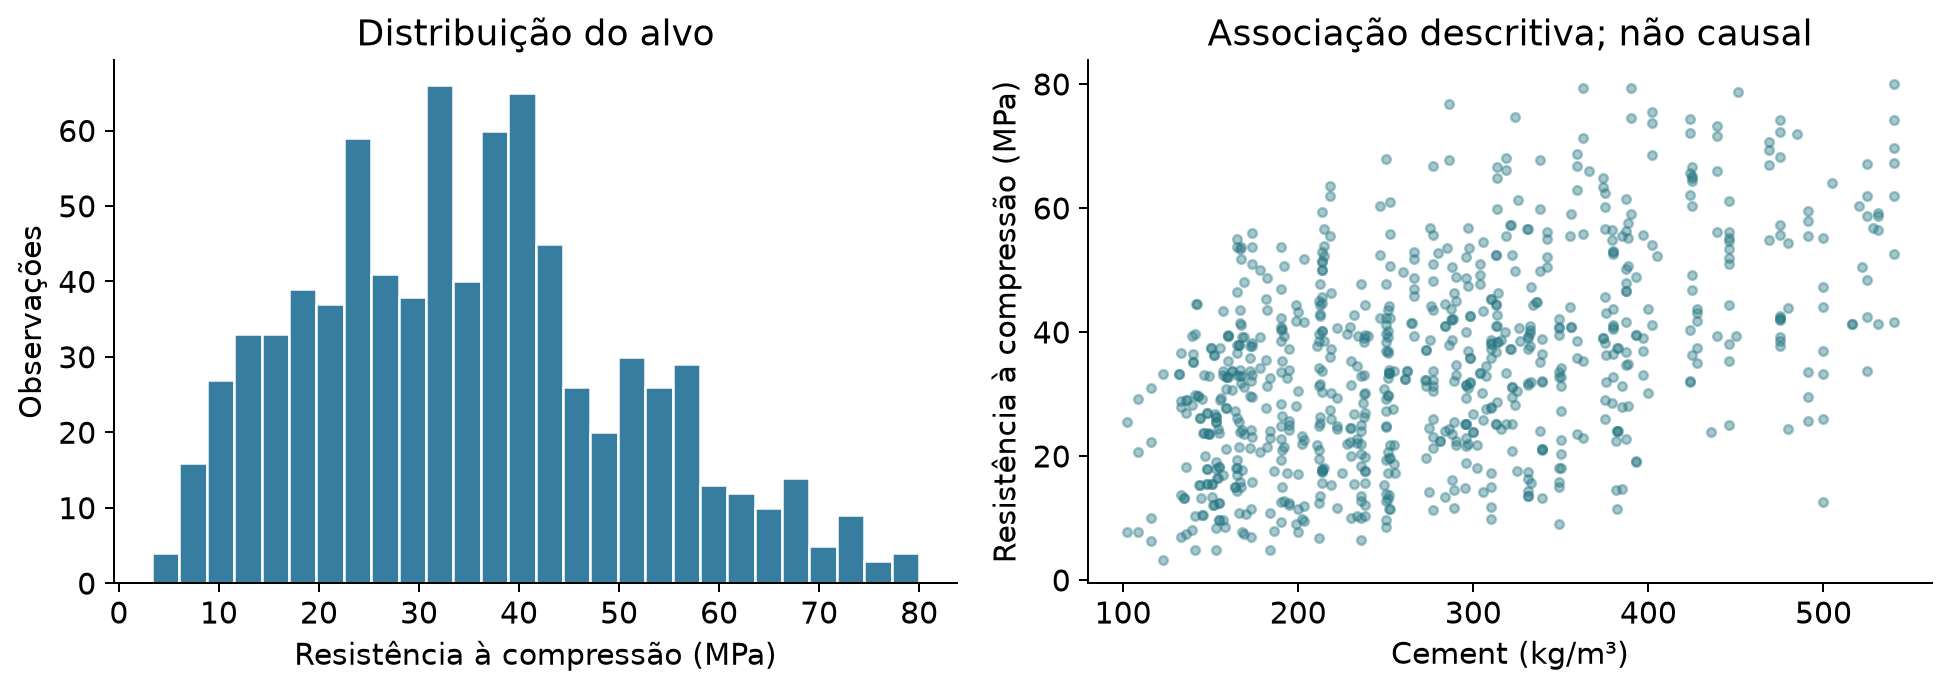

In [11]:
show_figure('01_eda_distributions')

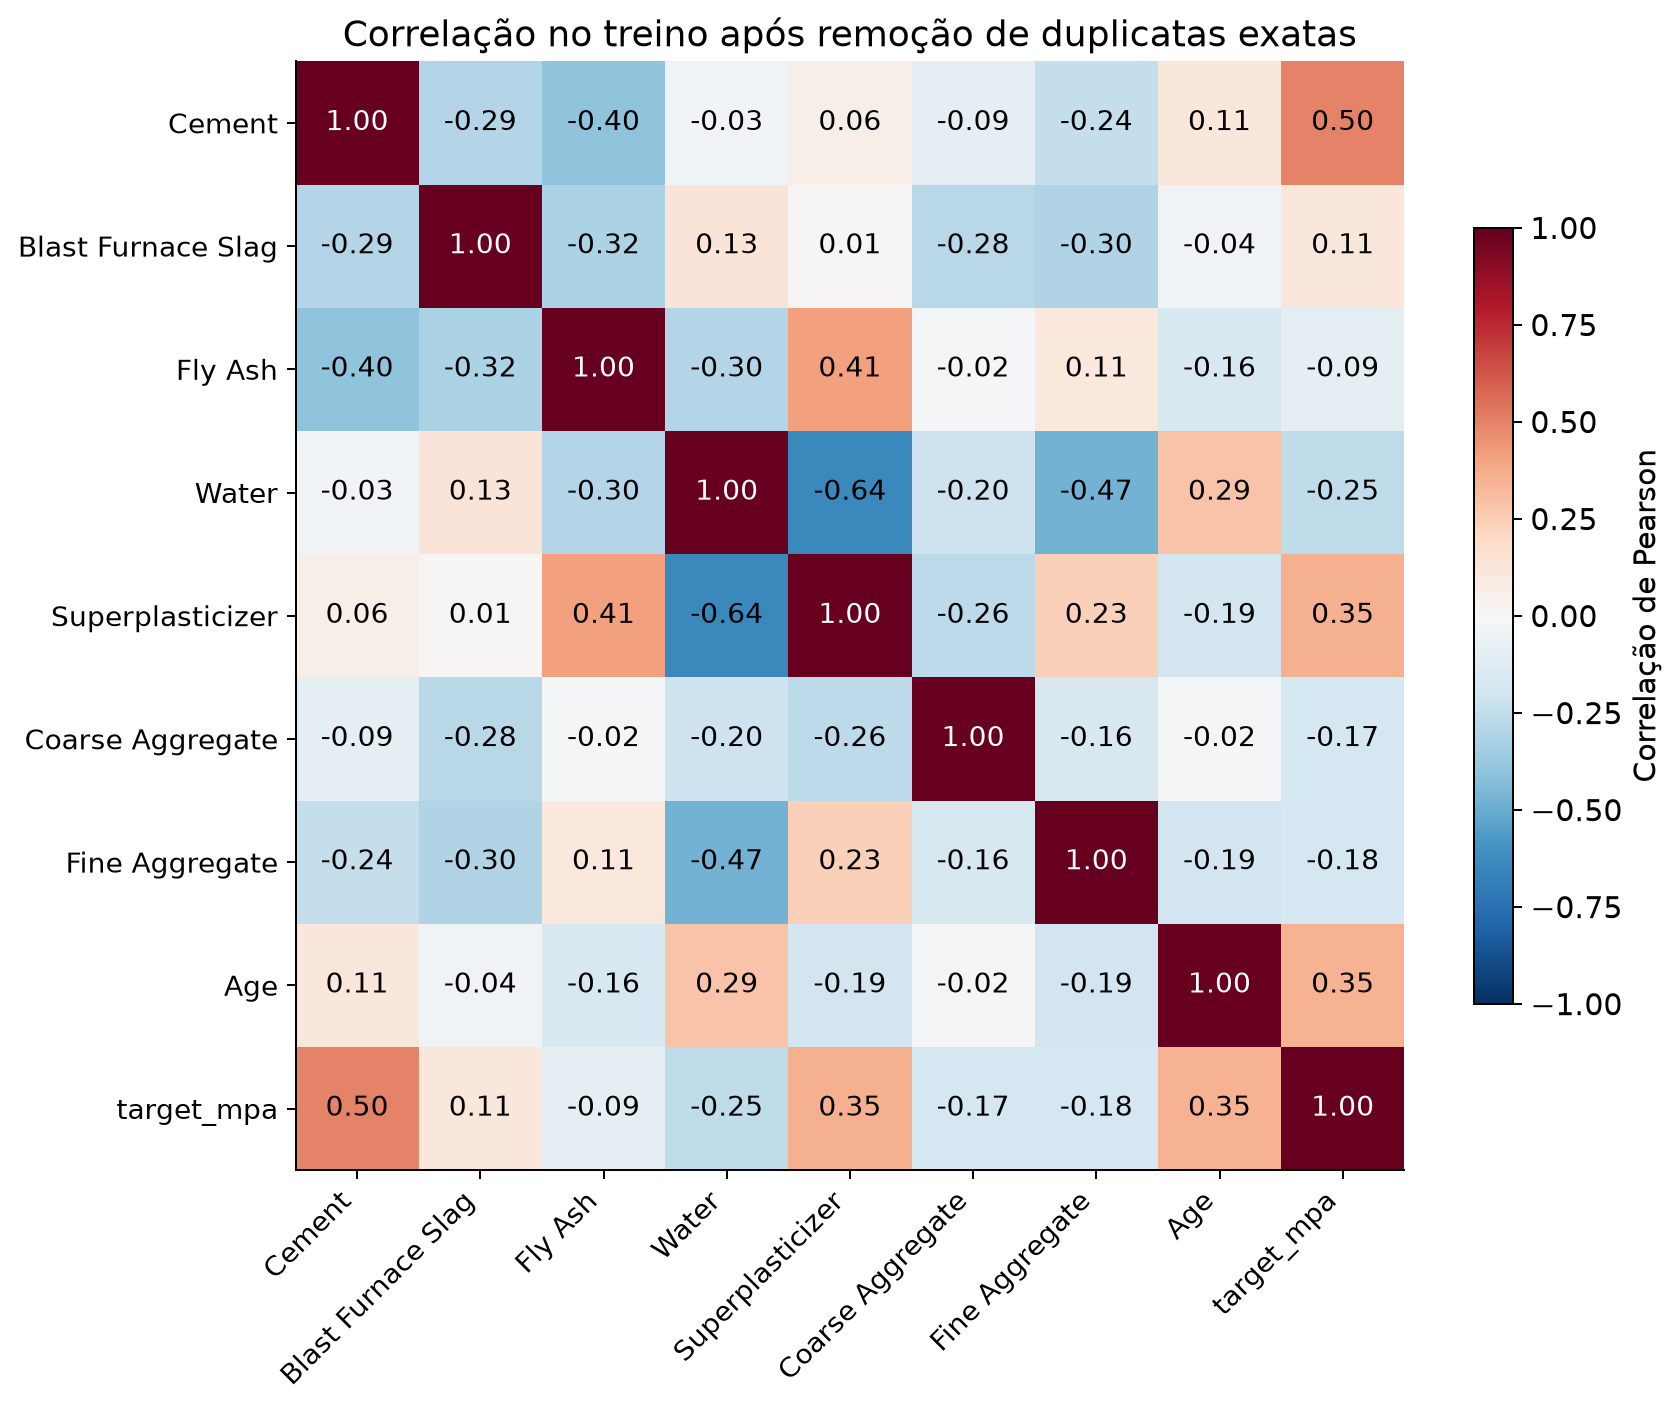

In [12]:
show_figure('02_eda_correlations')

### 2. Baseline sem otimização

In [13]:
display(metrics[metrics.method == 'baseline'][['method','cv_rmse','test_rmse','test_mae','test_r2','baseline_fit_seconds','search_seconds','total_seconds']])

,method,cv_rmse,test_rmse,test_mae,test_r2,baseline_fit_seconds,search_seconds,total_seconds
0,baseline,5.295371,5.60385,4.1284,0.894735,0.096001,0.253275,0.349276


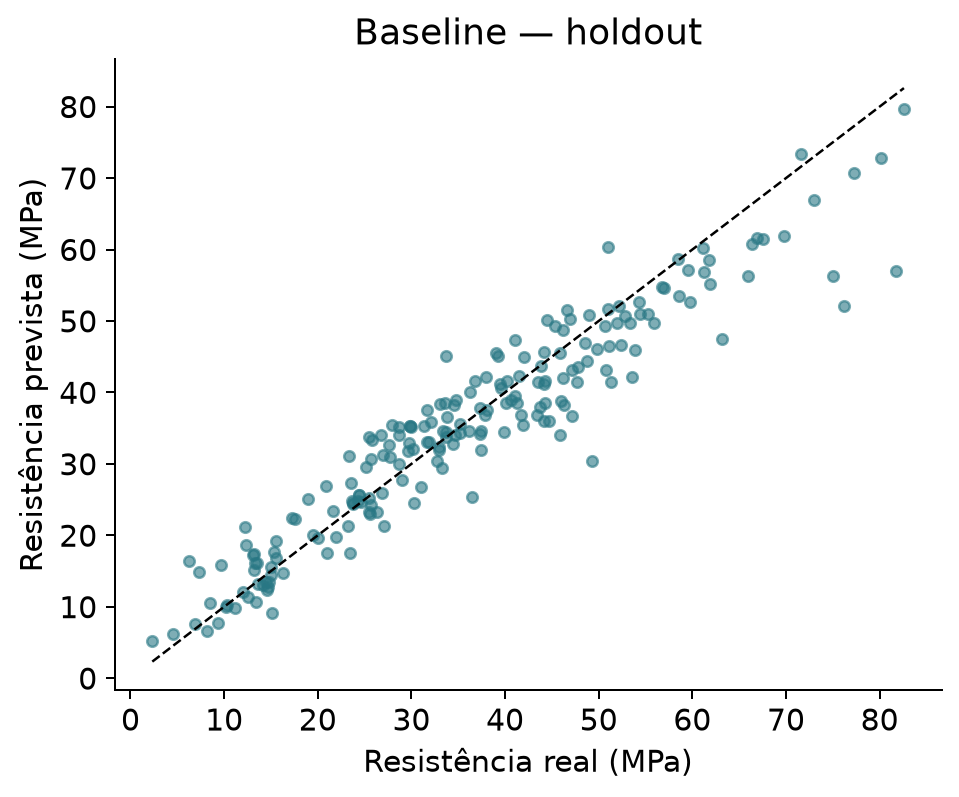

In [14]:
show_figure('03_baseline_predictions')

In [15]:
p=ROOT/'results'/'supplemental-baselines.csv'
if p.exists(): display(pd.read_csv(p))

,method,cv_rmse,test_rmse,test_mae,test_r2,search_seconds,refit_seconds,total_seconds
0,dummy_mean,16.028345,17.296410,13.971915,-0.002819,0.149929,0.013361,0.163290
1,ridge_alpha1,10.201809,11.193353,8.897598,0.580018,0.015684,0.005643,0.021327


Os modelos Dummy e Ridge acima, quando presentes, são controles auxiliares. O baseline obrigatório da comparação permanece GBR com os defaults sklearn e seed 42.

### 3–4. Grid Search, Random Search e superfície do espaço

A convergência acumula os candidatos na ordem registrada em `cv_results_`. Com folds paralelos, isso não equivale necessariamente à cronologia de término de cada fit; a grade também não tem uma dinâmica adaptativa própria.

In [16]:
display(metrics[metrics.method.isin(['grid','random'])][['method','cv_rmse','test_rmse','test_mae','test_r2','total_seconds','n_evaluations','params_json']])

,method,cv_rmse,test_rmse,test_mae,test_r2,total_seconds,n_evaluations,params_json
1,grid,4.732687,4.463024,3.141136,0.933232,4.134465,36,"{""learning_rate"": 0.2, ""n_estimators"": 150, ""s..."
2,random,4.732687,4.463024,3.141136,0.933232,3.412393,30,"{""learning_rate"": 0.2, ""n_estimators"": 150, ""s..."


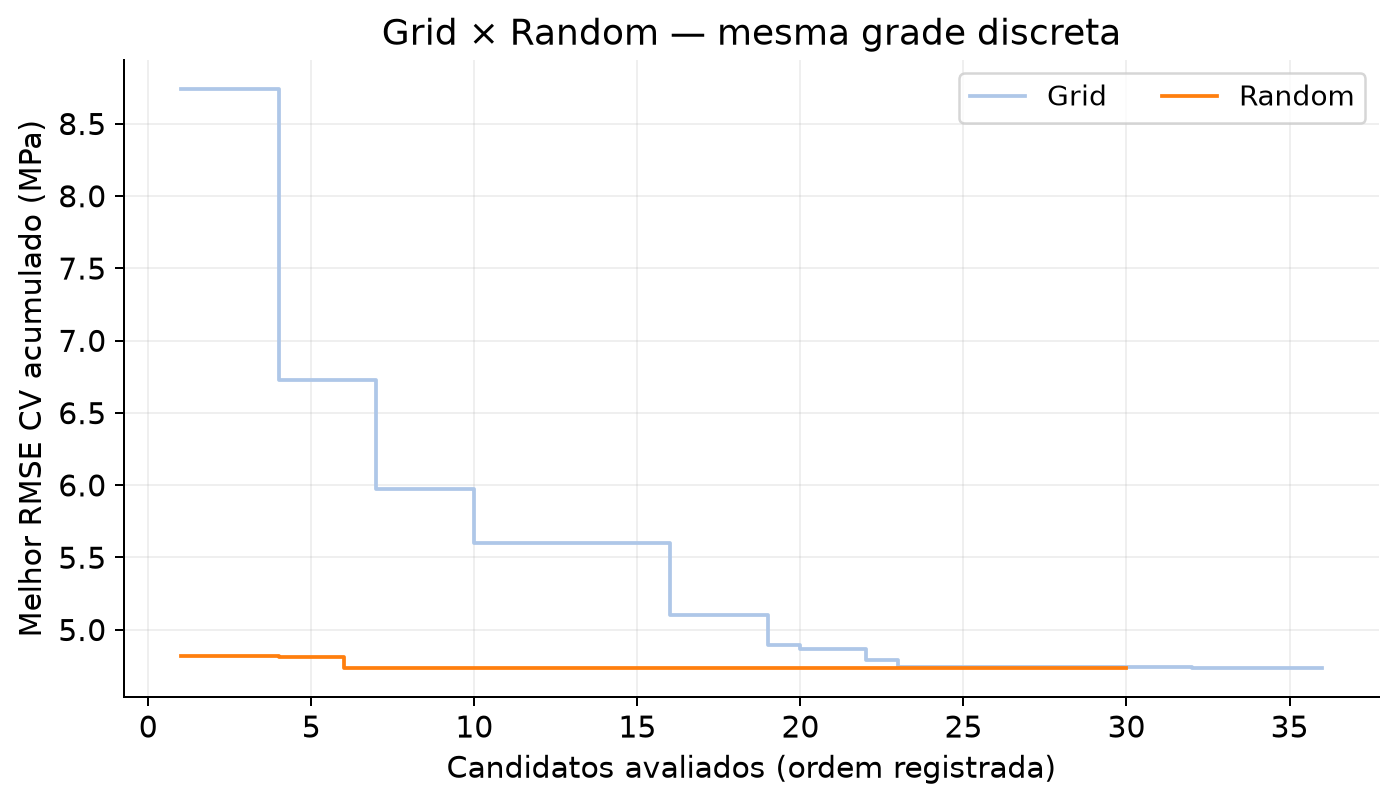

In [17]:
show_figure('04_grid_random_convergence')

In [18]:
display(Markdown(analysis['narrative']['random_vs_grid']))

Random igualou o ótimo CV da grade na avaliação 6. Ele não pode superá-lo estritamente, pois amostra um subconjunto dos mesmos 36 candidatos sob folds e seed idênticos.

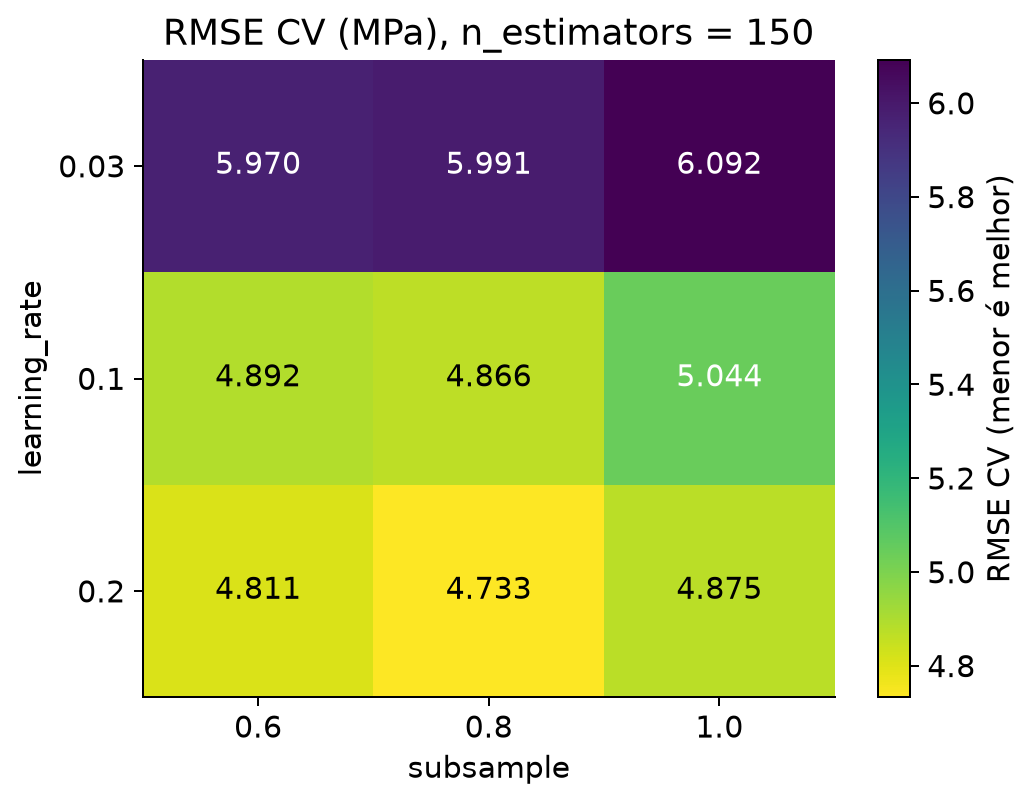

In [19]:
show_figure('05_grid_heatmap')

In [20]:
display(Markdown(analysis['narrative']['heatmap']))

No corte n_estimators=150, a mudança LR0,03→0,20 altera o RMSE em -1.159 MPa em subsample=0.6, -1.258 MPa em subsample=0.8, -1.217 MPa em subsample=1.0. Efeitos diferentes sugerem interação no conjunto discretizado; nove pontos não permitem demonstrar suavidade nem mapear todos os ótimos locais contínuos.

In [21]:
display(pd.DataFrame(analysis['grid_random']['spearman']))

,hyperparameter,rho,p_exploratory,n
0,learning_rate,-0.759383,0.000001,30
1,subsample,0.152775,0.420257,30
2,n_estimators,-0.621634,0.000246,30


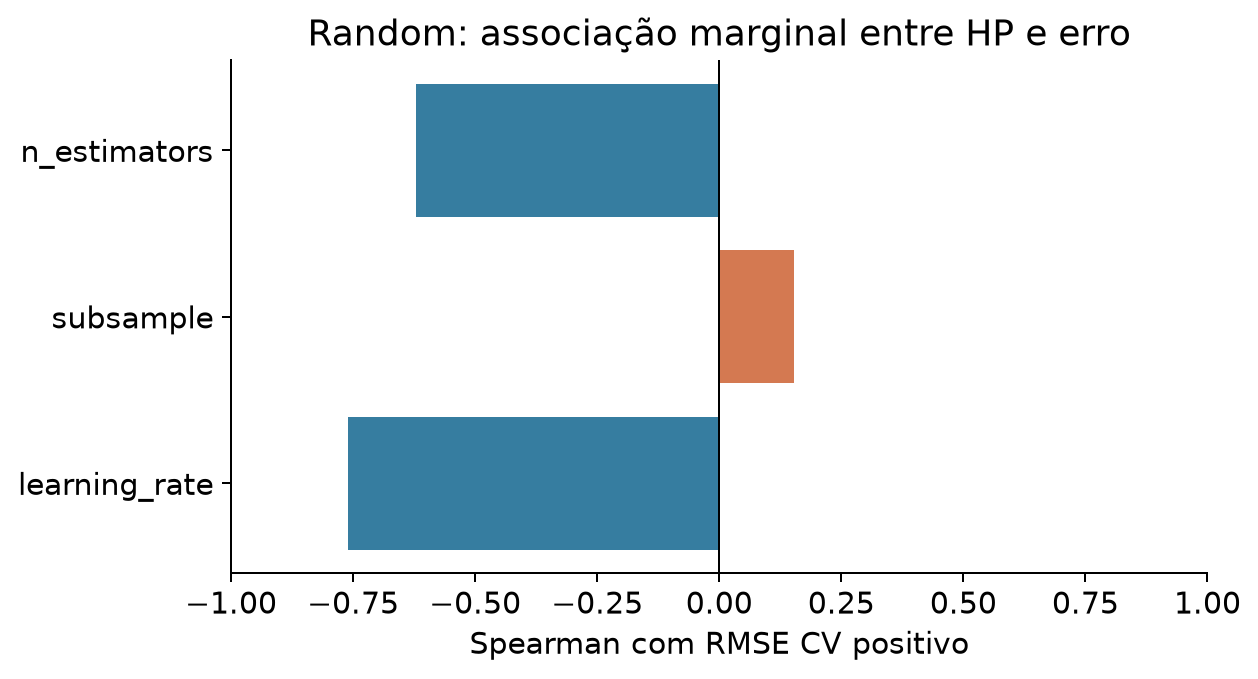

In [22]:
show_figure('06_random_spearman')

In [23]:
display(Markdown(analysis['narrative']['spearman']))

A maior associação marginal absoluta foi de learning_rate (rho=-0.759) com RMSE CV positivo. Sinal negativo associa valores maiores a erros menores. Correlação marginal não separa interações e não prova causalidade ou importância global.

### 5. Síntese do exercício 1

In [24]:
display(metrics[metrics.method.isin(['baseline','grid','random'])][['method','cv_rmse','test_rmse','total_seconds','n_evaluations']])

,method,cv_rmse,test_rmse,total_seconds,n_evaluations
0,baseline,5.295371,5.603850,0.349276,1
1,grid,4.732687,4.463024,4.134465,36
2,random,4.732687,4.463024,3.412393,30


In [25]:
b=metrics.set_index('method').loc['baseline']
for key in ['grid','random']:
    r=metrics.set_index('method').loc[key]
    gain=100*(b.test_rmse-r.test_rmse)/b.test_rmse
    display(Markdown(f'**{key}:** variação relativa do RMSE de teste: {gain:.2f}% de redução; '
                     f'custo total {r.total_seconds:.3f} s, contra {b.total_seconds:.3f} s do baseline. '
                     'O ganho é descritivo no holdout; a justificativa operacional depende da tolerância de erro e do custo disponível.'))
display(Markdown(analysis['narrative']['grid_preference']))
display(Markdown(analysis['narrative']['heatmap']))

**grid:** variação relativa do RMSE de teste: 20.36% de redução; custo total 4.134 s, contra 0.349 s do baseline. O ganho é descritivo no holdout; a justificativa operacional depende da tolerância de erro e do custo disponível.

**random:** variação relativa do RMSE de teste: 20.36% de redução; custo total 3.412 s, contra 0.349 s do baseline. O ganho é descritivo no holdout; a justificativa operacional depende da tolerância de erro e do custo disponível.

Grid é útil quando há poucos hiperparâmetros, domínios discretos pequenos e necessidade de cobertura exaustiva e auditável. O número de combinações cresce multiplicativamente; a vantagem não é geral em dimensões maiores.

No corte n_estimators=150, a mudança LR0,03→0,20 altera o RMSE em -1.159 MPa em subsample=0.6, -1.258 MPa em subsample=0.8, -1.217 MPa em subsample=1.0. Efeitos diferentes sugerem interação no conjunto discretizado; nove pontos não permitem demonstrar suavidade nem mapear todos os ótimos locais contínuos.

## Exercício 2

### 6. GP manual com Expected Improvement

Cinco pontos iniciais e dez aquisições EI, kernel Matérn ν=2,5. Cada figura foi salva antes de avaliar o próximo candidato: mapa de média e incerteza, corte posterior no subsample escolhido e EI no mesmo corte. As observações estão no mapa 2D; só observações com o mesmo subsample aparecem no corte. Média ±2σ é incerteza do surrogate condicionado aos dados/kernel, não intervalo de confiança da generalização do GBR.

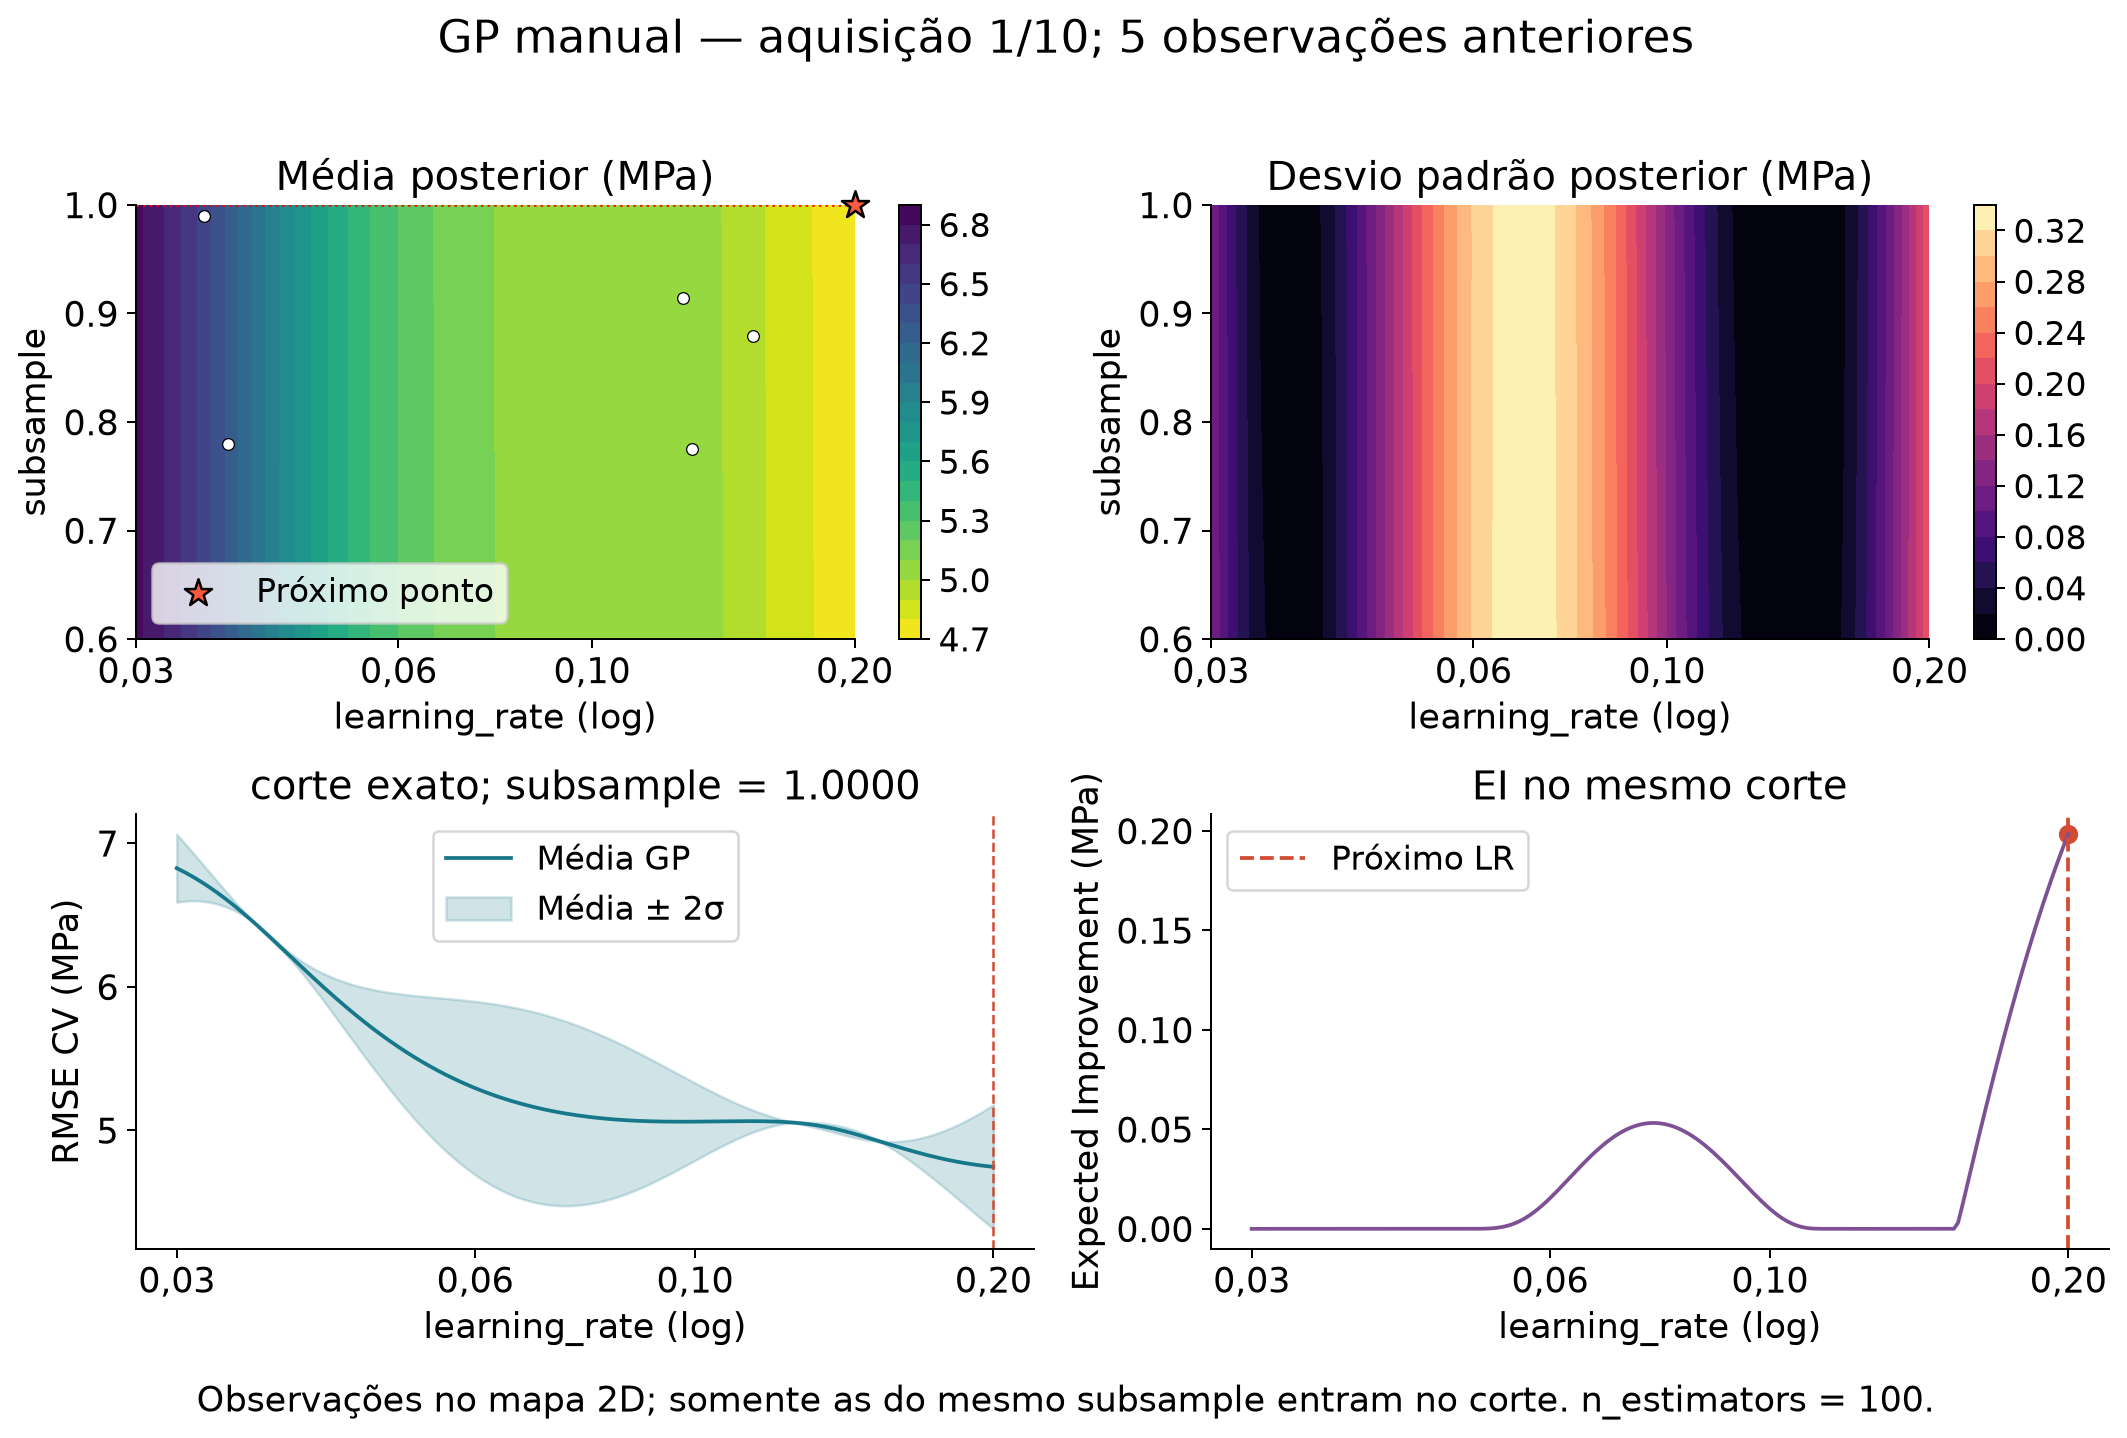

In [26]:
show_figure('gp_iteration_01')

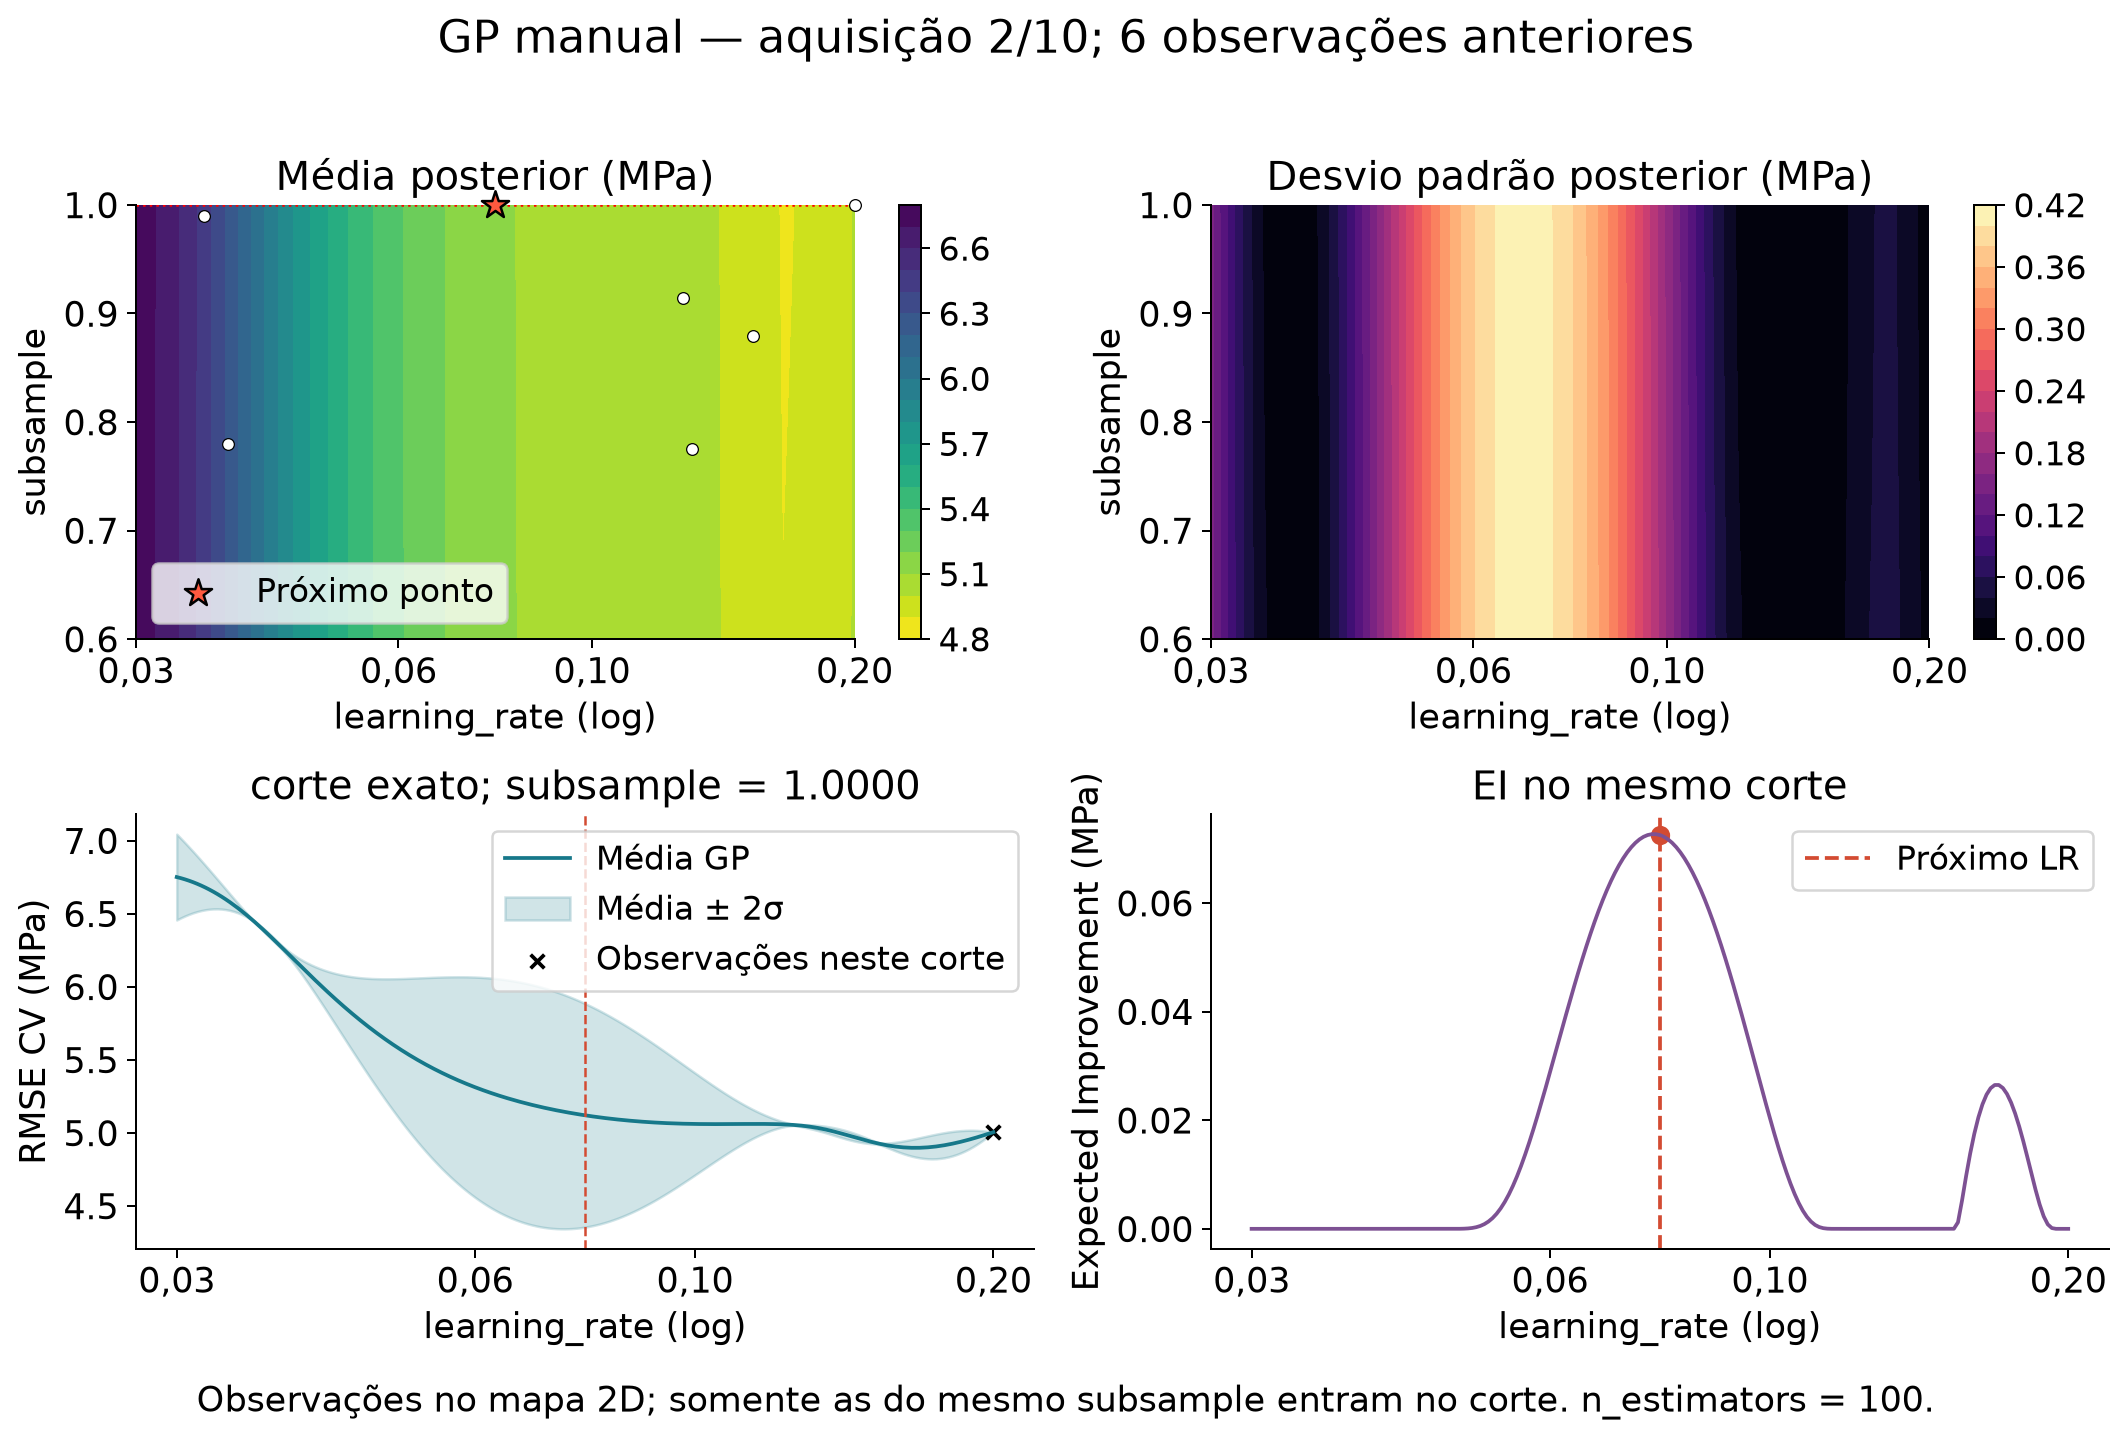

In [27]:
show_figure('gp_iteration_02')

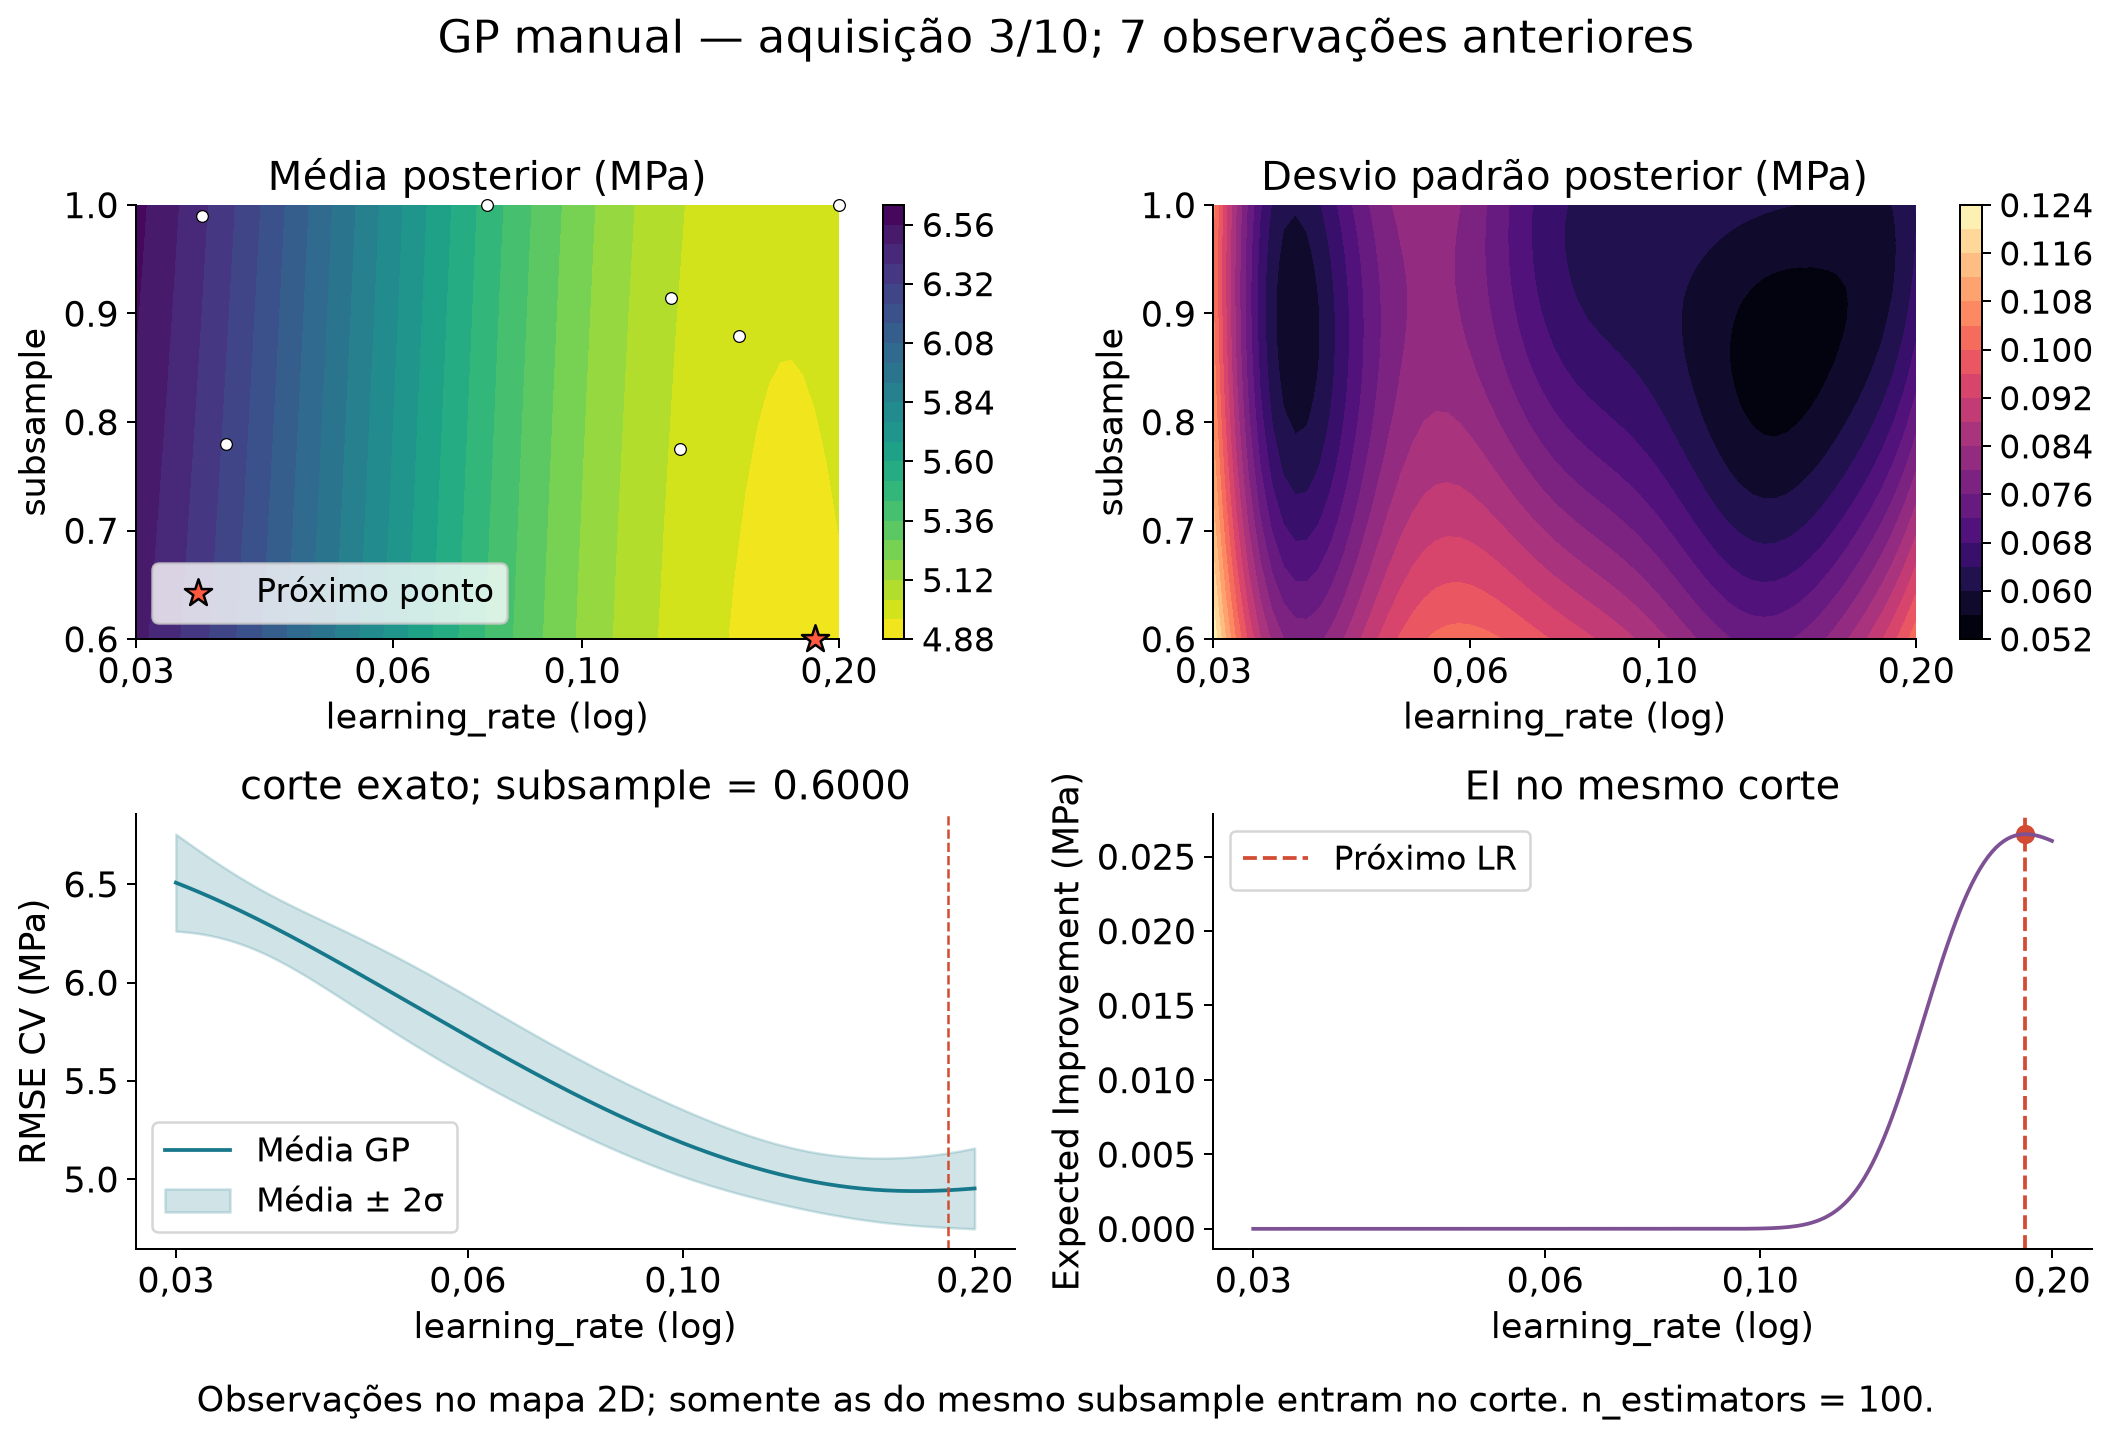

In [28]:
show_figure('gp_iteration_03')

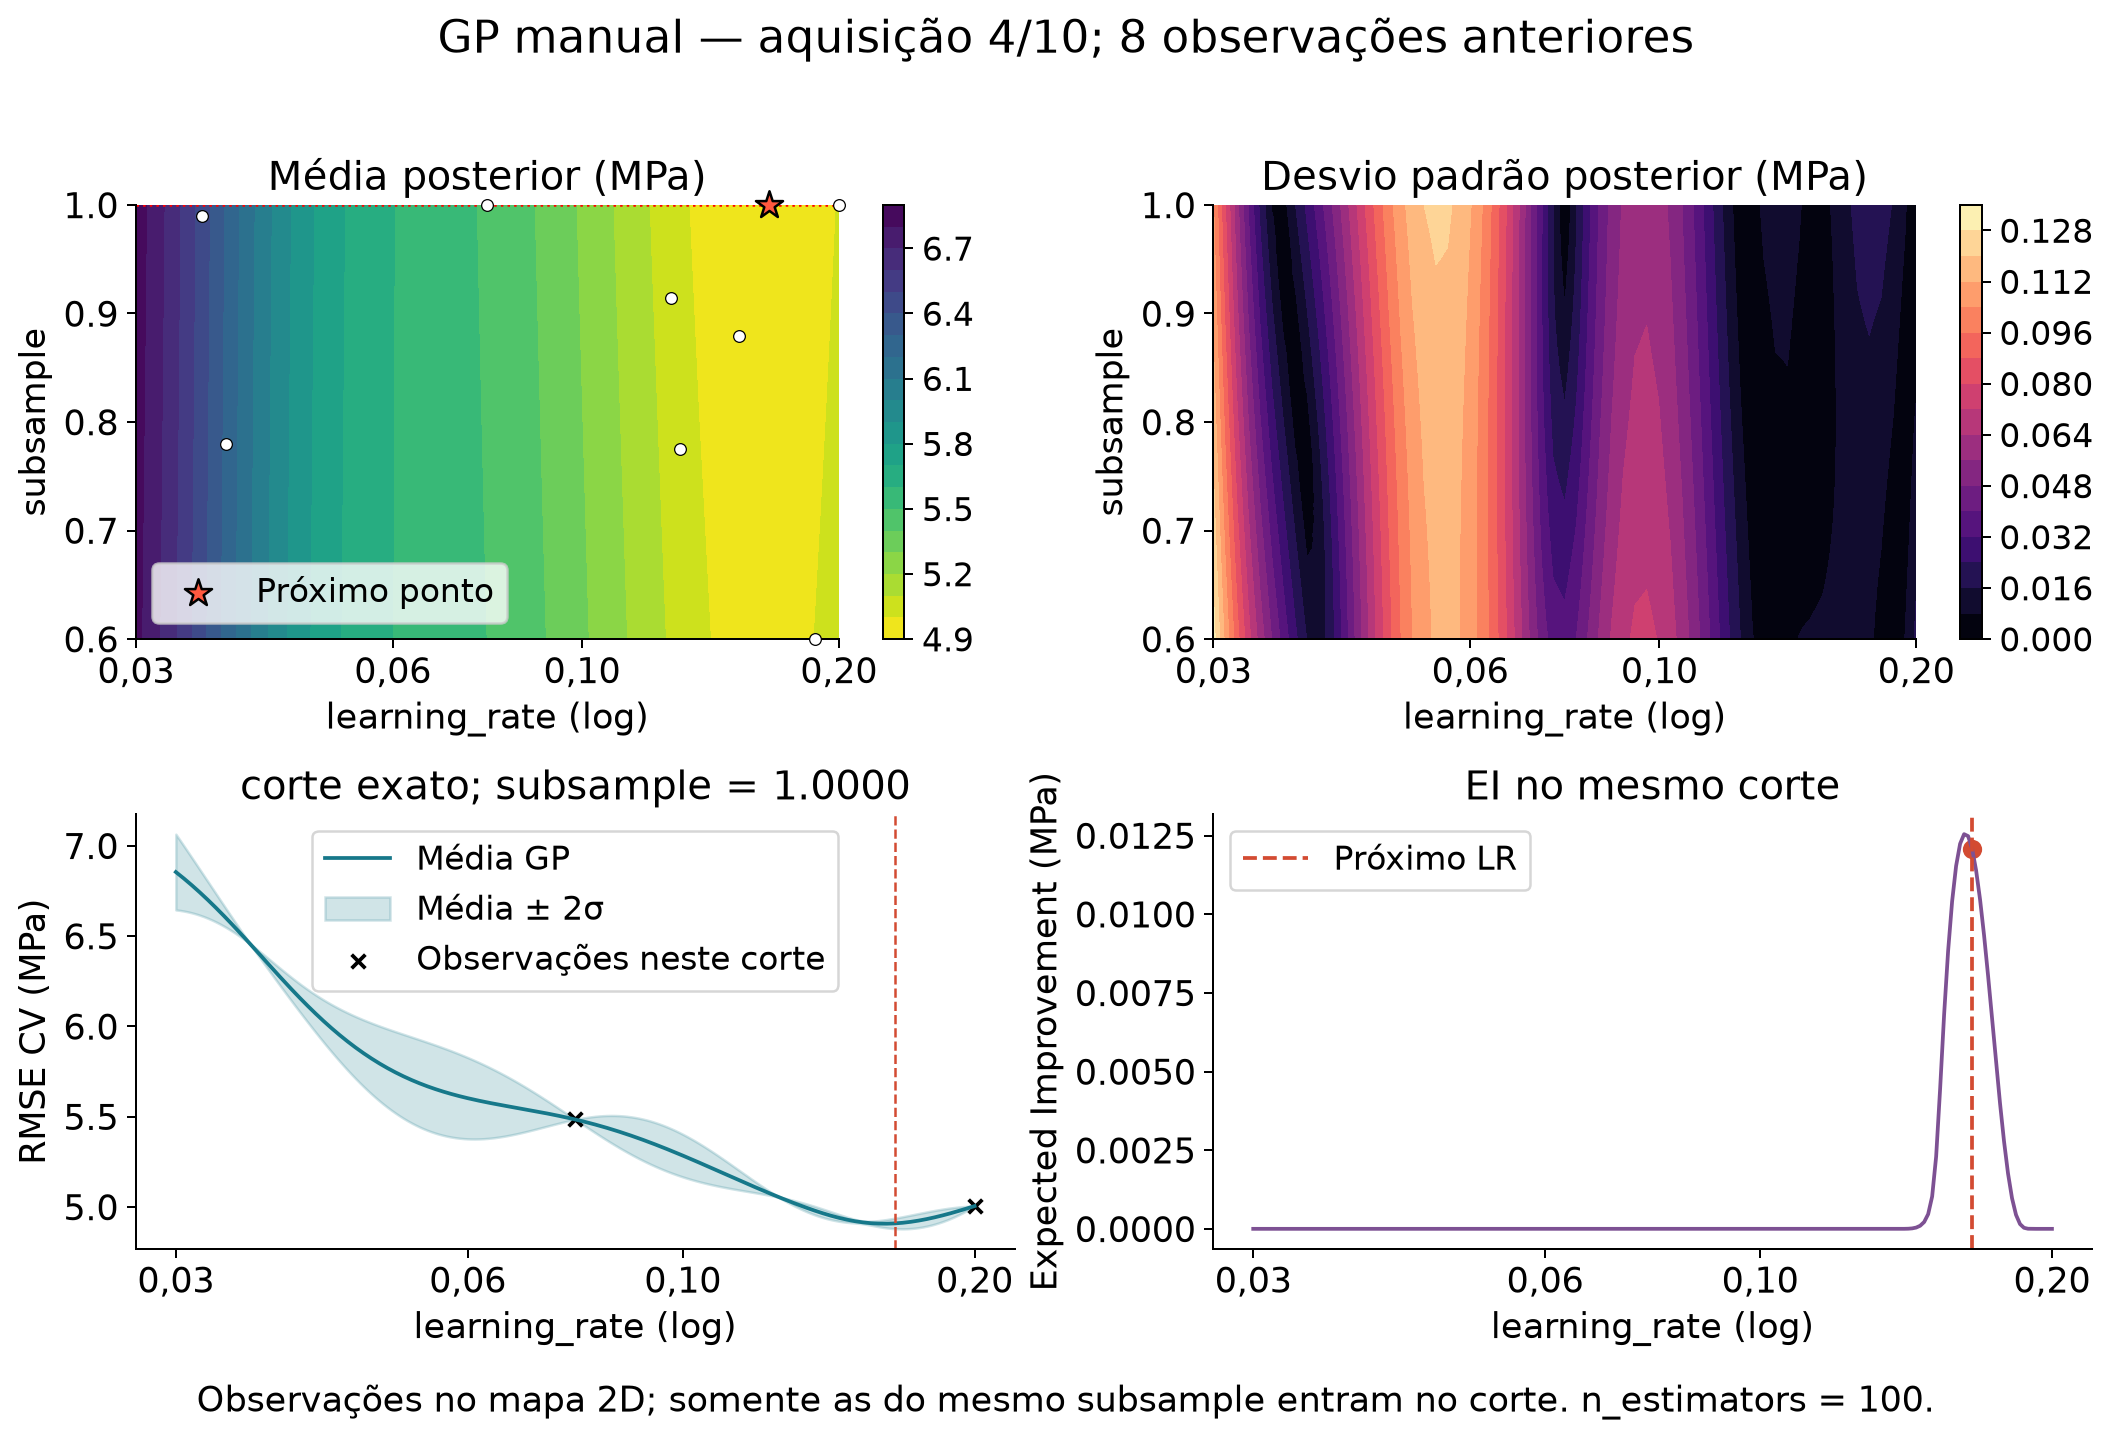

In [29]:
show_figure('gp_iteration_04')

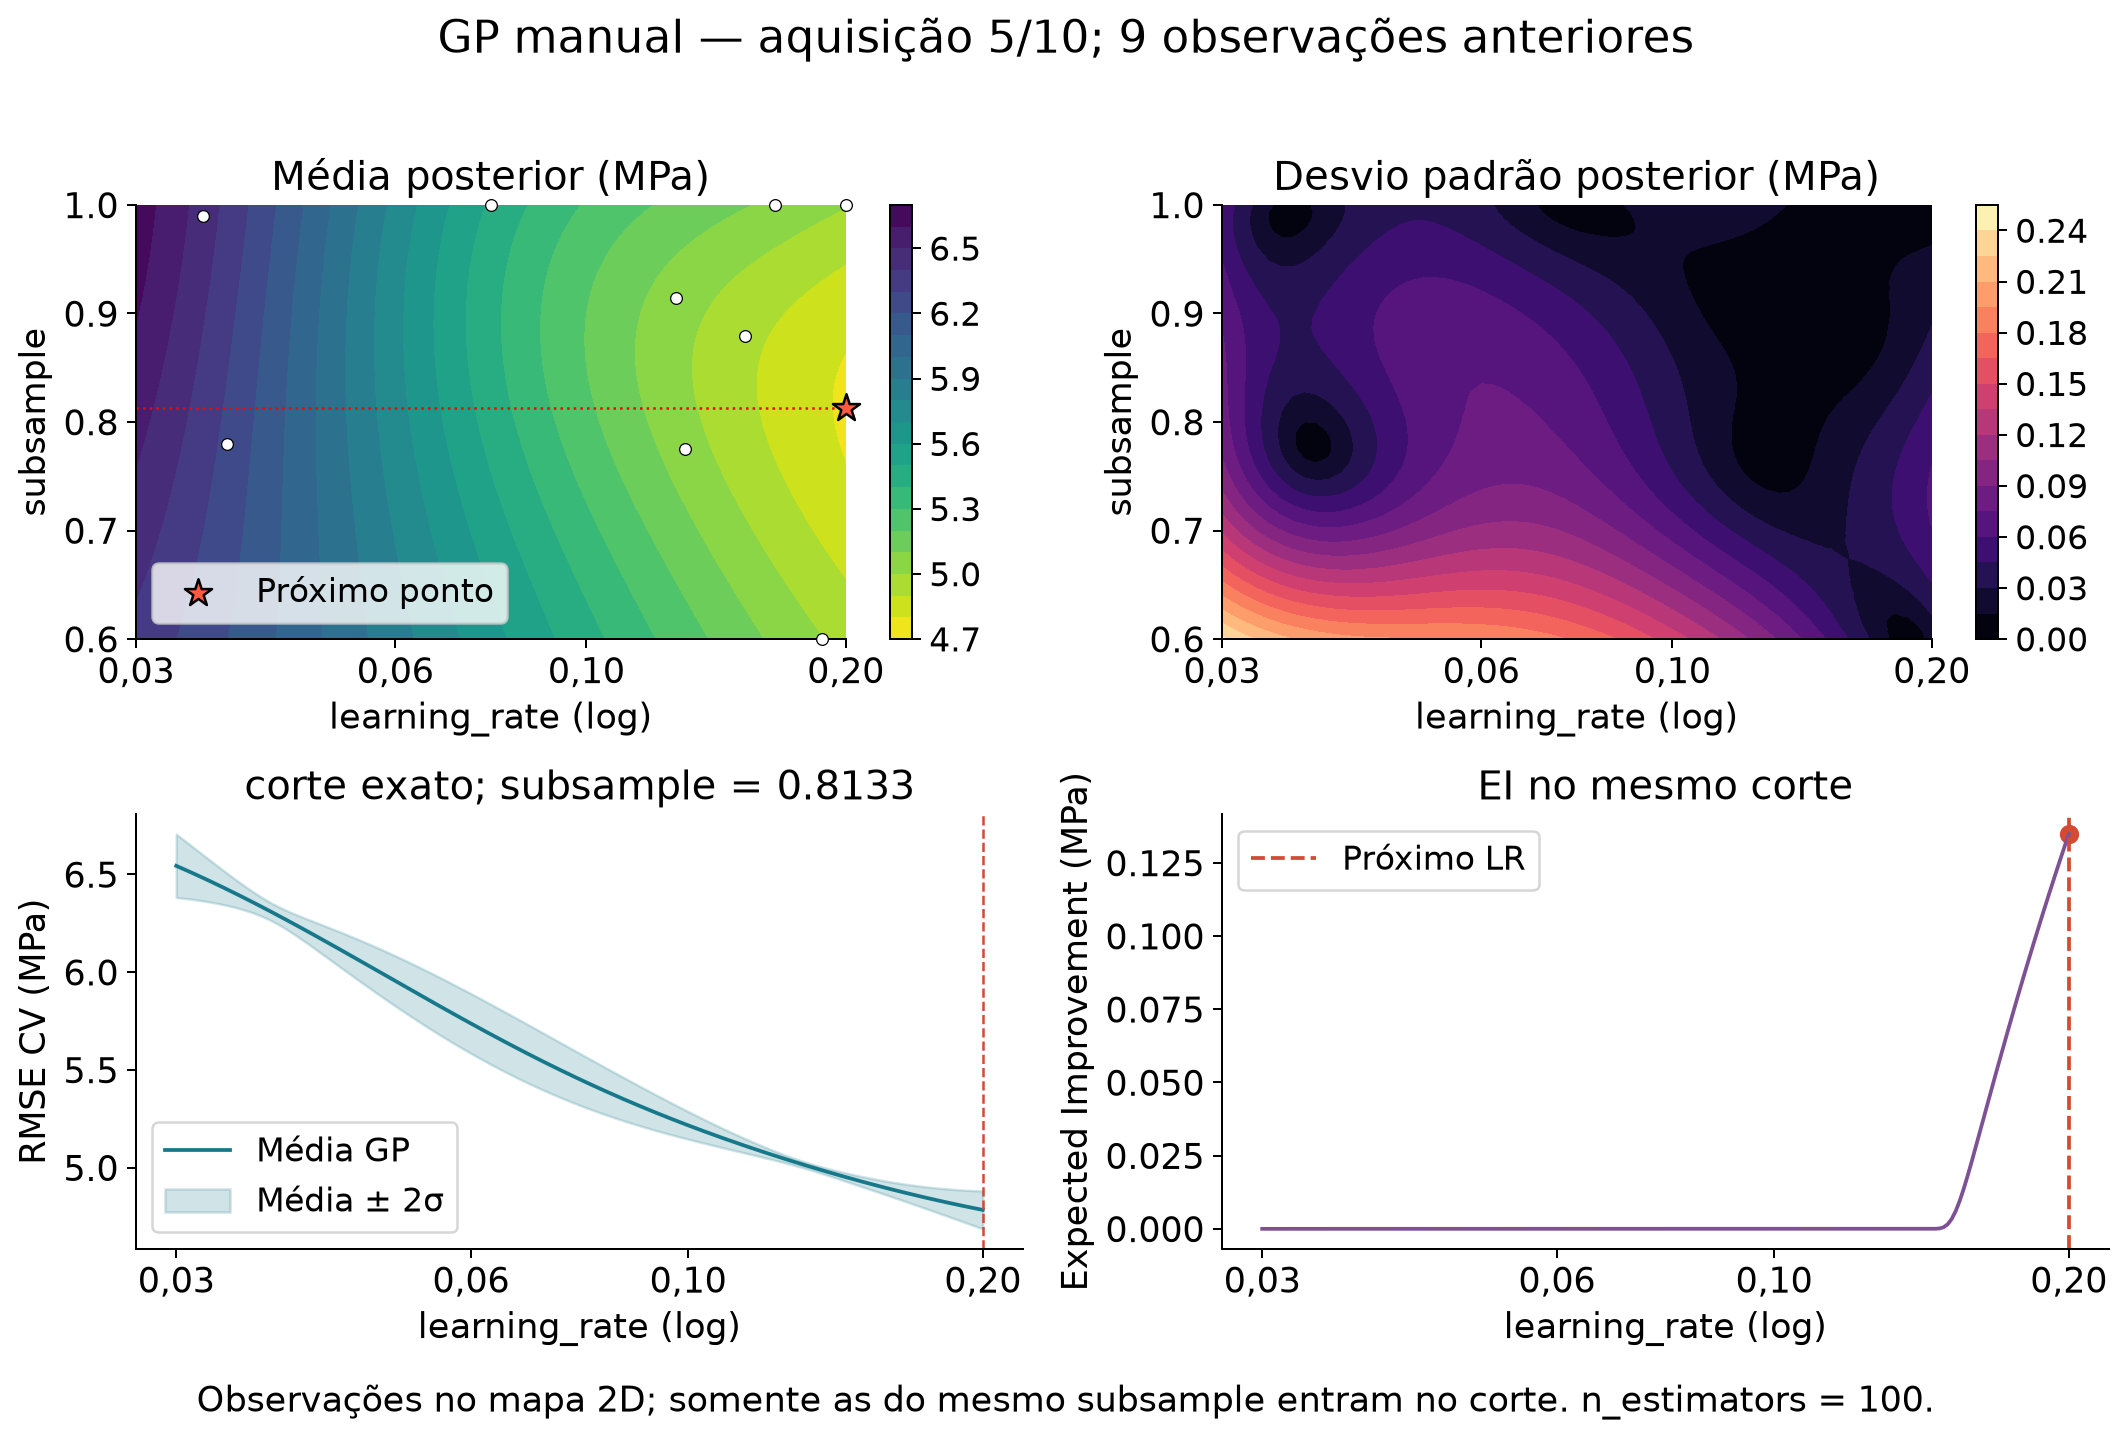

In [30]:
show_figure('gp_iteration_05')

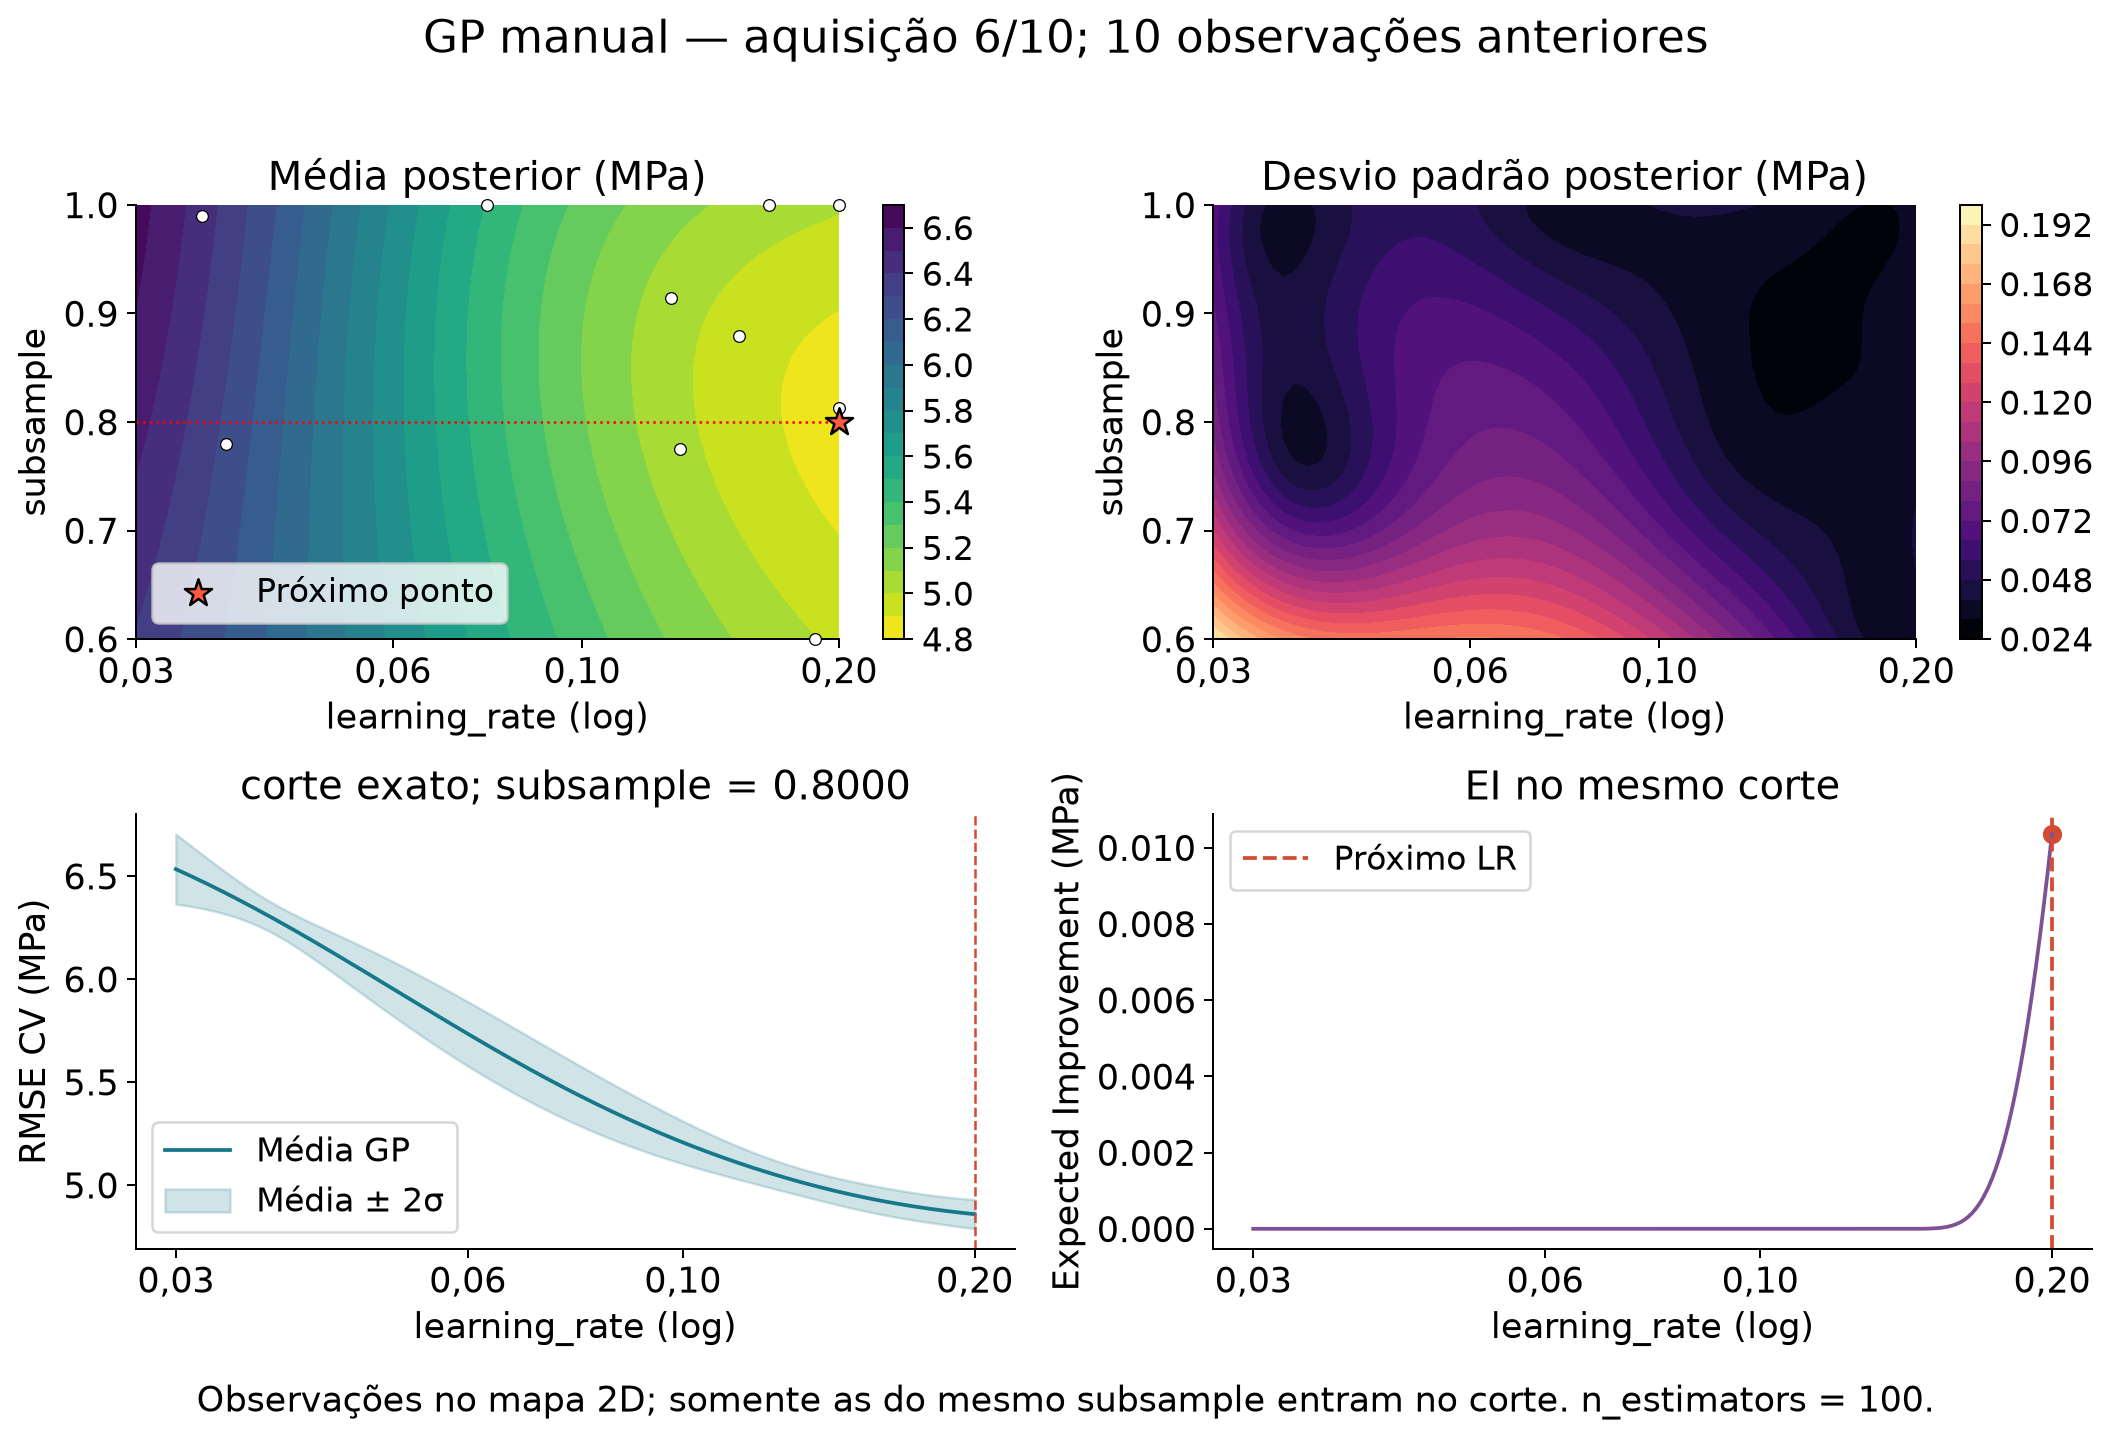

In [31]:
show_figure('gp_iteration_06')

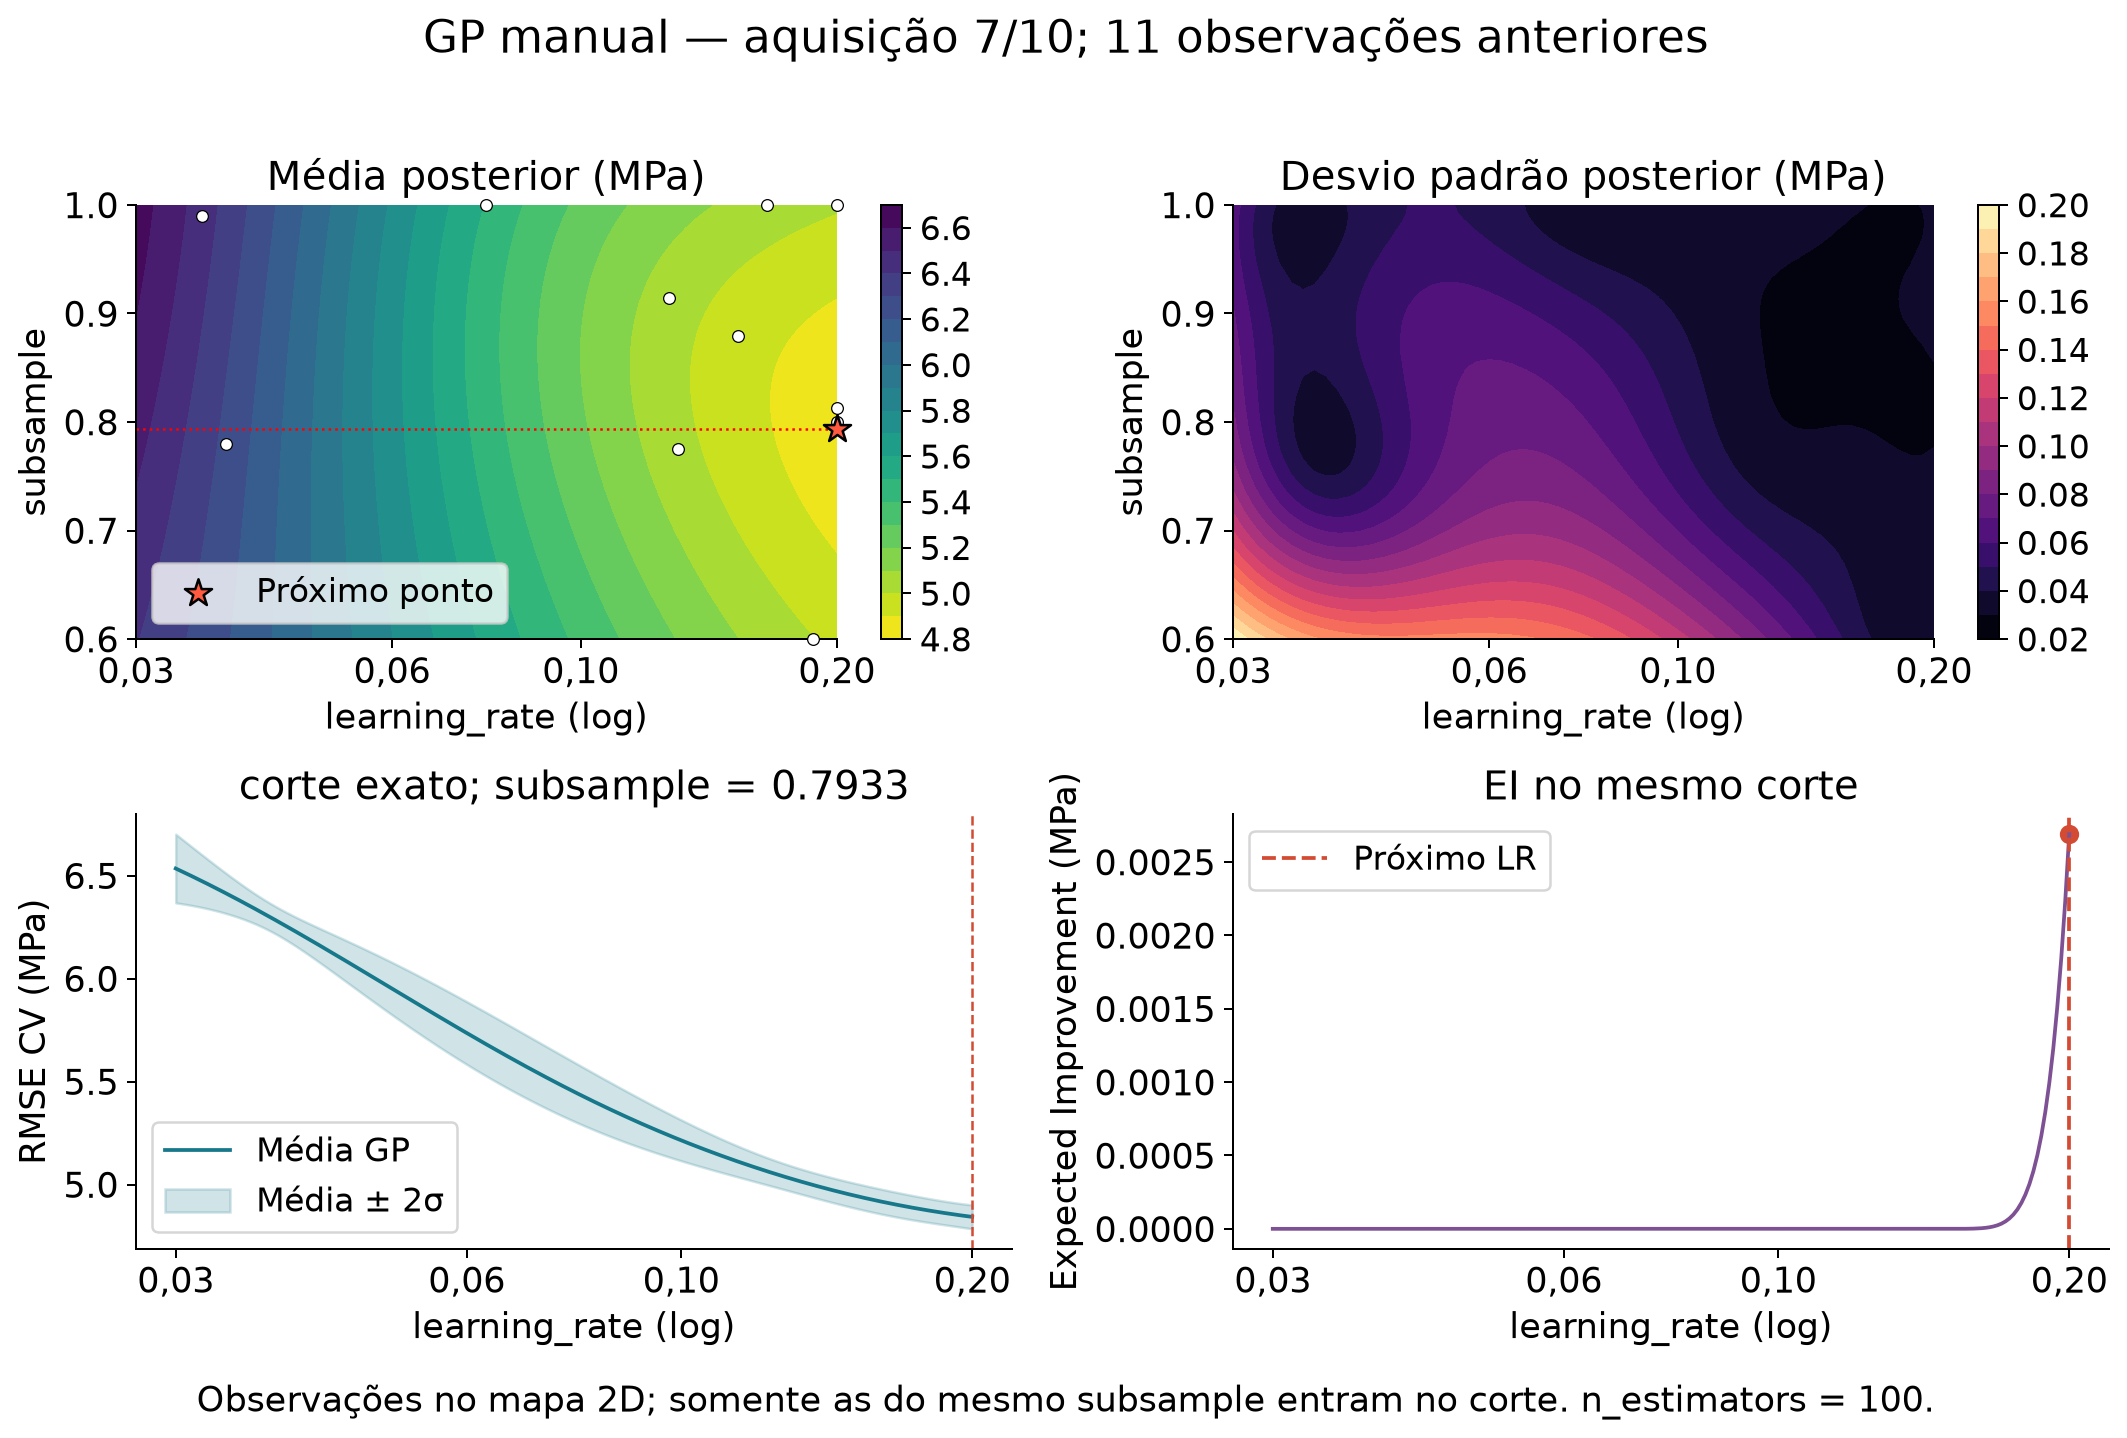

In [32]:
show_figure('gp_iteration_07')

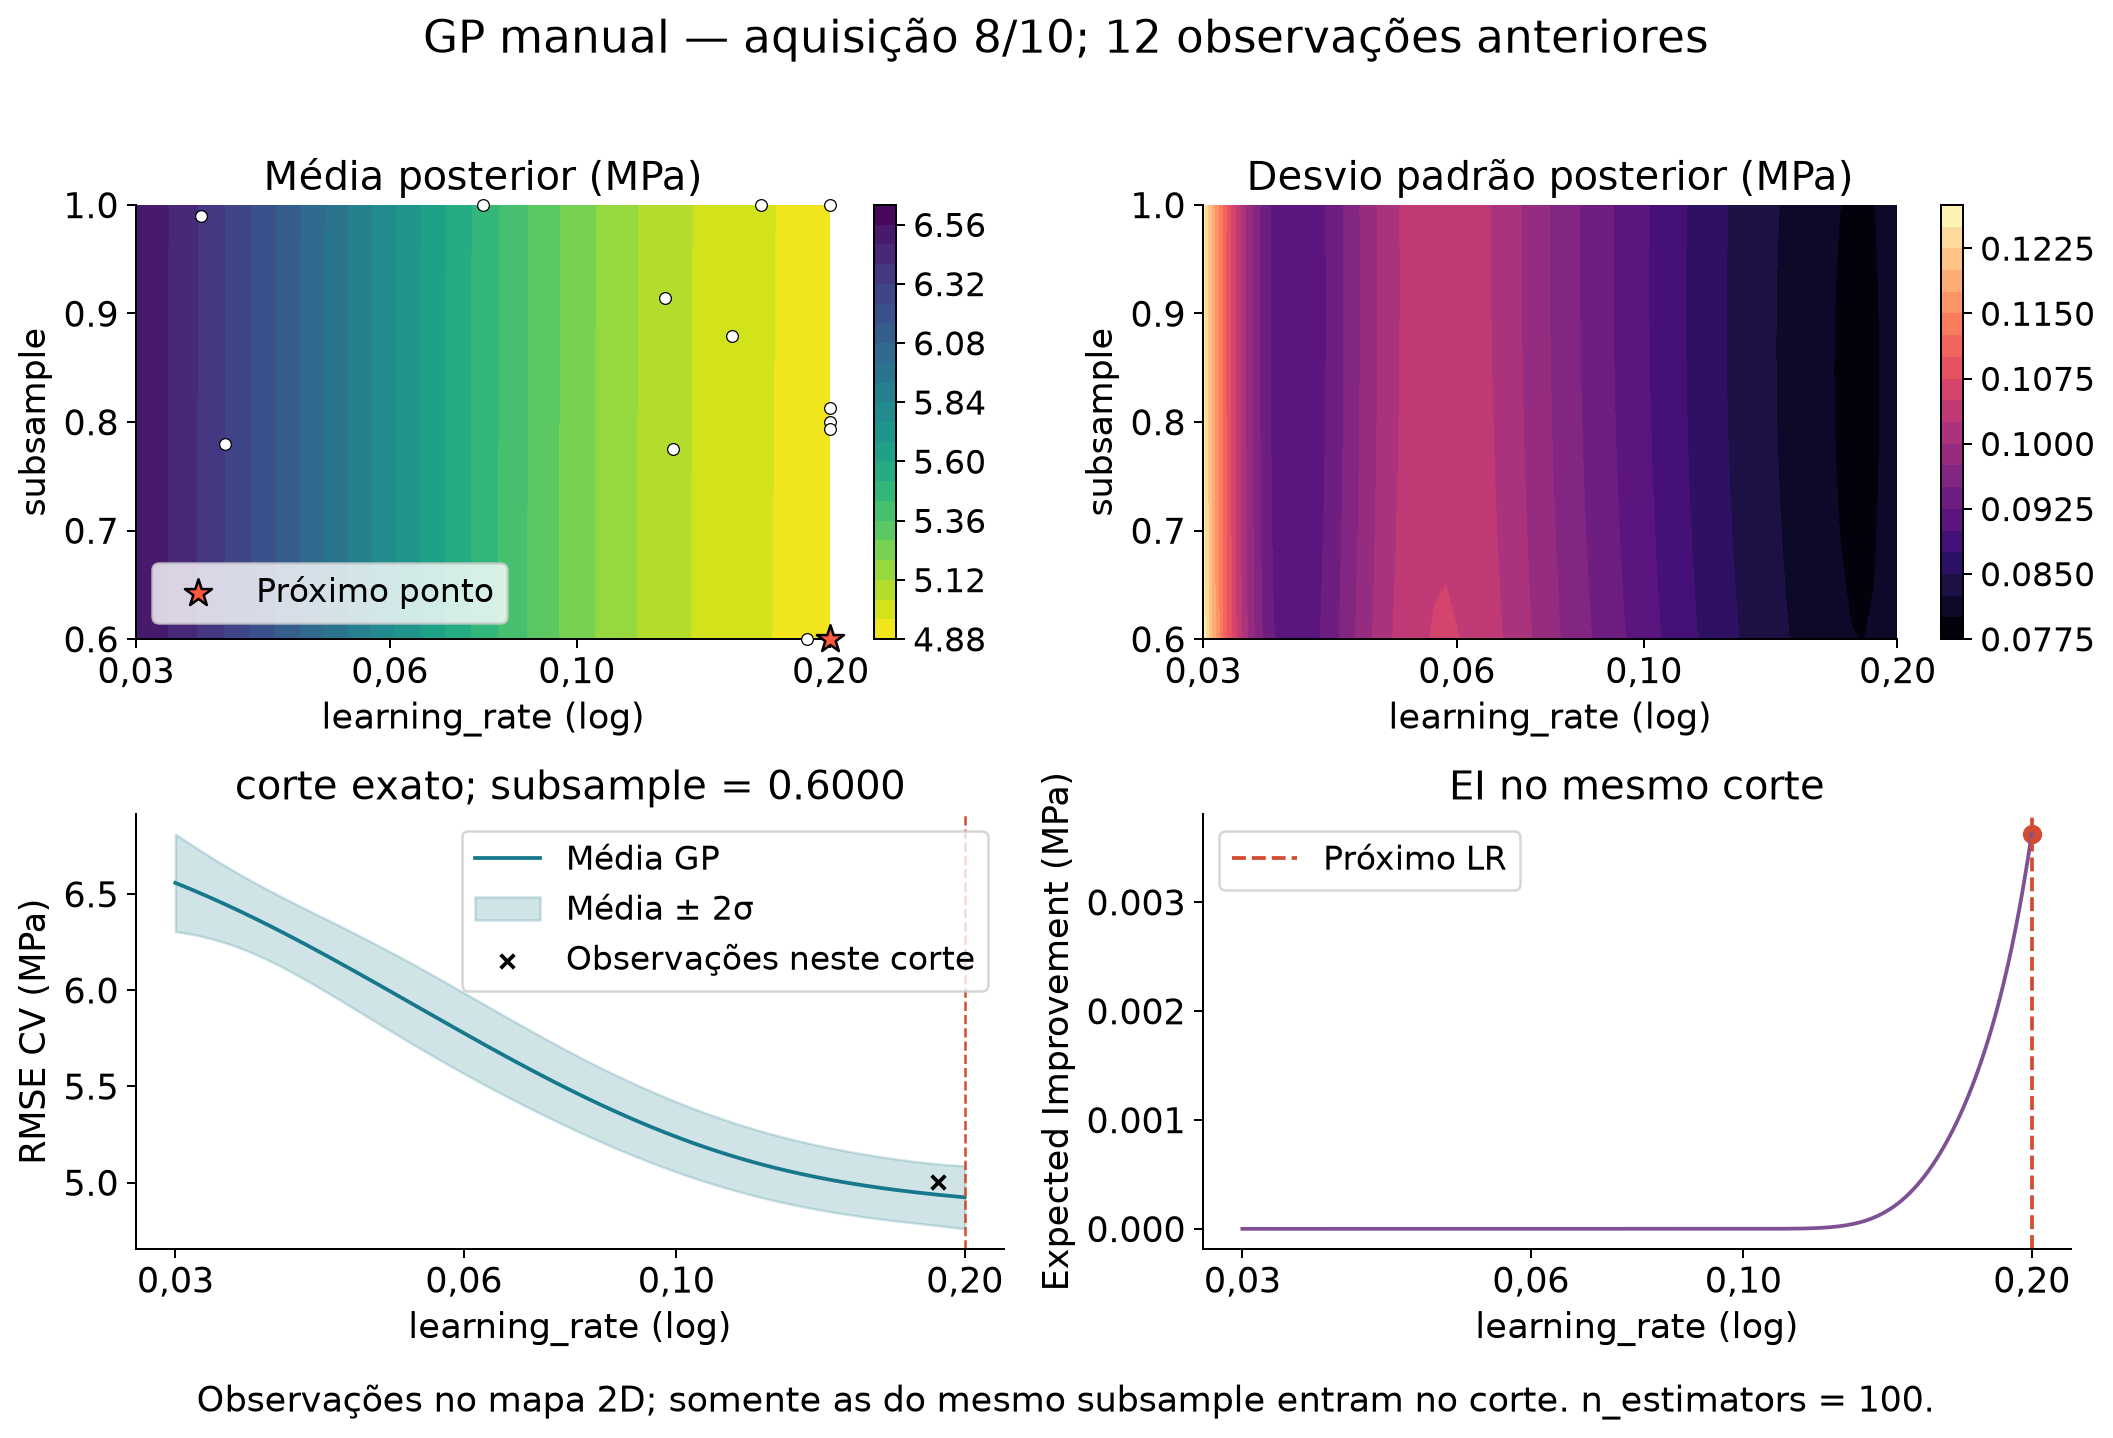

In [33]:
show_figure('gp_iteration_08')

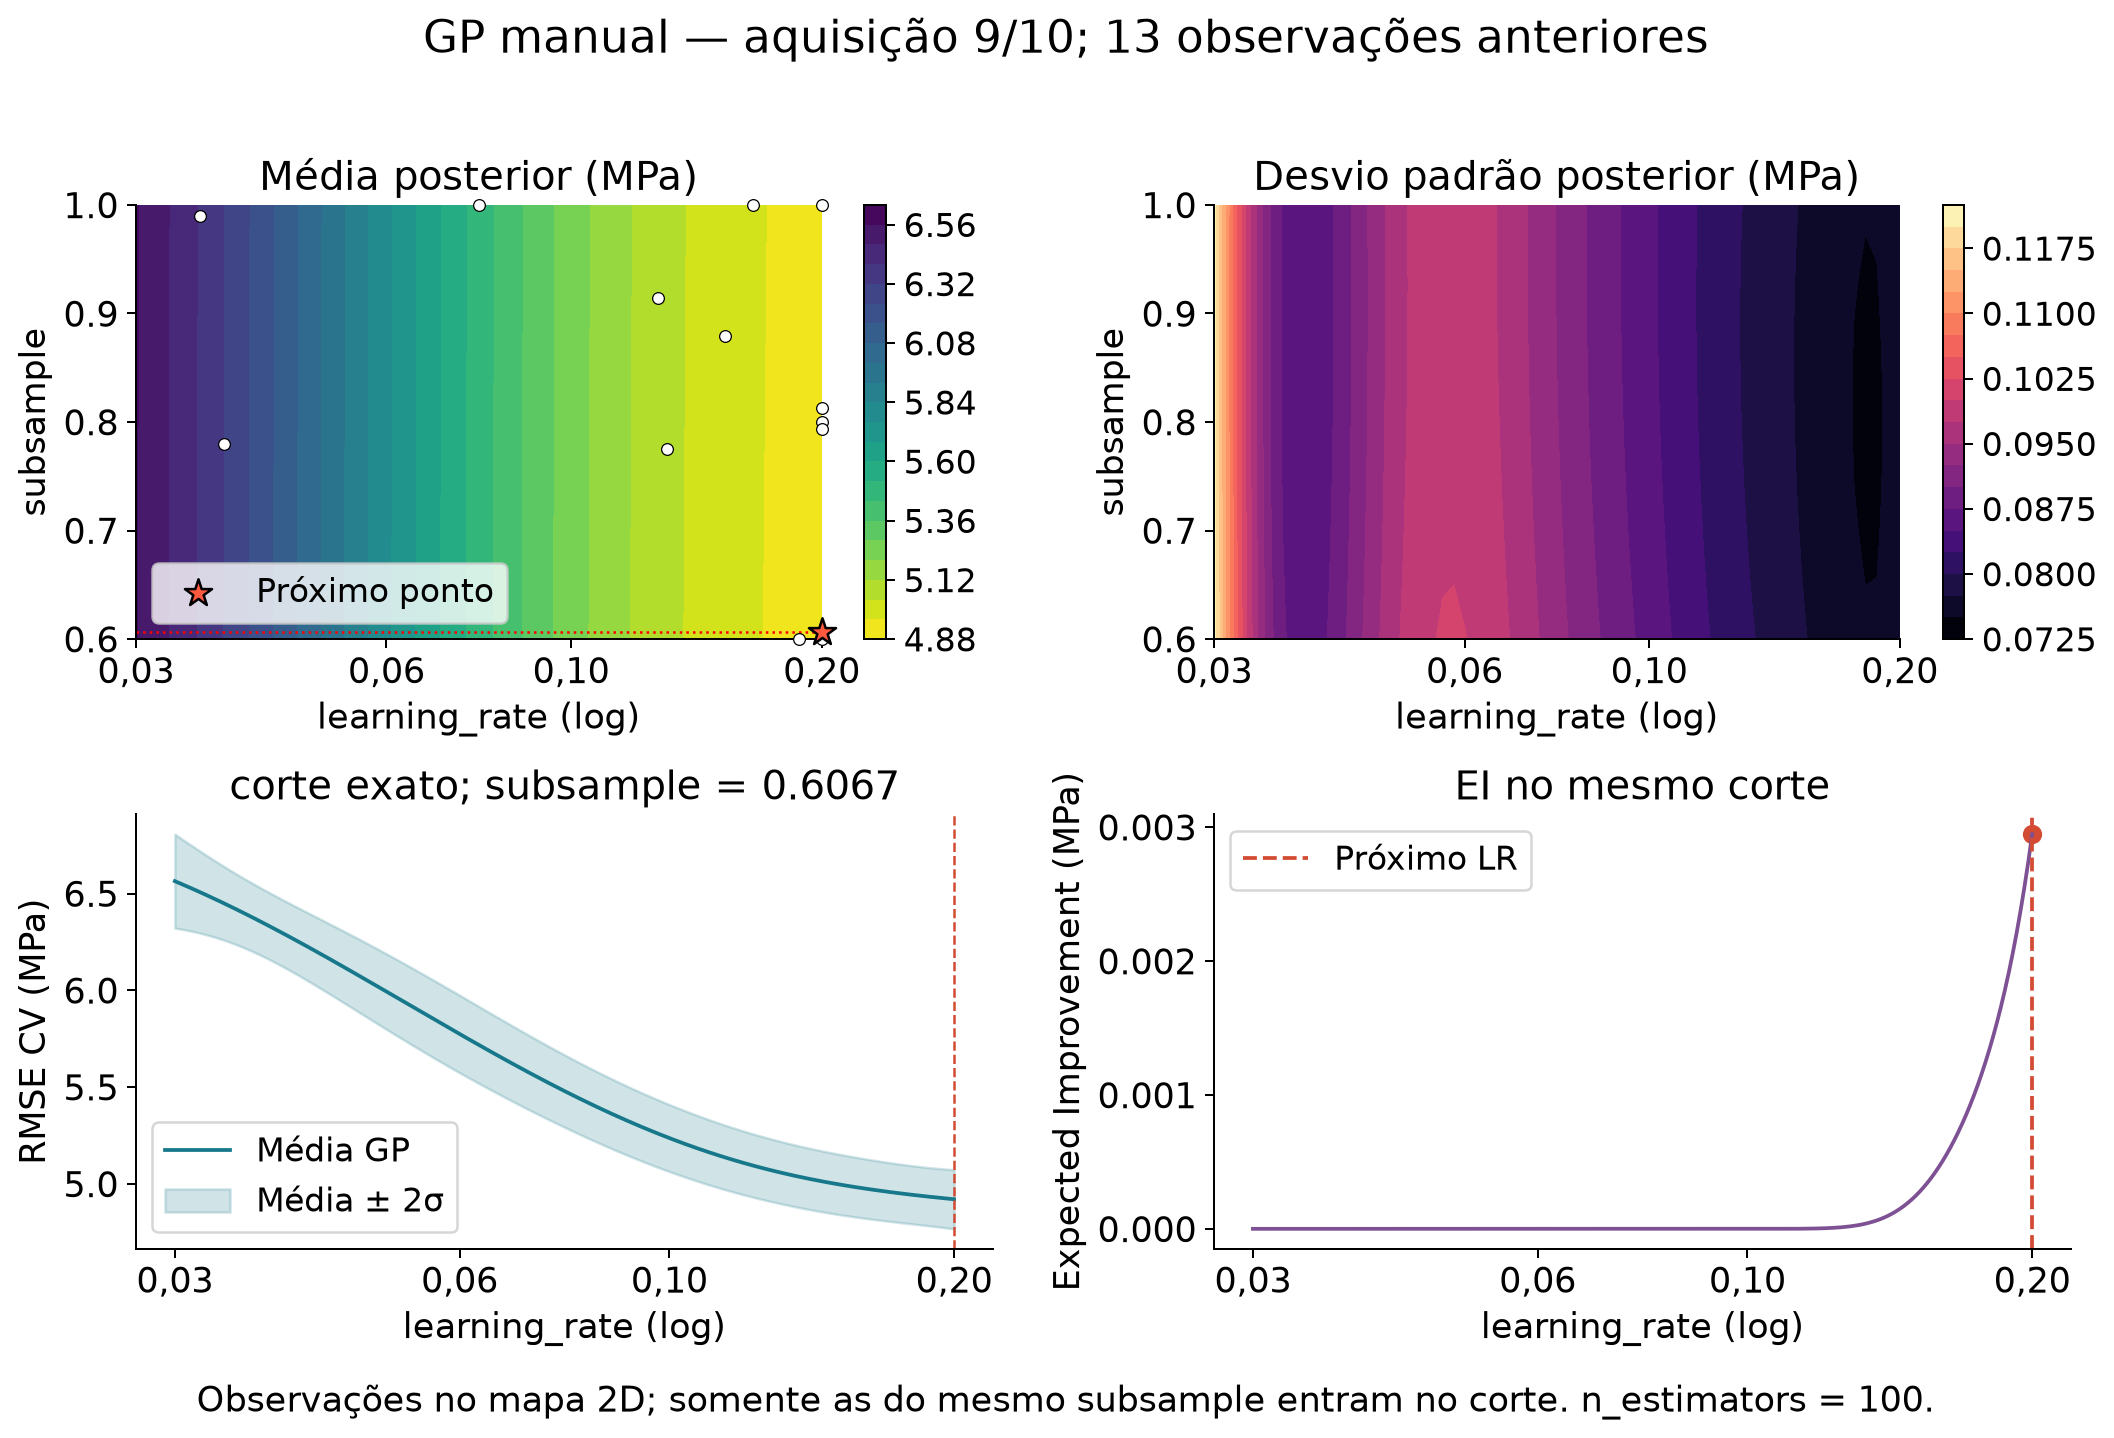

In [34]:
show_figure('gp_iteration_09')

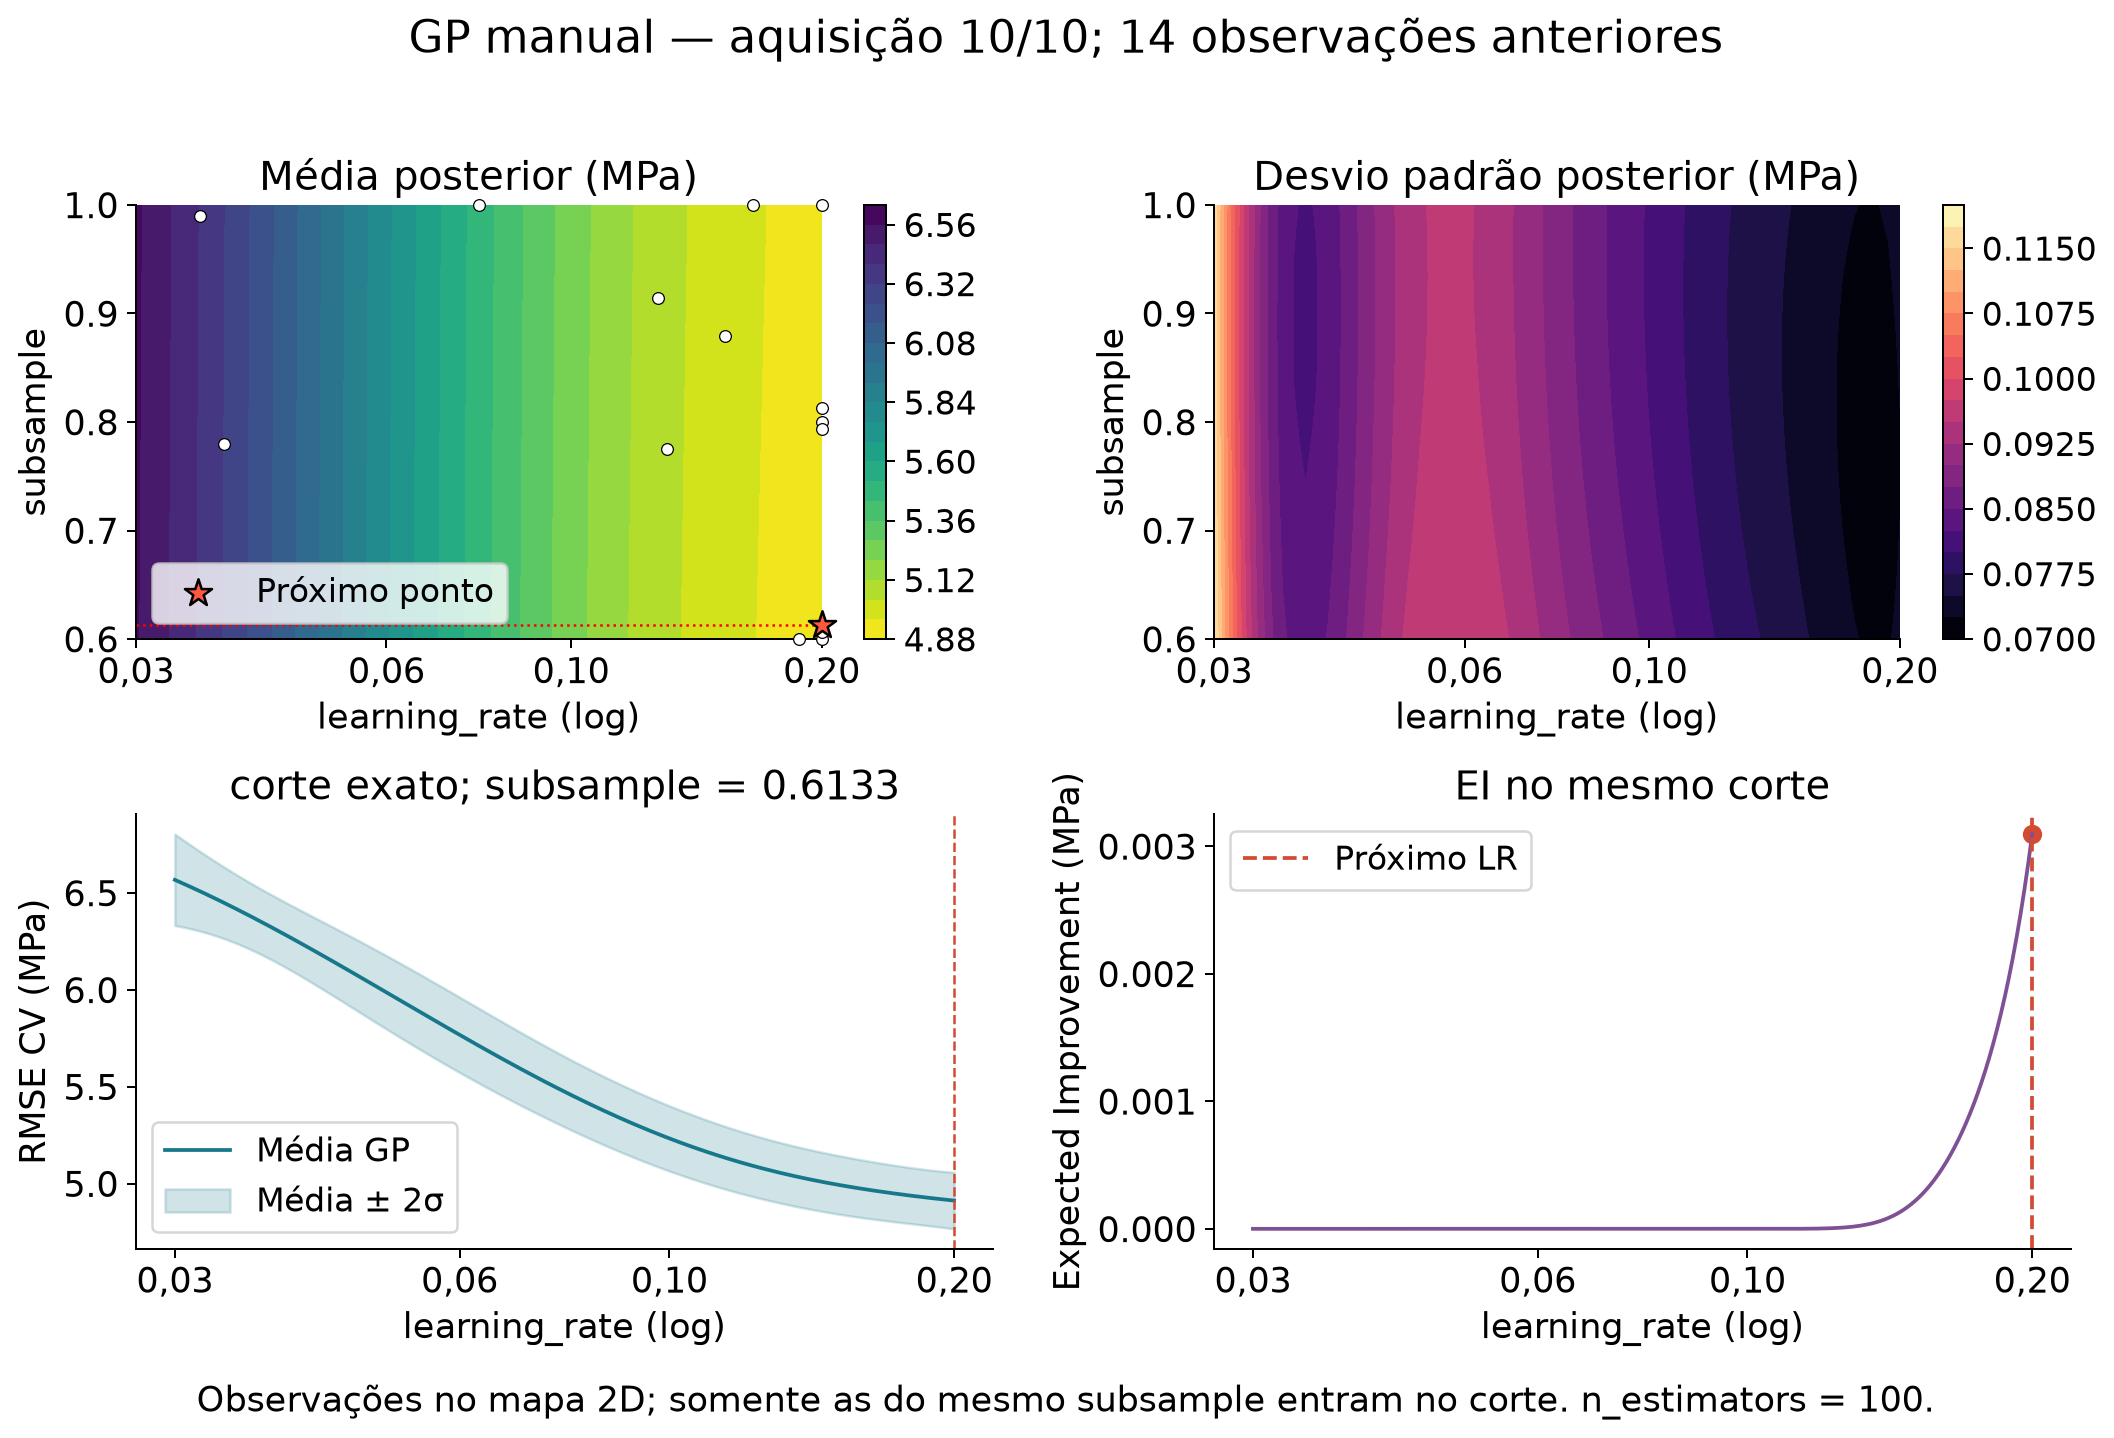

In [35]:
show_figure('gp_iteration_10')

In [36]:
display(pd.DataFrame(analysis['gp_iterations']))

,iteration,n_previous,mean_sigma,max_ei,previous_best_rmse,next_learning_rate,next_subsample
0,1,5,0.135686,0.198384,4.928827,0.200000,1.000000
1,2,6,0.156300,0.072546,4.928827,0.077460,1.000000
2,3,7,0.072865,0.026502,4.928827,0.187744,0.600000
3,4,8,0.047282,0.012087,4.928827,0.165439,1.000000
4,5,9,0.059069,0.134835,4.928827,0.200000,0.813333
5,6,10,0.062858,0.010354,4.860811,0.200000,0.800000
6,7,11,0.060684,0.002690,4.825428,0.200000,0.793333
7,8,12,0.093600,0.003624,4.825428,0.200000,0.600000
8,9,13,0.088783,0.002948,4.825428,0.200000,0.606667
9,10,14,0.085568,0.003096,4.825428,0.200000,0.613333


In [37]:
display(Markdown(analysis['narrative']['gp']))

A incerteza média posterior na malha passou de 0.1357 para 0.0856 MPa entre os posteriors anterior à primeira e à décima aquisição. A mudança pode não ser monotônica, pois o kernel é reajustado. O melhor RMSE já observado nesses instantes passou de 4.9288 a 4.8254 MPa. EI combina redução esperada do erro e incerteza; a maximização é aproximada na malha de 61 × 61 pontos, com xi = 0,01 MPa fixo. Não há garantia de ótimo global em 15 avaliações; o corte com 201 pontos apenas visualiza o posterior.

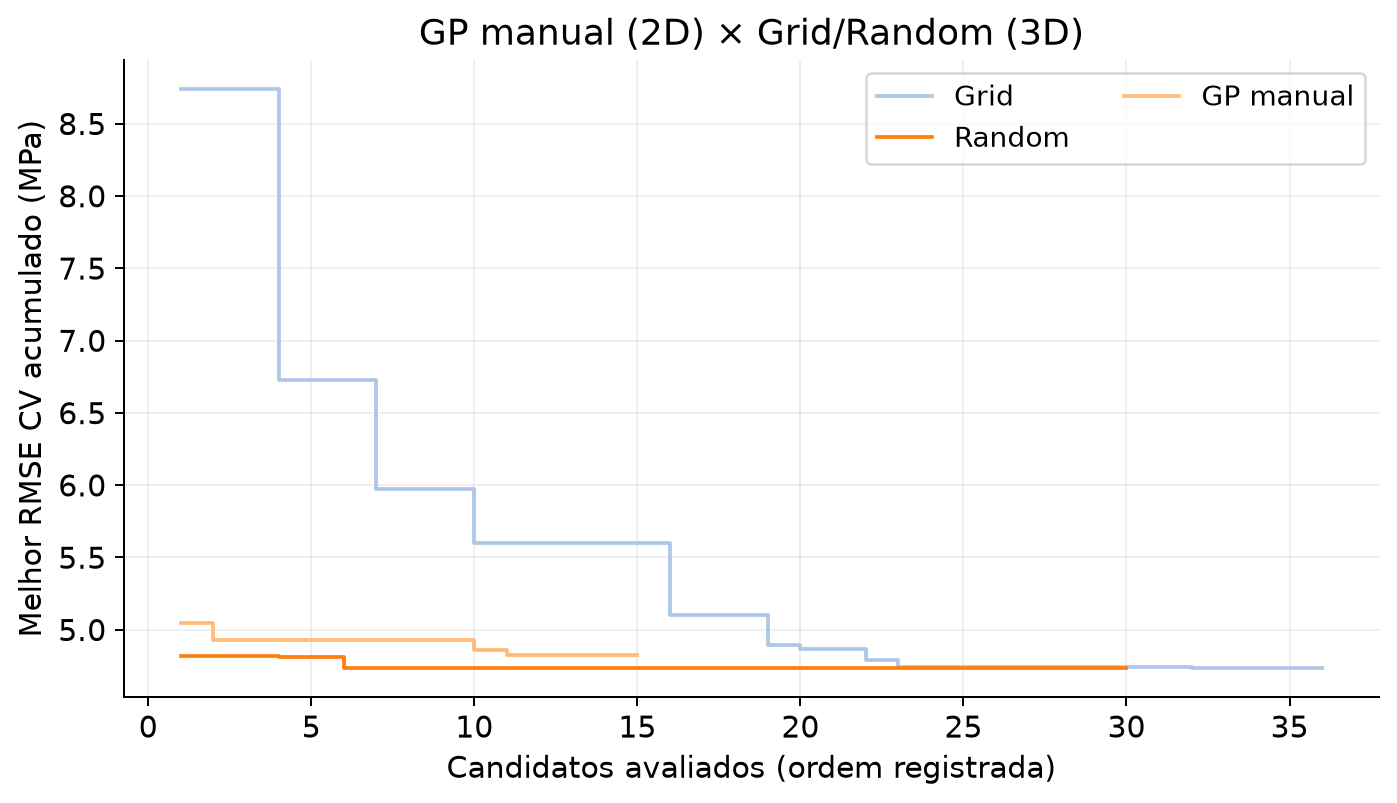

In [38]:
show_figure('07_gp_comparison')

In [39]:
display(metrics[metrics.method.isin(['grid','random','gp_manual'])][['method','cv_rmse','test_rmse','total_seconds','n_evaluations']])

,method,cv_rmse,test_rmse,total_seconds,n_evaluations
1,grid,4.732687,4.463024,4.134465,36
2,random,4.732687,4.463024,3.412393,30
3,gp_manual,4.825428,4.676302,2.079870,15


A comparação de contagem deve considerar que GP manual explora um subespaço 2D com 15 avaliações, enquanto Grid/Random variam também n_estimators. Maior eficiência aparente não isola o efeito da aquisição.

### 7. Cinco bibliotecas de otimização Bayesiana

skopt: GP Matérn 5/2 + EI; bayes_opt: GP + UCB κ=2,576; Optuna: TPESampler; Hyperopt: tpe.suggest, LR loguniform; Ray: OptunaSearch + ASHAScheduler. Todos iniciam 40 candidatos. Ray informa métricas nos recursos crescentes 0,25; 0,50; 0,75; 1,00, frações do número de árvores de cada candidato. Árvores são incrementadas por warm_start. Somente candidatos que completam o recurso 1,00 competem como melhor configuração.

In [40]:
display(metrics[metrics.method.isin(['bayessearch','bayesopt','optuna','hyperopt','ray'])][['method','cv_rmse','test_rmse','test_mae','test_r2','search_seconds','refit_seconds','total_seconds','n_evaluations','completed_trials','pruned_trials','cv_fits','trained_trees_cv']])

,method,cv_rmse,test_rmse,test_mae,test_r2,search_seconds,refit_seconds,total_seconds,n_evaluations,completed_trials,pruned_trials,cv_fits,trained_trees_cv
4,bayessearch,4.643562,4.534620,2.985655,0.931073,13.557948,0.169872,13.727820,40,40,0,200,34255
5,bayesopt,4.647569,4.443879,3.081869,0.933804,10.946559,0.186603,11.133162,40,40,0,200,34655
6,optuna,4.643520,4.432828,3.112791,0.934132,6.759466,0.146777,6.906242,40,40,0,200,31310
7,hyperopt,4.725345,4.829897,3.420215,0.921804,5.429428,0.121785,5.551213,40,40,0,200,26275
8,ray,4.609612,4.642808,3.112364,0.927744,160.008276,0.188697,160.196974,40,24,16,585,24935


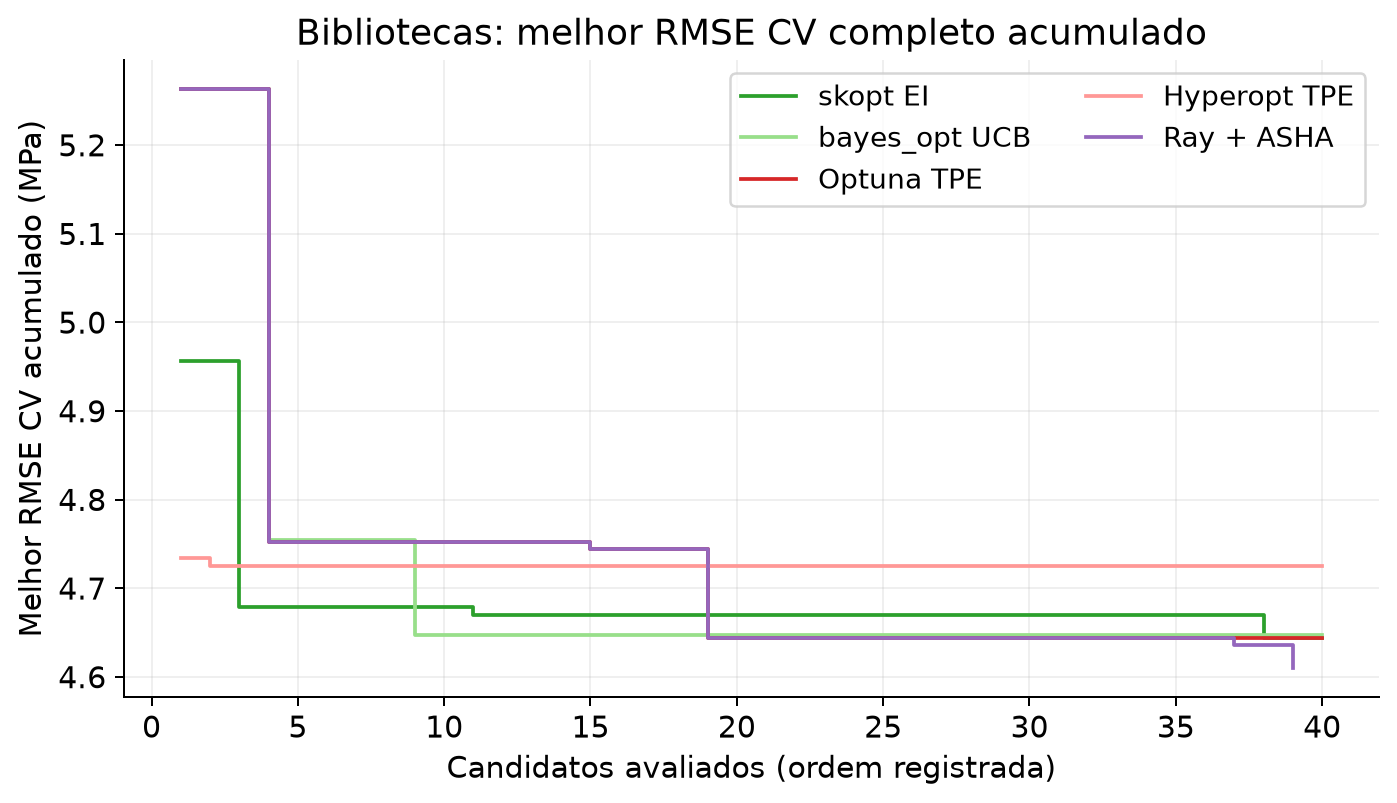

In [41]:
show_figure('08_bayesian_convergence')

A curva Ray mostra o melhor RMSE das avaliações completas; trials podados não são comparáveis ao score final. Contagens de fits e árvores expõem o trabalho parcial.

### 8. Metaheurísticas

GA: 20 indivíduos, 15 gerações, crossover = 0,7 e mutação = 0,25; genes inteiros quantizam LR log e subsample em 1001 níveis e n_estimators em 151 níveis. Diversidade = genótipos distintos / população. DE: best1bin e rand1bin, maxiter = 15, popsize = 10 (30 indivíduos em 3D), mutation = (0,5; 1), recombination = 0,7, polish = False. PSO: 20 partículas, inicialização + 15 atualizações; c1 = c2 = 1,5; três inércias. As estratégias DE compartilham a população inicial; as variantes PSO compartilham posições e velocidades iniciais (seed 42). Nesses pares, altera-se apenas a estratégia ou inércia. Somente os métodos vencedores tiveram o procedimento repetido com cinco seeds.

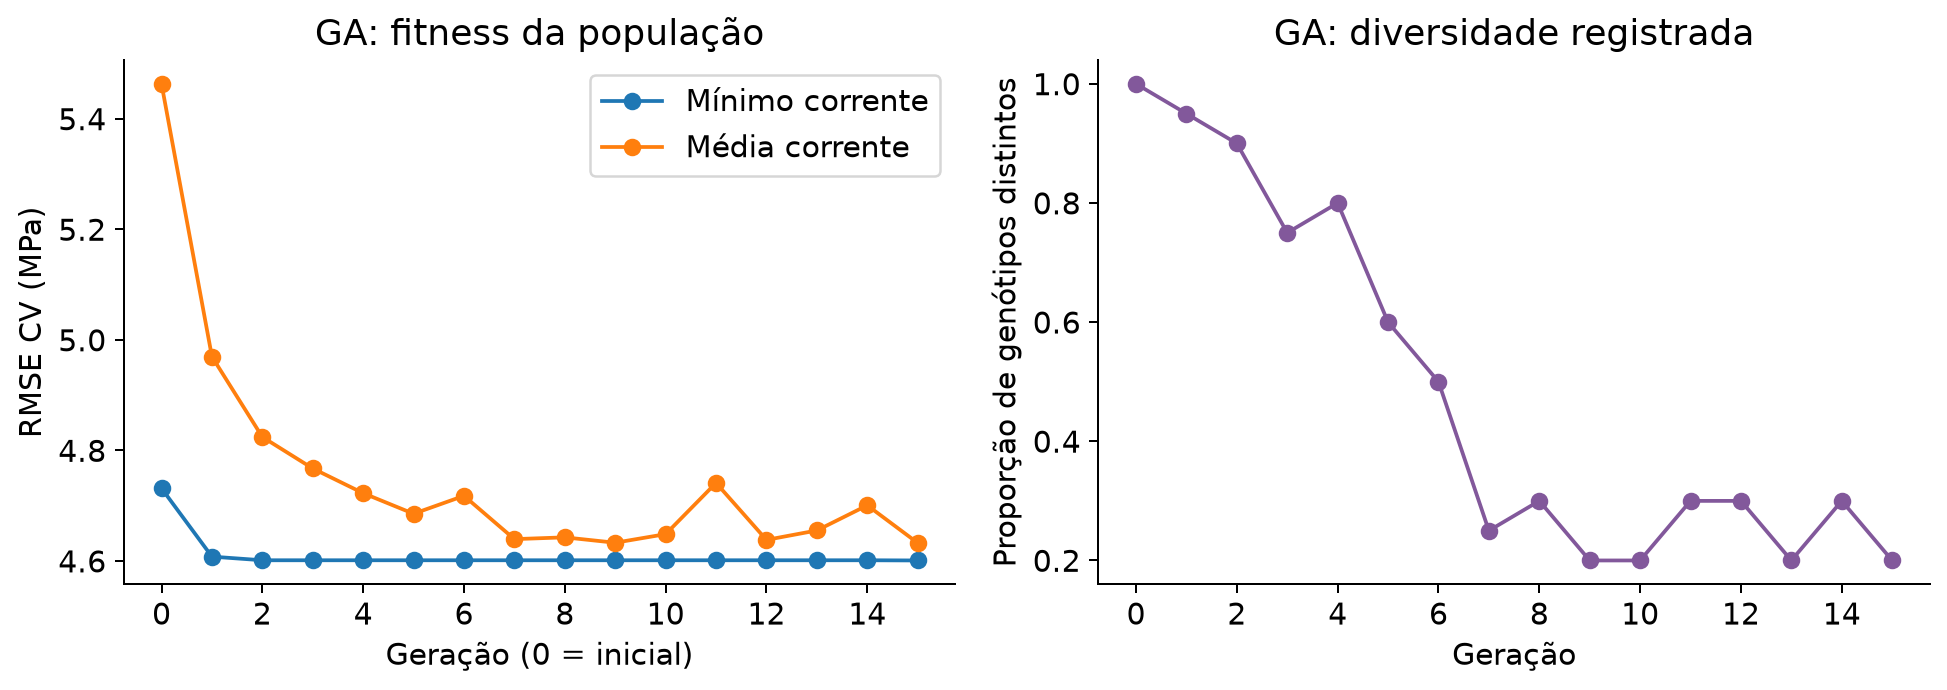

In [42]:
show_figure('09_ga_generations')

In [43]:
display(Markdown(analysis['narrative']['ga']))

GA: diversidade registrada de 1.0000 para 0.2000, e melhor fitness corrente de 4.7316 para 4.6010 MPa. O maior intervalo sem nova melhoria acumulada foi de 12 gerações (da 3 à 14); a melhoria na última geração foi de apenas 0.000363 MPa. Contração de diversidade com estagnação sugere risco de convergência prematura, mas não prova um ótimo local nem demonstra distância ao ótimo global desconhecido.

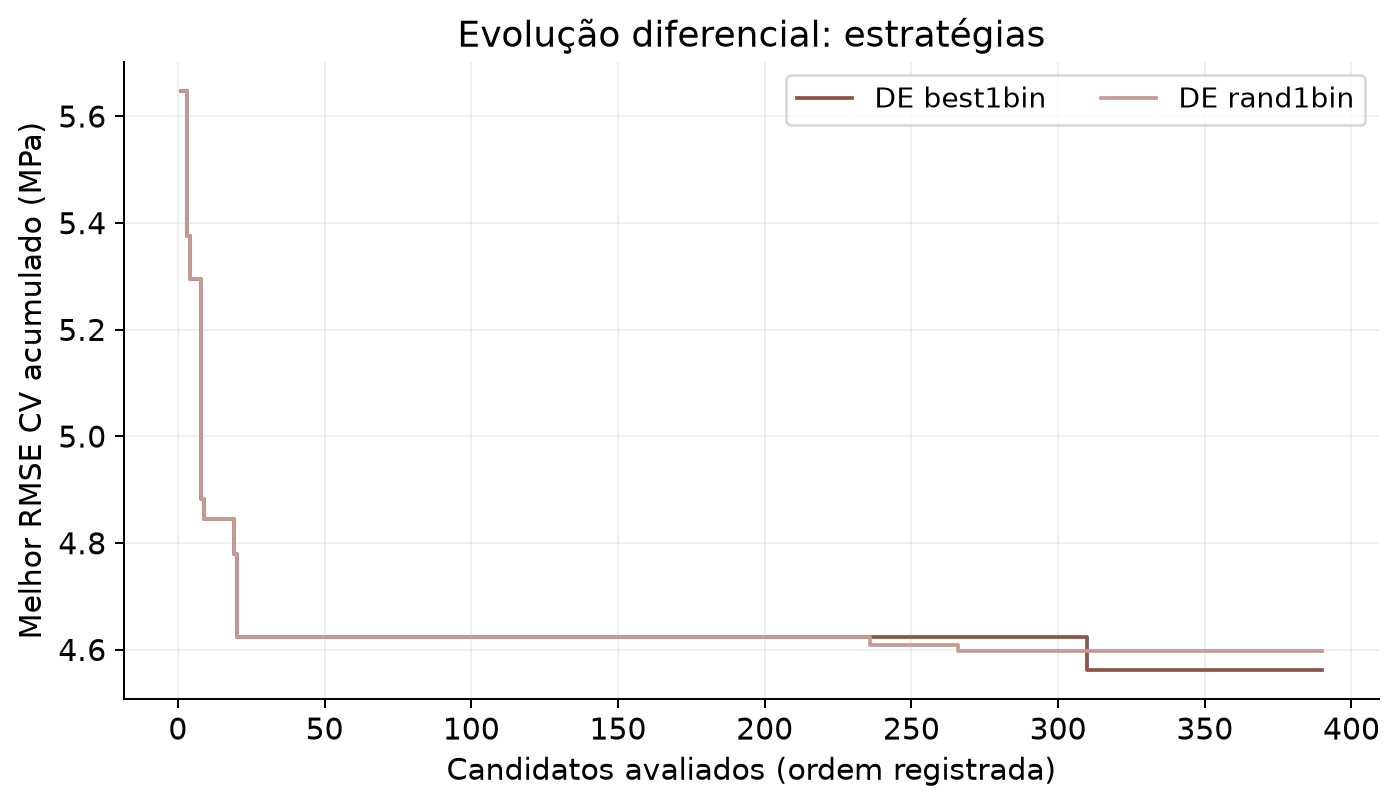

In [44]:
show_figure('10_de_convergence')

In [45]:
display(Markdown(analysis['narrative']['de']))

DE best1bin retornou RMSE CV 4.5612 MPa em 390 avaliações; rand1bin, 4.5981 MPa em 390. Tempos totais: 56.677 s e 52.258 s. A curva explicita diferenças de rapidez e patamares; o término segue a tolerância padrão do SciPy ou maxiter = 15. A estratégia best1bin é orientada pelo melhor indivíduo corrente; rand1bin preserva uma base aleatória. Uma execução por estratégia não demonstra superioridade universal.

In [46]:
display(metrics[metrics.method.isin(['de_best1bin','de_rand1bin'])][['method','cv_rmse','test_rmse','total_seconds','n_evaluations']])
for method in ['de_best1bin','de_rand1bin']:
    display(pd.Series(json.loads((ROOT/'results'/method/'seed_42'/'de-result.json').read_text())).to_frame(method))

,method,cv_rmse,test_rmse,total_seconds,n_evaluations
10,de_best1bin,4.561235,4.693300,56.677394,390
11,de_rand1bin,4.598111,4.413513,52.257580,390


,de_best1bin
x,"[0.9615437228811096, 0.8072616493262504, 0.773..."
fun,4.561235
nfev,390
nit,12
message,Optimization terminated successfully.
population_size,30
polish,False
tol,0.01
atol,0.0


,de_rand1bin
x,"[0.9436994107238554, 0.28290520464152047, 0.93..."
fun,4.598111
nfev,390
nit,12
message,Optimization terminated successfully.
population_size,30
polish,False
tol,0.01
atol,0.0


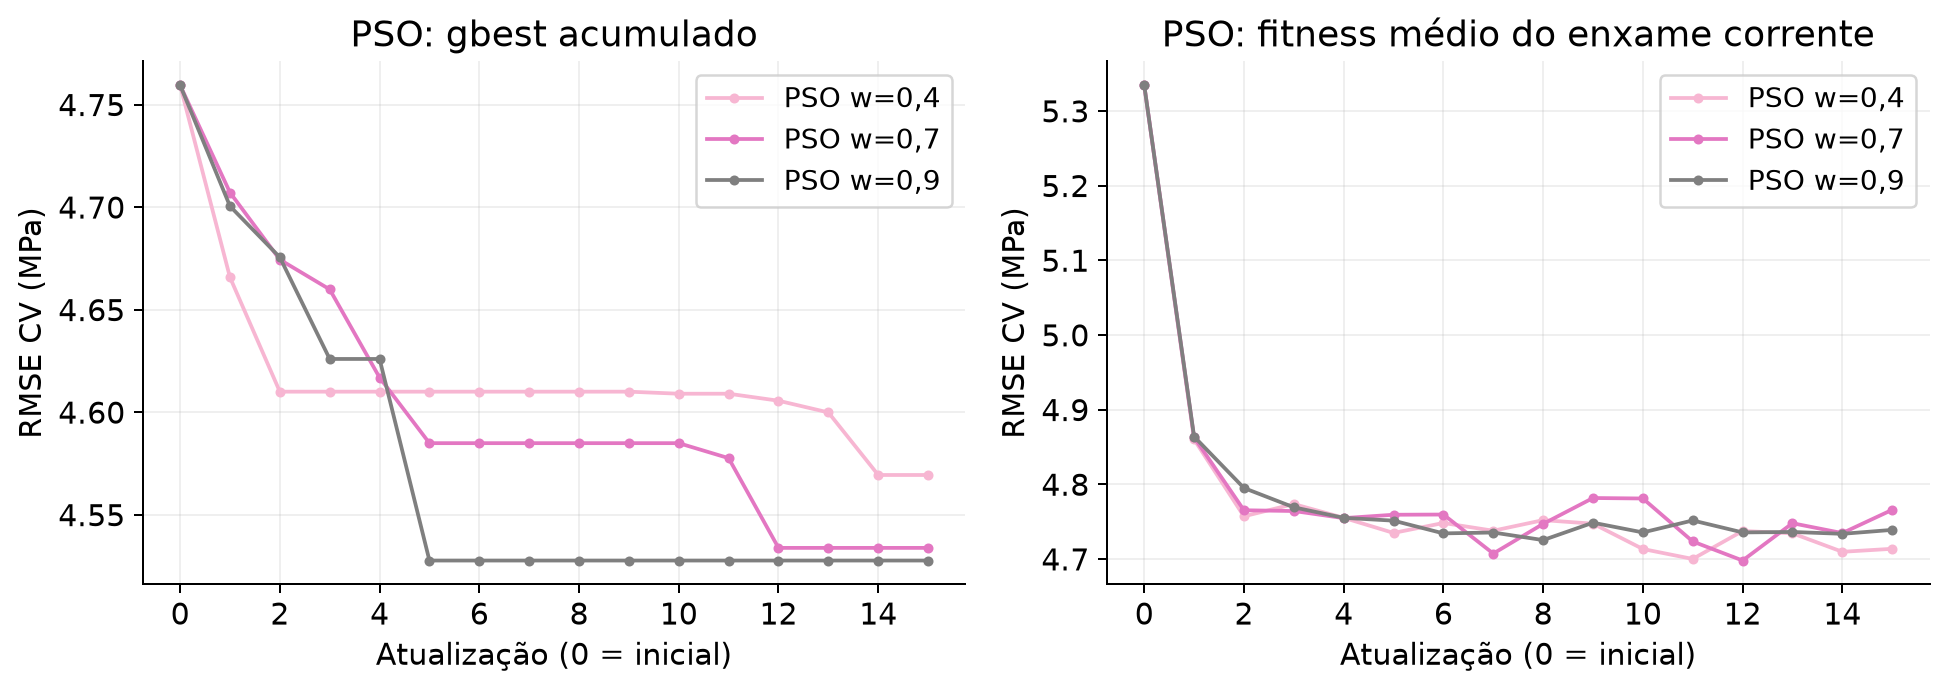

In [47]:
show_figure('11_pso_inertia')

In [48]:
display(Markdown(analysis['narrative']['pso']))

Melhor RMSE CV final por inércia: PSO w=0,4=4.5694 MPa, PSO w=0,7=4.5339 MPa, PSO w=0,9=4.5277 MPa. A média é calculada com fitness do enxame corrente. Uma seed por inércia não sustenta recomendação universal sobre w.

### 9. Dashboard e diagnóstico

Verde destaca os melhores valores de qualidade; amarelo, o menor tempo. Os 12 métodos principais e três variantes são identificados separadamente. O radar usa os 12 principais e min-max em cada eixo; erros são invertidos e 1/tempo favorece execução rápida. Todos os eixos apontam para maior=melhor. As escalas dependem dos métodos incluídos e não são notas absolutas.

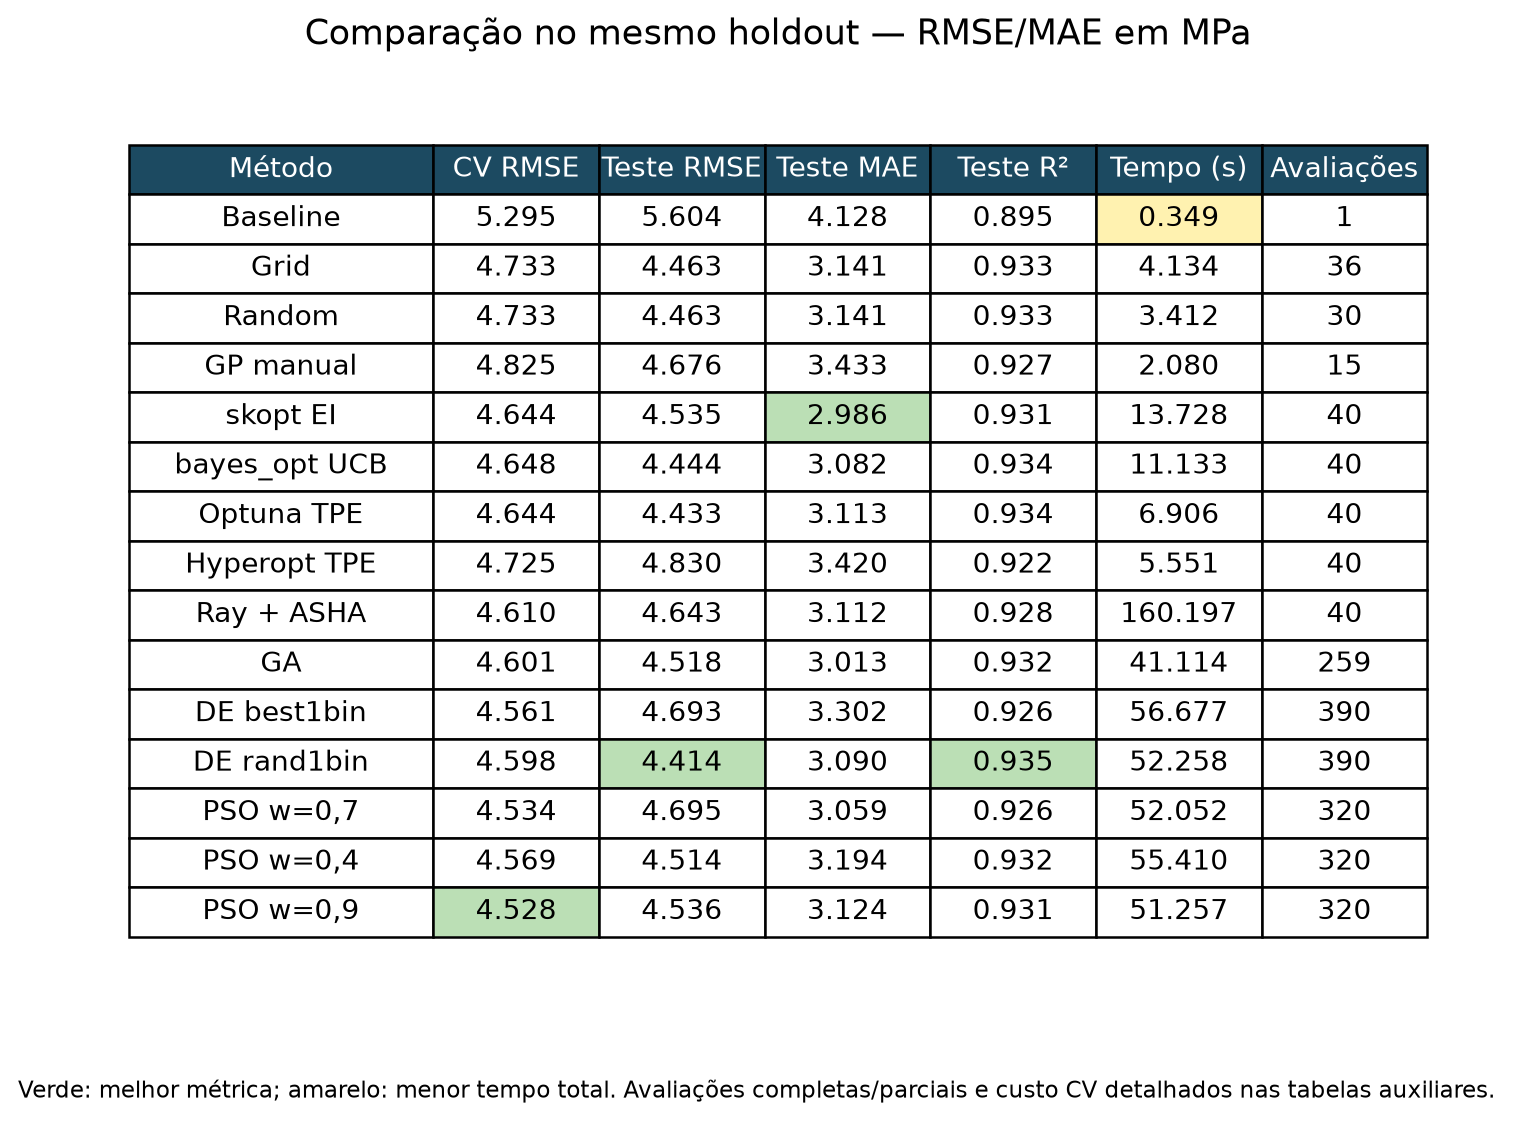

In [49]:
show_figure('12_comparison_table')

In [50]:
from html import escape
quality=['cv_rmse','test_rmse','test_mae','test_r2']
table=metrics[['method',*quality,'total_seconds','n_evaluations']]
html_rows=['<tr>'+''.join('<th>'+escape(c)+'</th>' for c in table.columns)+'</tr>']
for _, row in table.iterrows():
    cells=[]
    for c in table.columns:
        bg='white'
        if c in quality:
            best=table[c].max() if c=='test_r2' else table[c].min()
            if np.isclose(row[c],best,rtol=1e-10,atol=1e-12): bg='#bbdfb5'
        if c=='total_seconds' and np.isclose(row[c],table[c].min()): bg='#fff2b0'
        value=f'{row[c]:.4f}' if c in quality+['total_seconds'] else str(row[c])
        cells.append(f'<td style="background:{bg};padding:6px;border:1px solid #ccc">'+escape(value)+'</td>')
    html_rows.append('<tr>'+''.join(cells)+'</tr>')
display(HTML('<table style="border-collapse:collapse">'+''.join(html_rows)+'</table>'))
display(metrics[['method','search_seconds','refit_seconds','total_seconds','n_evaluations','unique_candidates','cv_fits','completed_trials','pruned_trials','trained_trees_cv']])

method,cv_rmse,test_rmse,test_mae,test_r2,total_seconds,n_evaluations
baseline,5.2954,5.6039,4.1284,0.8947,0.3493,1
grid,4.7327,4.4630,3.1411,0.9332,4.1345,36
random,4.7327,4.4630,3.1411,0.9332,3.4124,30
gp_manual,4.8254,4.6763,3.4329,0.9267,2.0799,15
bayessearch,4.6436,4.5346,2.9857,0.9311,13.7278,40
bayesopt,4.6476,4.4439,3.0819,0.9338,11.1332,40
optuna,4.6435,4.4328,3.1128,0.9341,6.9062,40
hyperopt,4.7253,4.8299,3.4202,0.9218,5.5512,40
ray,4.6096,4.6428,3.1124,0.9277,160.1970,40
ga,4.6010,4.5181,3.0133,0.9316,41.1145,259


,method,search_seconds,refit_seconds,total_seconds,n_evaluations,unique_candidates,cv_fits,completed_trials,pruned_trials,trained_trees_cv
0,baseline,0.253275,0.096001,0.349276,1,1,5,1,0,500
1,grid,3.991489,0.142975,4.134465,36,36,180,36,0,22500
2,random,3.288482,0.123911,3.412393,30,30,150,30,0,19250
3,gp_manual,1.990088,0.089782,2.079870,15,15,75,15,0,7500
4,bayessearch,13.557948,0.169872,13.727820,40,40,200,40,0,34255
5,bayesopt,10.946559,0.186603,11.133162,40,40,200,40,0,34655
6,optuna,6.759466,0.146777,6.906242,40,40,200,40,0,31310
7,hyperopt,5.429428,0.121785,5.551213,40,40,200,40,0,26275
8,ray,160.008276,0.188697,160.196974,40,40,585,24,16,24935
9,ga,40.953029,0.161428,41.114457,259,113,1295,259,0,229515


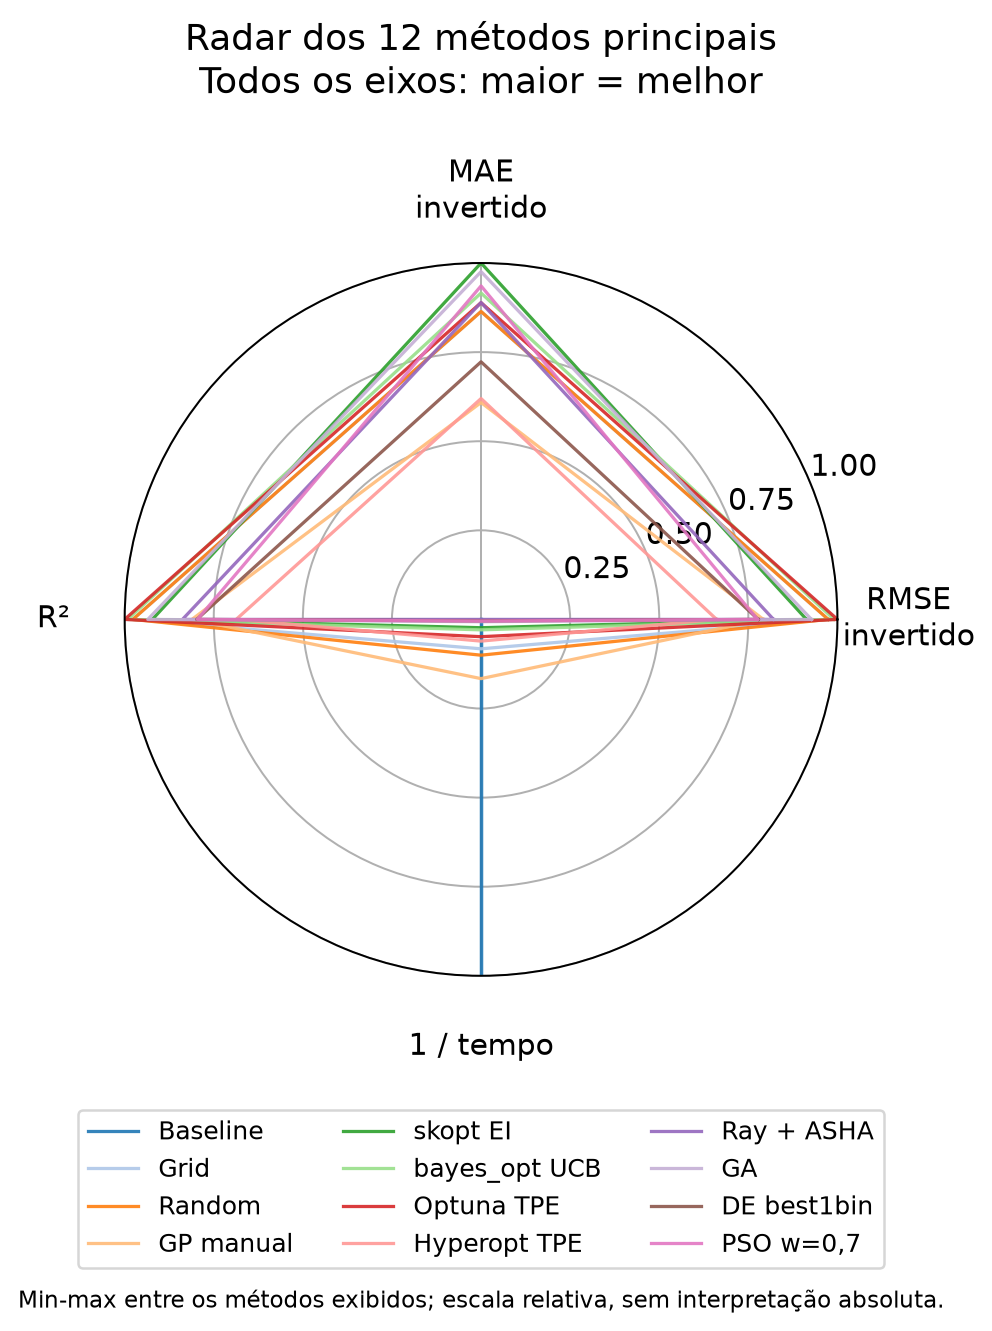

In [51]:
show_figure('13_radar')

In [52]:
display(Markdown(analysis['narrative']['radar']))

No conjunto exibido, os líderes de qualidade são Optuna TPE em RMSE, skopt EI em MAE e Optuna TPE em R². O menor tempo total é de Baseline. O radar orienta as quatro escalas para maior=melhor; as normalizações são dependentes dos métodos incluídos, e polígonos próximos não estabelecem equivalência estatística.

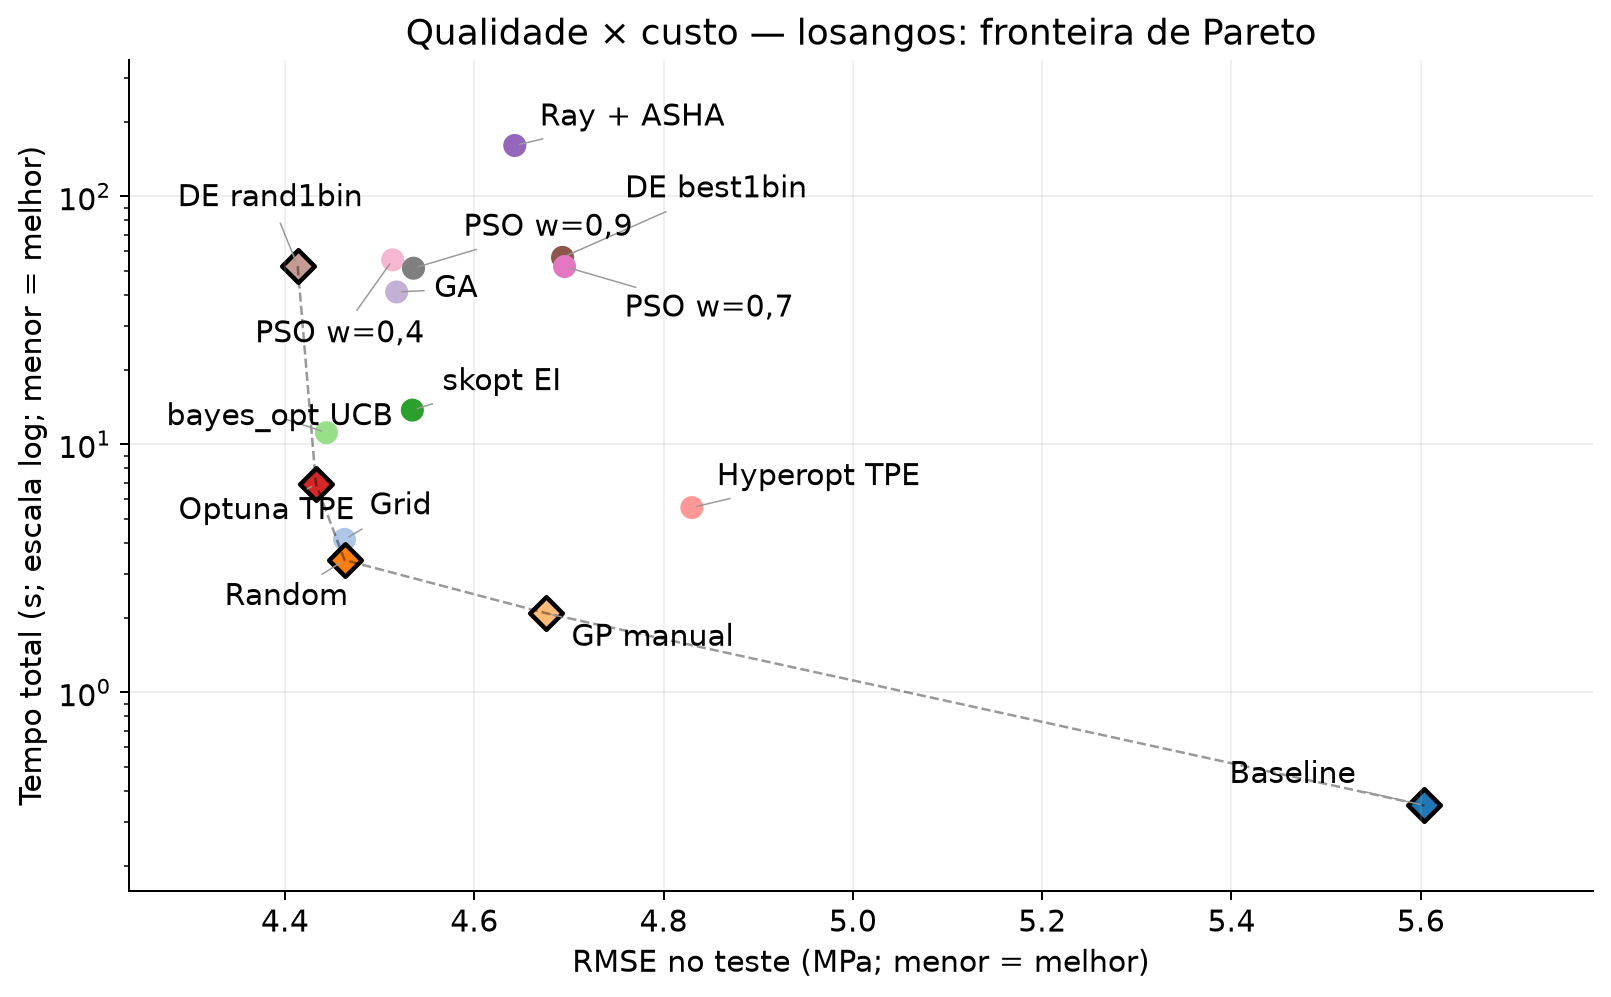

In [53]:
show_figure('14_pareto')

In [54]:
display(Markdown('**Fronteira de Pareto (RMSE teste e tempo):** '+', '.join(analysis['method_labels'][m] for m in analysis['pareto_methods'])+'. Empates são preservados; dominar exige melhora estrita em pelo menos um objetivo.'))

**Fronteira de Pareto (RMSE teste e tempo):** Baseline, Random, GP manual, Optuna TPE, DE rand1bin. Empates são preservados; dominar exige melhora estrita em pelo menos um objetivo.

In [55]:
display(Markdown(analysis['narrative']['baseline_gain']))

O baseline apresentou RMSE de 5.6039 MPa. O menor RMSE de teste foi 4.4135 MPa (DE rand1bin), redução descritiva de 21.24%. O custo total foi 52.258 s contra 0.349 s; relevância industrial exige uma tolerância externa ao estudo.

In [56]:
display(Markdown(analysis['narrative']['scope']))

Comparação exploratória em um único holdout do UCI 165. A seleção por teste exigida pela atividade impede interpretar o vencedor como confirmação independente. Nenhum parâmetro foi retunado em função do teste.

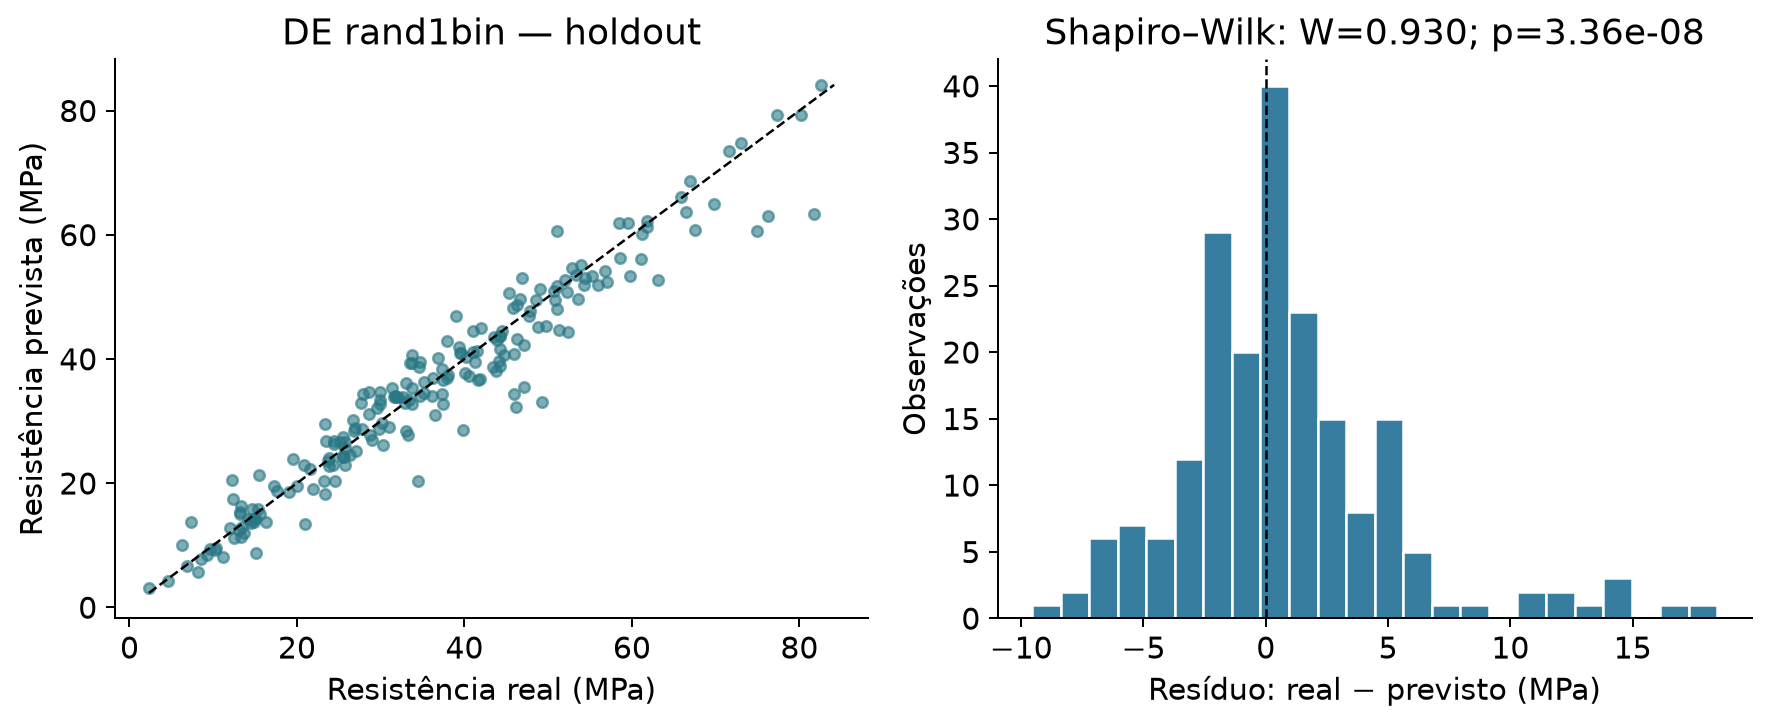

In [57]:
show_figure('15_best_predictions_residuals')

In [58]:
display(Markdown(analysis['narrative']['residuals']))

Shapiro–Wilk nos 201 resíduos de teste: W=0.9303, p=3.357e-08. Há evidência contra normalidade a 5%. O diagnóstico é exploratório e normalidade dos resíduos não é requisito para minimizar RMSE com GBR.

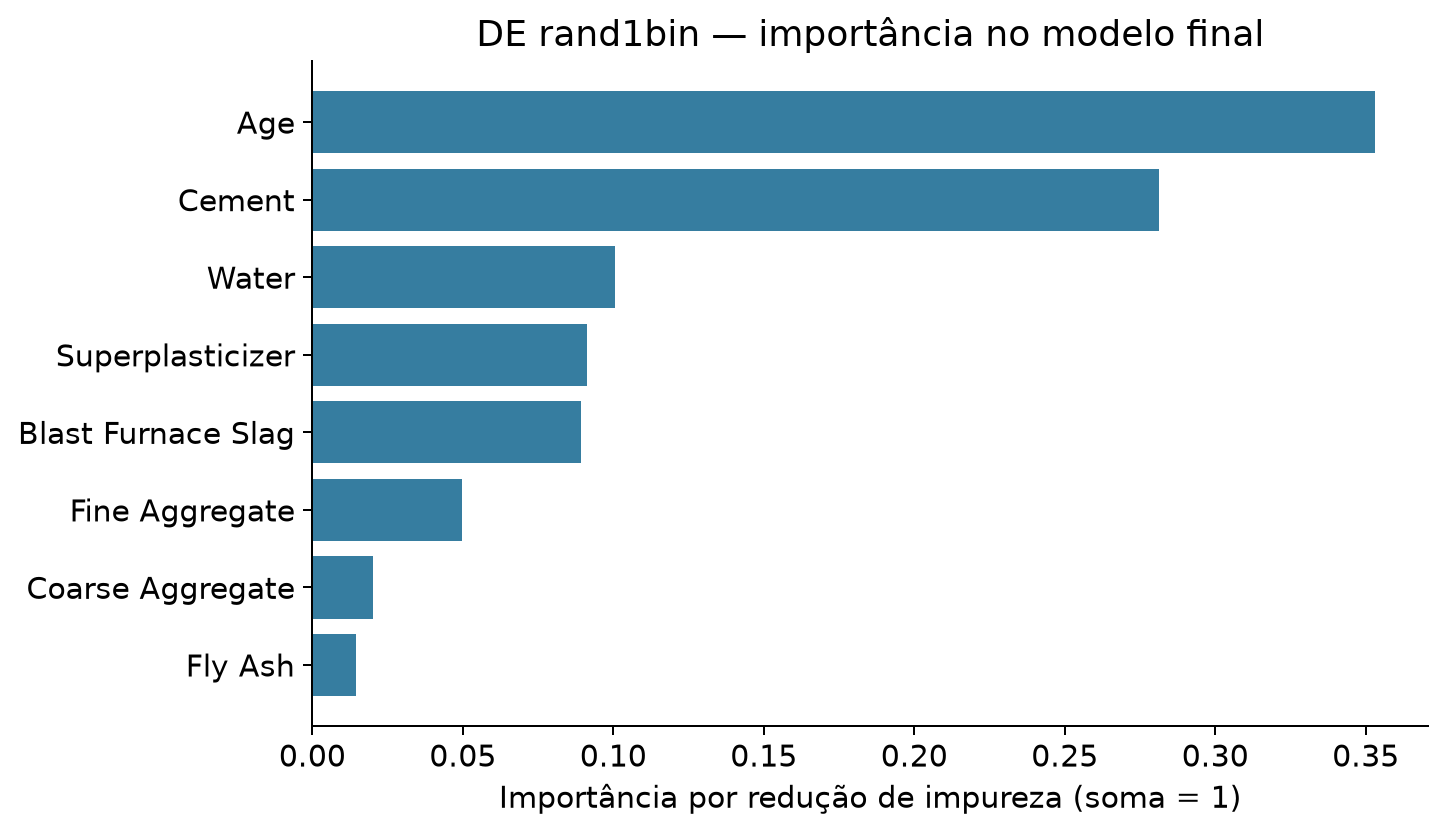

In [59]:
show_figure('16_feature_importance')

In [60]:
display(Markdown(analysis['narrative']['feature_importance']))

A importância das features por redução de impureza descreve o modelo ajustado; não mede causalidade. Preditores correlacionados podem redistribuir a importância.

### 10. Sensibilidade e recomendação

A importância Optuna é estimada a partir dos trials dessa busca, condicionada ao espaço e budget. A comparação amostral usa 50% do treino, mantendo o mesmo teste reservado. A análise principal usa todo o dataset elegível, não uma amostra escolhida após ver scores.

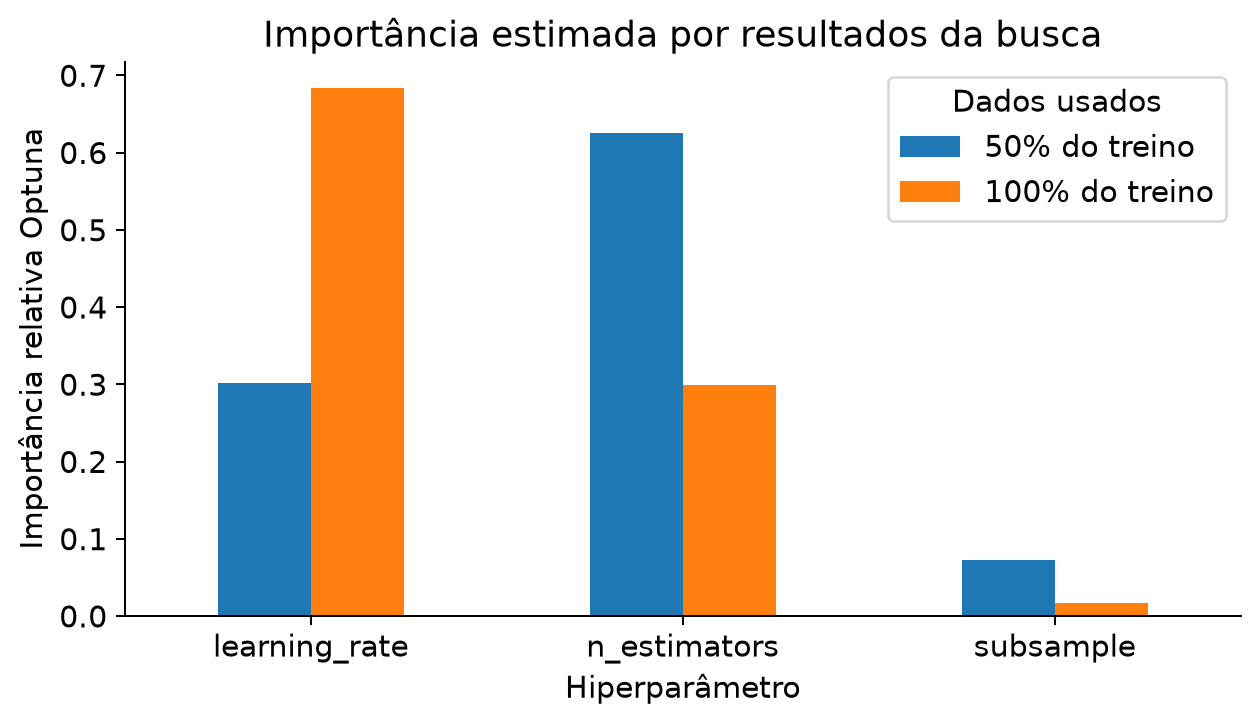

In [61]:
show_figure('18_optuna_importances')

In [62]:
display(pd.DataFrame(analysis['optuna_importances']))
display(pd.DataFrame(analysis.get('sample_comparison',[])))

,hyperparameter,importance,training_fraction
0,learning_rate,0.683601,1.0
1,n_estimators,0.299105,1.0
2,subsample,0.017293,1.0
3,n_estimators,0.625801,0.5
4,learning_rate,0.302061,0.5
5,subsample,0.072138,0.5


,status,method,seed,cv_rmse,test_rmse,test_mae,test_r2,search_seconds,refit_seconds,total_seconds,...,sample_fraction,data_fingerprint,framework_commit,code_sha256,shapiro_statistic,worker_startup_seconds_excluded,parallelism,shapiro_pvalue,timing_definition,test_interpretation
0,complete,optuna,42,4.643520,4.432828,3.112791,0.934132,6.759466,0.146777,6.906242,...,1.0,503672bc1db72cdcb457df56bc34d44e94a933cee18b7a...,f68892c8b7adba358b8aa437eec00a89fe88d340,f652fe5eab5e5cec8ea6b8c53e7de4b31fc3f14f453fd6...,0.935039,1.510326,5 loky processes for CV; Ray uses5 threads ins...,8.158144e-08,HPO/CV plus one development refit; excludes da...,Comparative educational evaluation; choosing w...
1,complete,optuna,42,5.073835,5.677444,4.131070,0.891952,4.538672,0.109642,4.648315,...,0.5,503672bc1db72cdcb457df56bc34d44e94a933cee18b7a...,f68892c8b7adba358b8aa437eec00a89fe88d340,4bd4e786823cd9b0637186f1a46f4651d3e092b341d831...,0.952245,1.410018,5 loky processes for CV; Ray uses5 threads ins...,2.964403e-06,HPO/CV plus one development refit; excludes da...,Comparative educational evaluation; choosing w...


In [63]:
display(Markdown(analysis['narrative']['optuna_importance']))

Hiperparâmetro mais importante em cada busca: 50% do treino: n_estimators (importância=0.626); 100% do treino: learning_rate (importância=0.684). O hiperparâmetro líder mudou entre as duas amostras. As importâncias são relativas às 40 avaliações e à distribuição dos candidatos, não uma propriedade universal da feature ou do otimizador. Mudar a amostra também altera o caminho adaptativo da busca; eventuais diferenças não isolam apenas o efeito do tamanho.

#### Robustez do procedimento completo

O vencedor descritivo no teste é repetido com seeds 0,7,21,42,99. Se o vencedor por CV for outro método, sua repetição é reportada separadamente. São refeitas as buscas inteiras: não apenas refits da mesma configuração. A seed42 principal é reutilizada explicitamente. Holdout e folds permanecem fixos; variam seed do otimizador e do estimador.

In [64]:
show_csv('results/robustness.csv')
show_csv('results/robustness-summary.csv')

,method,seed,cv_rmse,test_rmse,test_mae,test_r2,search_seconds,refit_seconds,total_seconds,n_evaluations
0,pso_w09,0,4.554781,4.660334,3.163333,0.927198,43.639466,0.139710,43.779176,320
1,pso_w09,7,4.566133,4.538827,3.077183,0.930945,48.154863,0.134202,48.289065,320
2,pso_w09,21,4.595495,4.426286,3.128923,0.934327,49.704557,0.156459,49.861017,320
3,pso_w09,42,4.527704,4.535849,3.124062,0.931035,51.111762,0.145320,51.257082,320
4,pso_w09,99,4.564339,4.482635,3.124409,0.932644,50.829113,0.152131,50.981244,320
5,de_rand1bin,0,4.641292,4.556862,3.162048,0.930395,40.644465,0.138919,40.783384,300
6,de_rand1bin,7,4.653233,4.690940,3.254724,0.926238,33.454426,0.165084,33.619509,240
7,de_rand1bin,21,4.650787,4.578278,3.186797,0.929739,32.996730,0.123227,33.119957,240
8,de_rand1bin,42,4.598111,4.413513,3.089907,0.934705,52.104620,0.152960,52.257580,390
9,de_rand1bin,99,4.652422,4.455501,3.163084,0.933457,31.355565,0.170371,31.525936,240


,method,mean,std,min,max,count
0,de_rand1bin,4.539019,0.109164,4.413513,4.690940,5
1,pso_w09,4.528786,0.086735,4.426286,4.660334,5


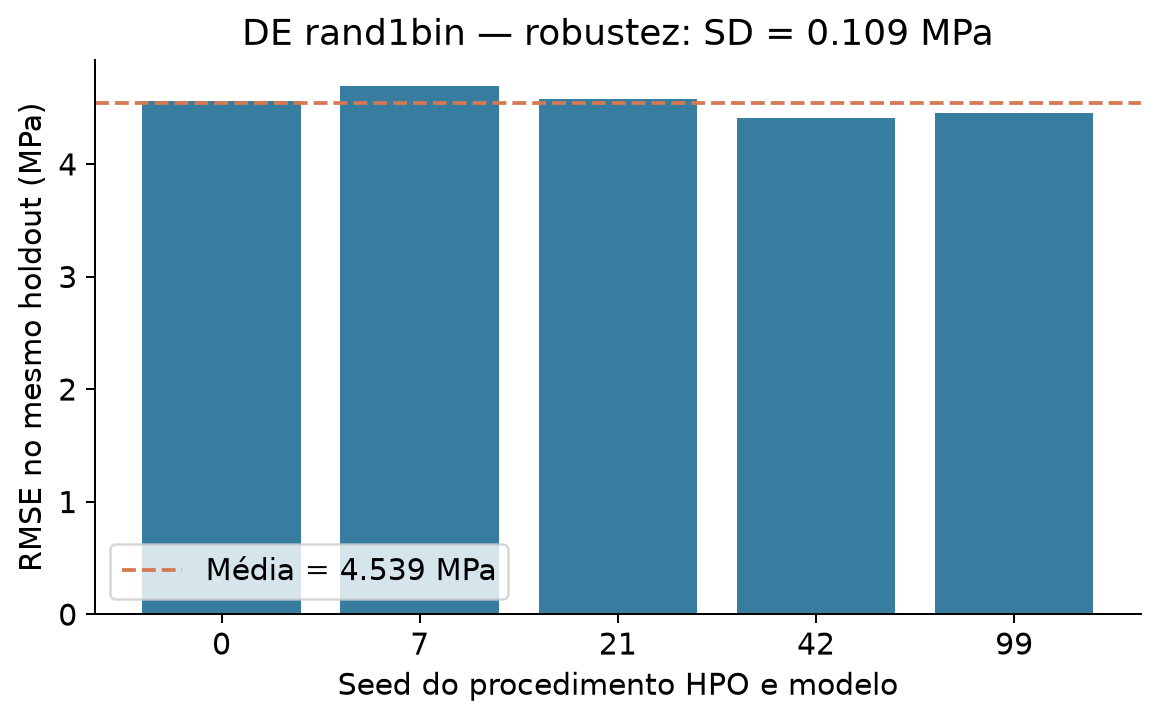

In [65]:
show_figure('17_robustness')

In [66]:
display(Markdown(analysis['narrative']['robustness']))

Executar novamente o procedimento HPO completo com cinco seeds, mantendo holdout e folds, resultou em RMSE médio 4.5390 MPa e desvio padrão amostral 0.1092 MPa (mínimo 4.4135, máximo 4.6909). O desvio corresponde a 2.41% da média: a variação é pequena em relação ao nível do erro, mas o desempenho exato depende da seed. Isso descreve estabilidade computacional no dataset fixo; sem tolerância industrial definida e validação externa, não estabelece estabilidade operacional ou populacional.

In [67]:
display(Markdown(analysis['narrative']['uncertainty']))

Os cinco folds orientam a seleção e não são cinco datasets independentes. As cinco seeds medem sensibilidade computacional no mesmo holdout, não incerteza completa de generalização. Não se conclui superioridade estatística universal.

#### Eficiência computacional

$$E_m=\frac{(RMSE_b-RMSE_m)/RMSE_b}{t_m-t_b}.$$

Usamos segundos totais de busca+refit. Para baseline ou diferença de tempo não positiva, a razão é indefinida e é mostrada como ausente; não dividimos por zero nem introduzimos epsilon.

In [68]:
display(pd.DataFrame(analysis['efficiency']))
print('Maior razão definida:', analysis['method_labels'][analysis['best_efficiency_method']])

,method,relative_rmse_improvement,additional_seconds,efficiency_per_second,status
0,baseline,0.000000,0.000000,NaN,undefined_nonpositive_delta_time
1,grid,0.203579,3.785189,0.053783,defined
2,random,0.203579,3.063118,0.066461,defined
3,gp_manual,0.165520,1.730595,0.095643,defined
4,bayessearch,0.190803,13.378544,0.014262,defined
5,bayesopt,0.206995,10.783887,0.019195,defined
6,optuna,0.208967,6.556967,0.031870,defined
7,hyperopt,0.138111,5.201937,0.026550,defined
8,ray,0.171497,159.847698,0.001073,defined
9,ga,0.193756,40.765182,0.004753,defined


Maior razão definida: GP manual


#### Recomendação justificada (até dez linhas)

In [69]:
display(Markdown(analysis['narrative']['recommendation']))

Adotaria Optuna TPE como candidato operacional provisório pelo compromisso entre CV, custo e integração: CV RMSE 4.6435 MPa em 6.906 s, com 40 trials e o mesmo pipeline. A seleção formal pelo menor CV continua sendo PSO w=0,9 (4.5277 MPa; 51.257 s). Random Search é a alternativa mais simples para orçamento menor. Fixaria versões, seeds, split e budget e validaria em novos lotes antes de produção. Essa recomendação é uma interpretação pós-resultados; as métricas de teste são descritivas, e não o critério principal da escolha operacional.

## Parâmetros escolhidos, defaults, ambiente e rastreabilidade

In [70]:
for row in metrics.to_dict('records'):
    display(Markdown('**'+analysis['method_labels'].get(row['method'],row['method'])+'**'))
    display(pd.Series(json.loads(row['params_json']),name='Valor').to_frame())

**Baseline**

,Valor
learning_rate,0.1
n_estimators,100.0
subsample,1.0


**Grid**

,Valor
learning_rate,0.2
n_estimators,150.0
subsample,0.8


**Random**

...

,Valor
learning_rate,0.20000
n_estimators,198.00000
subsample,0.68124


**PSO w=0,4**

,Valor
learning_rate,0.193127
n_estimators,185.000000
subsample,0.909809


**PSO w=0,9**

,Valor
learning_rate,0.168098
n_estimators,200.000000
subsample,0.622404


In [71]:
from sklearn.ensemble import GradientBoostingRegressor
display(pd.Series(GradientBoostingRegressor(random_state=42).get_params(),name='Defaults GBR').to_frame())
display(pd.Series(method_result('baseline')['environment'],name='Ambiente').to_frame())

,Defaults GBR
alpha,0.9
ccp_alpha,0.0
criterion,deprecated
init,None
learning_rate,0.1
loss,squared_error
max_depth,3
max_features,None
max_leaf_nodes,None
min_impurity_decrease,0.0


,Ambiente
python,"3.12.1 (tags/v3.12.1:2305ca5, Dec 7 2023, 22:..."
platform,Windows-11-10.0.26200-SP0
processor,
logical_cpus,16
packages,"{'numpy': '2.5.3', 'pandas': '3.0.6', 'scipy':..."
thread_limits,1


As fontes do experimento e da análise estão nas células executáveis iniciais. Artefatos do pacote: `data/` (dados, qualidade e split), `results/` (trials, previsões, métricas, logs, modelos e diagnósticos), `figures/`, `study-protocol.md`, `search-budget.json` e arquivo de versões. Os resultados são específicos deste dataset, protocolo e execução. Não foram enviados emails ou submetidos resultados ao professor automaticamente.